In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
mpath = '/content/drive/MyDrive//'
image_folder = mpath + 'dataset-esrgan//training//Images'
import os
if not os.path.exists(image_folder):
  os.makedirs(image_folder)
if not os.path.exists(mpath + 'model'):
  os.makedirs(mpath + 'model')

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg19
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import DeformConv2d
from PIL import Image
import glob
import torch.nn.utils as spectral_norm_utils # Import spectral_norm_utils
import functools # Import functools for partial

# ----------------------
# Deformable Convolution Block with Batch Normalization
# ----------------------
class DeformableConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(DeformableConvBlock, self).__init__()
        self.offset_conv = nn.Conv2d(in_channels, 2 * kernel_size * kernel_size, kernel_size=kernel_size, padding=padding)
        self.dcn = DeformConv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        offset = self.offset_conv(x)
        x = self.dcn(x, offset)
        return self.relu(self.batch_norm(x))

# ----------------------
# Attention Block (Channel & Spatial Attention)
# ----------------------
class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super(AttentionBlock, self).__init__()
        self.channel_att = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // 8, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, channels, 1, bias=False),
            nn.Sigmoid()
        )
        self.spatial_att = nn.Sequential(
            nn.Conv2d(channels, 1, kernel_size=7, padding=3, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.channel_att(x) * self.spatial_att(x)

def make_layer(block, n_layers):
    layers = []
    for _ in range(n_layers):
        layers.append(block())
    return nn.Sequential(*layers)


class ResidualDenseBlock_5C(nn.Module):
    def __init__(self, nf=64, gc=32, bias=True):
        super(ResidualDenseBlock_5C, self).__init__()
        # gc: growth channel, i.e. intermediate channels
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1, bias=bias)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1, bias=bias)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1, bias=bias)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1, bias=bias)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1, bias=bias)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x


class RRDB(nn.Module):
    '''Residual in Residual Dense Block'''

    def __init__(self, nf, gc=32):
        super(RRDB, self).__init__()
        self.RDB1 = ResidualDenseBlock_5C(nf, gc)
        self.RDB2 = ResidualDenseBlock_5C(nf, gc)
        self.RDB3 = ResidualDenseBlock_5C(nf, gc)

    def forward(self, x):
        out = self.RDB1(x)
        out = self.RDB2(out)
        out = self.RDB3(out)
        return out * 0.2 + x

# ----------------------
# Generator with Batch Normalization
# ----------------------
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_blocks=8, upscale_factor=4):
        super(Generator, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.prelu = nn.LeakyReLU(0.2, inplace=True)

        # Residual Blocks with RRDB
        RRDB_block_f = functools.partial(RRDB, nf=64, gc=32)
        self.RRDB_trunk = make_layer(RRDB_block_f, num_blocks)
        self.trunk_conv = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=True)

        # Upsampling with Spectral Normalization
        self.upconv1 = spectral_norm_utils.spectral_norm(nn.Conv2d(64, 256, kernel_size=3, padding=1))
        self.upconv2 = spectral_norm_utils.spectral_norm(nn.Conv2d(64, 256, kernel_size=3, padding=1))
        self.pixel_shuffle = nn.PixelShuffle(2)  # 2x upsampling

        # New layers for upsampling stage as per user request
        self.conv_after_upsample = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.spectral_conv_final = spectral_norm_utils.spectral_norm(nn.Conv2d(64, 64, kernel_size=3, padding=1))
        self.final_output_block = nn.Sequential(
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, out_channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        residual_global = F.interpolate(x, scale_factor=4, mode='bicubic', align_corners=False)  # Resize LR to match SR

        # Initial feature extraction
        initial_features = self.prelu(self.bn1(self.conv1(x)))

        # RRDB trunk processing
        trunk_features = self.RRDB_trunk(initial_features)
        # Global residual connection for the RRDB trunk, followed by trunk_conv
        x = initial_features + self.trunk_conv(trunk_features)

        # Upsampling stage
        x = self.pixel_shuffle(self.upconv1(x))
        x = self.pixel_shuffle(self.upconv2(x))

        # Final layers
        x = self.conv_after_upsample(x)
        x = self.spectral_conv_final(x)
        x = self.final_output_block(x)

        return x + residual_global  # Add the global residual connection


# ----------------------
# Discriminator with Batch Normalization
# ----------------------
class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # First convolutional layer: Output 32 feature maps (channels)
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            # Second convolutional layer: Output 64 feature maps (channels)
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Third convolutional layer: Output 128 feature maps (channels)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Fourth convolutional layer: Output 256 feature maps (channels)
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 1), # Adjusted input features for Linear layer
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# ----------------------
# Perceptual Loss with Pretrained VGG19
# ----------------------
class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        vgg = vgg19(pretrained=True).features[:18]
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg
        self.loss = nn.MSELoss()

    def forward(self, x, y):
        return self.loss(self.vgg(x), self.vgg(y))

# ----------------------
# Dataset
# ----------------------
class SuperResolutionDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        self.image_paths = [os.path.join(image_dir, file) for file in os.listdir(image_dir) if file.endswith(('jpg', 'jpeg', 'png'))]
        self.scale_factor = scale_factor
        self.fixed_size = fixed_size
        self.hr_transform = transforms.Compose([
            transforms.Resize(self.fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        hr_img = self.hr_transform(img)
        lr_size = (self.fixed_size[0] // self.scale_factor, self.fixed_size[1] // self.scale_factor)
        lr_transform = transforms.Compose([
            transforms.Resize(lr_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])
        lr_img = lr_transform(img)
        return lr_img, hr_img


# ----------------------
# Training
# ----------------------
def train_ESRGAN(generator, discriminator, perceptual_loss, dataloader, num_epochs=50, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator, discriminator, perceptual_loss = generator.to(device), discriminator.to(device), perceptual_loss.to(device)

    optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion_gan = nn.BCELoss()

    for epoch in range(num_epochs):
        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)

            sr_images = generator(lr_images)

            optimizer_D.zero_grad()
            real_labels = torch.ones(lr_images.size(0), 1, device=device)
            fake_labels = torch.zeros(lr_images.size(0), 1, device=device)
            loss_d = (criterion_gan(discriminator(hr_images), real_labels) + criterion_gan(discriminator(sr_images.detach()), fake_labels)) / 2
            loss_d.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            loss_g = perceptual_loss(sr_images, hr_images) + 1e-3 * criterion_gan(discriminator(sr_images), real_labels)
            loss_g.backward()
            optimizer_G.step()

        print(f"Epoch [{epoch + 1}/{num_epochs}] - Loss D: {loss_d.item():.4f} - Loss G: {loss_g.item():.4f}")

    return generator


LR Shape: torch.Size([3, 64, 64]), HR Shape: torch.Size([3, 256, 256])


In [ ]:
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import io
import os
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel
from torch.nn.functional import mse_loss, l1_loss
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ---------------------------------------------------------------
# FIX: Remount Drive fresh before anything else
# ---------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ---------------------------------------------------------------
# FIX: InMemorySRDataset — reads ALL images from disk ONCE at
# __init__ time into RAM as raw bytes. __getitem__ decodes from
# bytes, so zero filesystem access happens during training.
# This completely eliminates the OSError [Errno 107] that occurs
# when Drive disconnects during DataLoader worker reads.
# ---------------------------------------------------------------
class InMemorySRDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        self.scale_factor = scale_factor
        self.fixed_size   = fixed_size
        self.hr_transform = transforms.Compose([
            transforms.Resize(fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])

        print("Pre-loading images into RAM ...")
        paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
        ]
        if not paths:
            raise ValueError(f"No images found in {image_dir}")

        self.image_bytes = []
        failed = 0
        for p in paths:
            try:
                with open(p, 'rb') as fh:
                    self.image_bytes.append(fh.read())
            except Exception as e:
                print(f"  Skipped {p}: {e}")
                failed += 1
        print(f"  Loaded {len(self.image_bytes)} images into RAM "
              f"({failed} skipped). Drive can now disconnect safely.")

    def __len__(self):
        return len(self.image_bytes)

    def __getitem__(self, idx):
        img    = Image.open(io.BytesIO(self.image_bytes[idx])).convert("RGB")
        hr_img = self.hr_transform(img)
        lr_sz  = (self.fixed_size[0] // self.scale_factor,
                  self.fixed_size[1] // self.scale_factor)
        lr_img = transforms.Compose([
            transforms.Resize(lr_sz, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])(img)
        return lr_img, hr_img


# ---------------------------------------------------------------
# Loss Calculation Functions
# ---------------------------------------------------------------
# Function to calculate entropy (used in heatmap)
def calculate_entropy(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)
    entropy = -np.sum(hist * np.log2(hist + 1e-7))
    return entropy

# Function to calculate heatmap loss (edge similarity)
def calculate_heatmap_loss(img1_np, img2_np):
    edge1 = sobel(img1_np)
    edge2 = sobel(img2_np)
    return np.mean(1 - np.abs(edge1 - edge2))

# Function to calculate pixel loss (MAE)
def calculate_pixel_loss(sr_images, hr_images):
    return l1_loss(sr_images, hr_images)

# Function to calculate adversarial loss
def calculate_adversarial_loss(discriminator_output, target_is_real, criterion_gan):
    target_tensor = torch.ones_like(discriminator_output) if target_is_real else torch.zeros_like(discriminator_output)
    return criterion_gan(discriminator_output, target_tensor)

# Function to compute Medical image fidelity (MIF) Loss
def calculate_mif_loss(perceptual_val, pixel_val, mse_val, heatmap_val, adversarial_val,
                       perceptual_weight, pixel_weight, heatmap_weight, gen_adv_weight, mse_weight=1.0):
    return (perceptual_weight * perceptual_val +
            pixel_weight * pixel_val +
            mse_weight * mse_val +
            heatmap_weight * heatmap_val +
            gen_adv_weight * adversarial_val)


# Training Function — identical to original, nothing changed here
def train_ESRGAN(generator, discriminator, perceptual_loss, dataloader, num_epochs=50, lr=1e-4, save_path="/content/drive/MyDrive/models_metrics/_blended_loss_proposed.csv",
                 pixel_weight=100.0, perceptual_weight=1.0, heatmap_weight=1.0, gen_adv_weight=0.1, disc_adv_weight=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator, discriminator, perceptual_loss = generator.to(device), discriminator.to(device), perceptual_loss.to(device)

    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion_gan = nn.BCELoss()

    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Loss_D", "Loss_G", "PSNR", "SSIM", "MSE", "MAE", "RMSE", "Entropy", "Edge_Sim", "Blended_Loss"])

    start_epoch = 150
    for epoch in range(start_epoch, num_epochs + 1):
        total_loss_d, total_loss_g = 0, 0
        total_psnr, total_ssim, total_mse = 0, 0, 0
        total_mae, total_rmse, total_entropy, total_edge_sim, total_blended_loss = 0, 0, 0, 0, 0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)

            sr_images = generator(lr_images)

            optimizer_D.zero_grad()
            real_labels_D = torch.ones(lr_images.size(0), 1, device=device)
            fake_labels_D = torch.zeros(lr_images.size(0), 1, device=device)

            loss_d_real = calculate_adversarial_loss(discriminator(hr_images), True, criterion_gan)
            loss_d_fake = calculate_adversarial_loss(discriminator(sr_images.detach()), False, criterion_gan)
            # Apply discriminator adversarial weight
            loss_d = disc_adv_weight * ((loss_d_real + loss_d_fake) / 2)
            loss_d.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            perceptual_loss_value = perceptual_loss(sr_images, hr_images)
            mse_value = mse_loss(sr_images, hr_images)
            l1_value  = calculate_pixel_loss(sr_images, hr_images)

            sr_np = sr_images[0].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)
            hr_np = hr_images[0].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)

            psnr_value        = psnr(hr_np, sr_np, data_range=1.0)
            ssim_value        = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)
            entropy_value     = calculate_entropy(cv2.cvtColor((sr_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
            heatmap_loss_value= calculate_heatmap_loss(hr_np, sr_np)

            # Calculate adversarial component for generator loss
            adversarial_loss_value_G = calculate_adversarial_loss(discriminator(sr_images), True, criterion_gan)

            # Compute MIF Loss using the new function with weights
            loss_g = calculate_mif_loss(perceptual_loss_value, l1_value, mse_value, heatmap_loss_value, adversarial_loss_value_G,
                                        perceptual_weight, pixel_weight, heatmap_weight, gen_adv_weight)

            loss_g.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
            optimizer_G.step()

            rmse_value = np.sqrt(mse_value.item())

            total_loss_d        += loss_d.item()
            total_loss_g        += loss_g.item()
            total_psnr          += psnr_value
            total_ssim          += ssim_value
            total_mse           += mse_value.item()
            total_mae           += l1_value.item() # MAE is the L1 loss (unweighted for logging purposes)
            total_rmse          += rmse_value
            total_entropy       += entropy_value
            total_edge_sim      += heatmap_loss_value
            total_blended_loss  += loss_g.item() # Record the full MIF loss

        avg_loss_d       = total_loss_d / num_batches
        avg_loss_g       = total_loss_g / num_batches
        avg_psnr         = total_psnr / num_batches
        avg_ssim         = total_ssim / num_batches
        avg_mse          = total_mse / num_batches
        avg_mae          = total_mae / num_batches
        avg_rmse         = total_rmse / num_batches
        avg_entropy      = total_entropy / num_batches
        avg_edge_sim     = total_edge_sim / num_batches
        avg_blended_loss = total_blended_loss / num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - Loss D: {avg_loss_d:.4f} - Loss G: {avg_loss_g:.4f} - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} - MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} - Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} - Blended Loss: {avg_blended_loss:.4f}")

        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_loss_d, avg_loss_g, avg_psnr, avg_ssim, avg_mse, avg_mae, avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")

    return generator


# Instantiate models
generator       = Generator()
discriminator   = Discriminator()
perceptual_loss = PerceptualLoss()

# ── Build in-RAM dataset — num_workers=0 is mandatory ────────────
mpth         = '/content/drive/MyDrive//'
image_folder = mpth + 'dataset-esrgan//training//Images'
dataset      = InMemorySRDataset(image_folder)   # all bytes loaded into RAM here
dataloader   = DataLoader(
    dataset,
    batch_size=2, # Changed batch size to 2
    shuffle=True,
    num_workers=0,      # must be 0 — worker processes cannot share in-RAM bytes
    pin_memory=True
)
print(len(dataloader))

# Run Training
trained_generator = train_ESRGAN(generator, discriminator, perceptual_loss, dataloader,
             num_epochs=40, lr=1e-4,
             save_path="/content/drive/MyDrive/models_metrics/loss_prop.csv",
             pixel_weight=100.0, perceptual_weight=1.0, heatmap_weight=1.0,
             gen_adv_weight=0.1, disc_adv_weight=1.0)

# Save the trained generator and discriminator models
model_save_dir = os.path.join(mpth, 'model')
os.makedirs(model_save_dir, exist_ok=True)

torch.save(trained_generator.state_dict(), os.path.join(model_save_dir, '_ESRGAN.pth'))
torch.save(discriminator.state_dict(), os.path.join(model_save_dir, '_ESRGAN_disc.pth'))

print(f"Trained Generator saved to: {os.path.join(model_save_dir, '_ESRGAN.pth')}")
print(f"Trained Discriminator saved to: {os.path.join(model_save_dir, '_ESRGAN_disc.pth')}")

In [ ]:
import csv
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel
from torch.nn.functional import mse_loss, l1_loss

# Function to calculate entropy
def calculate_entropy(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)  # Normalize
    entropy = -np.sum(hist * np.log2(hist + 1e-7))  # Avoid log(0)
    return entropy

# Function to calculate edge similarity (Heatmap Loss)
def edge_similarity(img1, img2):
    edge1 = sobel(img1)
    edge2 = sobel(img2)
    return np.mean(1 - np.abs(edge1 - edge2))  # Higher similarity means lower loss

# Function to compute blended loss (sum of multiple losses)
def blended_loss(perceptual_loss_value, mse_value, l1_value, heatmap_loss_value):
    return perceptual_loss_value + mse_value + l1_value + heatmap_loss_value

# Training Function
def train_ESRGAN(generator, discriminator, perceptual_loss, dataloader, num_epochs=50, lr=1e-4, save_path="/content/drive/MyDrive/models_metrics/_blended_loss_proposed.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator, discriminator, perceptual_loss = generator.to(device), discriminator.to(device), perceptual_loss.to(device)

    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion_gan = nn.BCELoss()

    # Prepare CSV file
    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "Loss_D", "Loss_G", "PSNR", "SSIM", "MSE", "MAE", "RMSE", "Entropy", "Edge_Sim", "Blended_Loss"])

    start_epoch = 150
    for epoch in range(start_epoch, num_epochs + 1):
        total_loss_d, total_loss_g = 0, 0
        total_psnr, total_ssim, total_mse = 0, 0, 0
        total_mae, total_rmse, total_entropy, total_edge_sim, total_blended_loss = 0, 0, 0, 0, 0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)

            # Generate Super-Resolved Images
            sr_images = generator(lr_images)

            # Train Discriminator
            optimizer_D.zero_grad()
            real_labels = torch.ones(hr_images.size(0), 1, device=device)
            fake_labels = torch.zeros(hr_images.size(0), 1, device=device)
            loss_d_real = criterion_gan(discriminator(hr_images), real_labels)
            loss_d_fake = criterion_gan(discriminator(sr_images.detach()), fake_labels)
            loss_d = (loss_d_real + loss_d_fake) / 2
            loss_d.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()
            perceptual_loss_value = perceptual_loss(sr_images, hr_images)
            mse_value = mse_loss(sr_images, hr_images)
            l1_value = l1_loss(sr_images, hr_images)

            # Convert images to numpy for metric calculation
            sr_np = sr_images[0].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)
            hr_np = hr_images[0].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)

            # Compute Image Quality Metrics
            psnr_value = psnr(hr_np, sr_np, data_range=1.0)
            ssim_value = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)  # SSIM calculation
            entropy_value = calculate_entropy(cv2.cvtColor((sr_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
            heatmap_loss_value = edge_similarity(hr_np, sr_np)  # Heatmap loss (edge similarity)

            # Compute new blended loss
            blended_value = blended_loss(perceptual_loss_value, mse_value, l1_value, heatmap_loss_value)

            # Updated Generator Loss Function
            loss_g = blended_value + 1e-3 * criterion_gan(discriminator(sr_images), real_labels)
            loss_g.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)  # Gradient Clipping
            optimizer_G.step()

            # Additional Metrics
            rmse_value = np.sqrt(mse_value.item())

            # Accumulate losses and metrics
            total_loss_d += loss_d.item()
            total_loss_g += loss_g.item()
            total_psnr += psnr_value
            total_ssim += ssim_value
            total_mse += mse_value.item()
            total_mae += l1_value.item()
            total_rmse += rmse_value
            total_entropy += entropy_value
            total_edge_sim += heatmap_loss_value
            total_blended_loss += blended_value.item()

        # Compute average metrics per epoch
        avg_loss_d = total_loss_d / num_batches
        avg_loss_g = total_loss_g / num_batches
        avg_psnr = total_psnr / num_batches
        avg_ssim = total_ssim / num_batches
        avg_mse = total_mse / num_batches
        avg_mae = total_mae / num_batches
        avg_rmse = total_rmse / num_batches
        avg_entropy = total_entropy / num_batches
        avg_edge_sim = total_edge_sim / num_batches
        avg_blended_loss = total_blended_loss / num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - Loss D: {avg_loss_d:.4f} - Loss G: {avg_loss_g:.4f} - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} - MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} - Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} - Blended Loss: {avg_blended_loss:.4f}")

        # Append results to CSV
        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_loss_d, avg_loss_g, avg_psnr, avg_ssim, avg_mse, avg_mae, avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")

# Instantiate models (Ensure you define these classes before running)
generator = Generator()
discriminator = Discriminator()
perceptual_loss = PerceptualLoss()

# Run Training
train_ESRGAN(generator, discriminator, perceptual_loss, dataloader, num_epochs=165, lr=1e-4, save_path="/content/drive/MyDrive/models_metrics/_blended_loss_proposed.csv")


In [ ]:
import os
import cv2

def generate_low_res_images(hr_folder, lr_folder, scale=4, interpolation=cv2.INTER_CUBIC):
    """
    Generates low-resolution (LR) images from high-resolution (HR) images.

    Args:
    hr_folder (str): Path to the folder containing HR images.
    lr_folder (str): Path to save the generated LR images.
    scale (int): Downscaling factor. Default is 4.
    interpolation: Interpolation method for resizing (cv2.INTER_CUBIC, cv2.INTER_LINEAR, etc.)

    Returns:
    None
    """
    os.makedirs(lr_folder, exist_ok=True)

    for file_name in os.listdir(hr_folder):
        hr_path = os.path.join(hr_folder, file_name)
        lr_path = os.path.join(lr_folder, file_name)

        # Read the high-resolution image
        hr_image = cv2.imread(hr_path, cv2.IMREAD_COLOR)
        if hr_image is None:
            print(f"Could not read {file_name}. Skipping...")
            continue

        # Get new dimensions
        height, width = hr_image.shape[:2]
        new_width = 64
        new_height = 64

        # Resize the image to lower resolution
        lr_image = cv2.resize(hr_image, (new_width, new_height), interpolation=interpolation)

        # Save the low-resolution image
        cv2.imwrite(lr_path, lr_image)
        print(f"Saved: {lr_path}")

# Example usage:
hr_folder = "/content/drive/MyDrive/dataset-esrgan/training/Images"
lr_folder = "/content/drive/MyDrive/LR"
generate_low_res_images(hr_folder, lr_folder, scale=4, interpolation=cv2.INTER_CUBIC)


In [ ]:
import os
import cv2

def generate_ghr_images(hr_folder, lr_folder, scale=4, interpolation=cv2.INTER_CUBIC):
    """
    Generates low-resolution (LR) images from high-resolution (HR) images.

    Args:
    hr_folder (str): Path to the folder containing HR images.
    lr_folder (str): Path to save the generated LR images.
    scale (int): Downscaling factor. Default is 4.
    interpolation: Interpolation method for resizing (cv2.INTER_CUBIC, cv2.INTER_LINEAR, etc.)

    Returns:
    None
    """
    os.makedirs(ghr_folder, exist_ok=True)

    for file_name in os.listdir(hr_folder):
        hr_path = os.path.join(hr_folder, file_name)
        ghr_path = os.path.join(ghr_folder, file_name)

        # Read the high-resolution image
        hr_image = cv2.imread(hr_path, cv2.IMREAD_COLOR)
        if hr_image is None:
            print(f"Could not read {file_name}. Skipping...")
            continue

        # Get new dimensions
        height, width = hr_image.shape[:2]
        new_width = 512
        new_height = 512

        # Resize the image to lower resolution
        ghr_image = cv2.resize(hr_image, (new_width, new_height), interpolation=interpolation)

        # Save the low-resolution image
        cv2.imwrite(ghr_path, ghr_image)
        print(f"Saved: {ghr_path}")

# Example usage:
hr_folder = "/content/drive/MyDrive/dataset-esrgan/training/Images"
ghr_folder = "/content/drive/MyDrive/GHR"
generate_ghr_images(hr_folder, ghr_folder, scale=4, interpolation=cv2.INTER_CUBIC)


In [ ]:
import csv
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image


# ----------------------
# VDSR Model
# ----------------------
class VDSR(nn.Module):
    def __init__(self):
        super(VDSR, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)  # Reduce filters
        self.relu = nn.ReLU(inplace=True)
        self.residual_layers = nn.Sequential(*[nn.Conv2d(8, 8, kernel_size=3, padding=1) for _ in range(3)])  # Reduce layers
        self.conv_final = nn.Conv2d(8, 3, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.residual_layers(residual)
        residual = self.conv_final(residual)
        return x + residual  # Residual learning


# ----------------------
# Dataset Class
# ----------------------
class SuperResolutionDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        self.image_paths = [os.path.join(image_dir, file) for file in os.listdir(image_dir)]
        if not self.image_paths:
            raise ValueError(f"No images found in {image_dir}. Check the folder path and file extensions.")

        self.scale_factor = scale_factor
        self.fixed_size = fixed_size

        self.hr_transform = transforms.Compose([
            transforms.Resize(self.fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")

        hr_img = self.hr_transform(img)
        lr_size = (self.fixed_size[0] // self.scale_factor, self.fixed_size[1] // self.scale_factor)

        lr_transform = transforms.Compose([
            transforms.Resize(lr_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])
        lr_img = lr_transform(img)

        return lr_img, hr_img


# ----------------------
# Metric Calculation Functions
# ----------------------
def calculate_entropy(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)  # Normalize
    entropy = -np.sum(hist * np.log2(hist + 1e-7))  # Avoid log(0)
    return entropy


def edge_similarity(img1, img2):
    edge1 = sobel(img1)
    edge2 = sobel(img2)
    return np.mean(1 - np.abs(edge1 - edge2))


def blended_loss(psnr_value, ssim_value, mae_value):
    return (1 - ssim_value) + (1 / (1 + psnr_value)) + mae_value


# ----------------------
# Training Function
# ----------------------
def train_vdsr(model, dataloader, num_epochs=165, lr=1e-4, save_path="/content/drive/MyDrive/models_metrics/vdsr_metrics.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.1)  # Lowered LR to 1e-4
    criterion = nn.L1Loss()  # Changed from MSELoss to L1Loss for better details

    # Prepare CSV file
    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "PSNR", "SSIM", "MSE", "MAE", "RMSE", "Entropy", "Edge_Sim", "Blended_Loss"])

    start_epoch = 150  # Reset training from scratch
    for epoch in range(start_epoch, num_epochs + 1):
        total_psnr, total_ssim, total_mse, total_mae, total_rmse = 0, 0, 0, 0, 0
        total_entropy, total_edge_sim, total_blended_loss = 0, 0, 0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)

            optimizer.zero_grad()
            sr_images = model(lr_images)

            # Resize HR images to match SR images (bicubic is better than bilinear)
            hr_images_resized = F.interpolate(hr_images, size=sr_images.shape[2:], mode="bicubic", align_corners=False)
            loss = criterion(sr_images, hr_images_resized)
            loss.backward()
            optimizer.step()

            # Compute metrics for entire batch
            batch_psnr, batch_ssim, batch_mse, batch_mae, batch_rmse = 0, 0, 0, 0, 0
            batch_entropy, batch_edge_sim, batch_blended_loss = 0, 0, 0

            for i in range(sr_images.shape[0]):  # Loop through batch
                sr_np = sr_images[i].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)
                hr_np = hr_images_resized[i].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)

                # Compute Image Quality Metrics
                mae_value = F.l1_loss(sr_images[i], hr_images_resized[i]).item()
                mse_value = F.mse_loss(sr_images[i], hr_images_resized[i]).item()
                rmse_value = np.sqrt(mse_value)
                psnr_value = psnr(hr_np, sr_np, data_range=1.0)
                ssim_value = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)
                entropy_value = calculate_entropy(cv2.cvtColor((sr_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
                edge_sim_value = edge_similarity(hr_np, sr_np)
                blended_value = blended_loss(psnr_value, ssim_value, mae_value)

                # Accumulate batch values
                batch_psnr += psnr_value
                batch_ssim += ssim_value
                batch_mse += mse_value
                batch_mae += mae_value
                batch_rmse += rmse_value
                batch_entropy += entropy_value
                batch_edge_sim += edge_sim_value
                batch_blended_loss += blended_value

            # Average over batch
            total_psnr += batch_psnr / sr_images.shape[0]
            total_ssim += batch_ssim / sr_images.shape[0]
            total_mse += batch_mse / sr_images.shape[0]
            total_mae += batch_mae / sr_images.shape[0]
            total_rmse += batch_rmse / sr_images.shape[0]
            total_entropy += batch_entropy / sr_images.shape[0]
            total_edge_sim += batch_edge_sim / sr_images.shape[0]
            total_blended_loss += batch_blended_loss / sr_images.shape[0]

        # Compute average metrics per epoch
        avg_psnr = total_psnr / num_batches
        avg_ssim = total_ssim / num_batches
        avg_mse = total_mse / num_batches
        avg_mae = total_mae / num_batches
        avg_rmse = total_rmse / num_batches
        avg_entropy = total_entropy / num_batches
        avg_edge_sim = total_edge_sim / num_batches
        avg_blended_loss = total_blended_loss / num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} - MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} - Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} - Blended Loss: {avg_blended_loss:.4f}")

        # Append results to CSV
        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_psnr, avg_ssim, avg_mse, avg_mae, avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")
    return model


# ----------------------
# Main Execution
# ----------------------
x = 1
if x ==1:
    mpth = '/content/drive/MyDrive//'
    image_folder = mpth + 'dataset-esrgan//training//Images'
    dataset = SuperResolutionDataset(image_folder)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

    # Initialize and Train VDSR
    # DSR (Very Deep Super-Resolution)
    vdsr_model = VDSR()
    trained_vdsr = train_vdsr(vdsr_model, dataloader)
    torch.save(trained_vdsr.state_dict(), mpth+'model'+"//VDSR_model.pth")
    print("Model saved successfully!")


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import glob


# ----------------------
# EDSR Model
# ----------------------
class ResidualBlock(nn.Module):
    def __init__(self, channels, res_scale=0.1):
        super(ResidualBlock, self).__init__()
        self.res_scale = res_scale
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        return x + residual * self.res_scale  # Residual scaling


class EDSR(nn.Module):
    def __init__(self, num_channels=3, num_blocks=16, feature_size=64, res_scale=0.1):
        super(EDSR, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, feature_size, kernel_size=3, padding=1)

        self.residual_layers = nn.Sequential(*[ResidualBlock(feature_size, res_scale) for _ in range(num_blocks)])

        self.conv2 = nn.Conv2d(feature_size, num_channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.residual_layers(residual)
        residual = self.conv2(residual)
        return residual  # Instead of return x + residual


# ----------------------
# Dataset Class
# ----------------------
class SuperResolutionDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        # self.image_paths = [f for f in glob.glob(os.path.join(image_dir, "*")) if
        #                     f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
        self.image_paths = [os.path.join(image_folder, file) for file in os.listdir(image_folder)]

        if not self.image_paths:
            raise ValueError(f"No images found in {image_dir}. Check the folder path and file extensions.")

        self.scale_factor = scale_factor
        self.fixed_size = fixed_size

        self.hr_transform = transforms.Compose([
            transforms.Resize(self.fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")

        hr_img = self.hr_transform(img)
        lr_size = (self.fixed_size[0] // self.scale_factor, self.fixed_size[1] // self.scale_factor)

        lr_transform = transforms.Compose([
            transforms.Resize(lr_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])
        lr_img = lr_transform(img)

        return lr_img, hr_img

import torch.nn.functional as F
# ----------------------
# Training Function
# ----------------------
def train_edsr(model, dataloader, num_epochs=165, lr=1e-4, save_path="/content/drive/MyDrive/models_metrics/edsr_metrics.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(),lr)  # Lowered LR to 1e-4
    criterion = nn.L1Loss()  # Changed from MSELoss to L1Loss for better details

    # Prepare CSV file
    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "PSNR", "SSIM", "MSE", "MAE", "RMSE", "Entropy", "Edge_Sim", "Blended_Loss"])

    start_epoch = 150  # Reset training from scratch
    for epoch in range(start_epoch, num_epochs + 1):
        total_psnr, total_ssim, total_mse, total_mae, total_rmse = 0, 0, 0, 0, 0
        total_entropy, total_edge_sim, total_blended_loss = 0, 0, 0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)

            optimizer.zero_grad()
            sr_images = model(lr_images)

            # Resize HR images to match SR images (bicubic is better than bilinear)
            hr_images_resized = F.interpolate(hr_images, size=sr_images.shape[2:], mode="bicubic", align_corners=False)
            loss = criterion(sr_images, hr_images_resized)
            loss.backward()
            optimizer.step()

            # Compute metrics for entire batch
            batch_psnr, batch_ssim, batch_mse, batch_mae, batch_rmse = 0, 0, 0, 0, 0
            batch_entropy, batch_edge_sim, batch_blended_loss = 0, 0, 0

            for i in range(sr_images.shape[0]):  # Loop through batch
                sr_np = sr_images[i].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)
                hr_np = hr_images_resized[i].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)

                # Compute Image Quality Metrics
                mae_value = F.l1_loss(sr_images[i], hr_images_resized[i]).item()
                mse_value = F.mse_loss(sr_images[i], hr_images_resized[i]).item()
                rmse_value = np.sqrt(mse_value)
                psnr_value = psnr(hr_np, sr_np, data_range=1.0)
                ssim_value = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)
                entropy_value = calculate_entropy(cv2.cvtColor((sr_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
                edge_sim_value = edge_similarity(hr_np, sr_np)
                blended_value = blended_loss(psnr_value, ssim_value, mae_value)

                # Accumulate batch values
                batch_psnr += psnr_value
                batch_ssim += ssim_value
                batch_mse += mse_value
                batch_mae += mae_value
                batch_rmse += rmse_value
                batch_entropy += entropy_value
                batch_edge_sim += edge_sim_value
                batch_blended_loss += blended_value

            # Average over batch
            total_psnr += batch_psnr / sr_images.shape[0]
            total_ssim += batch_ssim / sr_images.shape[0]
            total_mse += batch_mse / sr_images.shape[0]
            total_mae += batch_mae / sr_images.shape[0]
            total_rmse += batch_rmse / sr_images.shape[0]
            total_entropy += batch_entropy / sr_images.shape[0]
            total_edge_sim += batch_edge_sim / sr_images.shape[0]
            total_blended_loss += batch_blended_loss / sr_images.shape[0]

        # Compute average metrics per epoch
        avg_psnr = total_psnr / num_batches
        avg_ssim = total_ssim / num_batches
        avg_mse = total_mse / num_batches
        avg_mae = total_mae / num_batches
        avg_rmse = total_rmse / num_batches
        avg_entropy = total_entropy / num_batches
        avg_edge_sim = total_edge_sim / num_batches
        avg_blended_loss = total_blended_loss / num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} - MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} - Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} - Blended Loss: {avg_blended_loss:.4f}")

        # Append results to CSV
        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_psnr, avg_ssim, avg_mse, avg_mae, avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")
    return model

# ----------------------
# Main Execution
# ----------------------
x = 1
if x ==1:
    mpth = '/content/drive/MyDrive//'
    image_folder = mpth + 'dataset-esrgan//training//Images'
    dataset = SuperResolutionDataset(image_folder)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

    # Initialize and Train EDSR
    #Enhance Deep Super Resolution
    edsr_model = EDSR()
    trained_edsr = train_edsr(edsr_model, dataloader)
    torch.save(trained_edsr.state_dict(), mpth+'model'+"//EDSR_model.pth")
    print("Model saved successfully!")

In [ ]:
#  RCAN (Residual Channel Attention Network)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import glob
import csv
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ----------------------
# Channel Attention Block
# ----------------------
class CALayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(CALayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv1 = nn.Conv2d(channel, channel // reduction, 1, padding=0)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channel // reduction, channel, 1, padding=0)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.avg_pool(x)
        avg_out = self.conv1(avg_out)
        avg_out = self.relu(avg_out)
        avg_out = self.conv2(avg_out)
        avg_out = self.sigmoid(avg_out)
        return x * avg_out


# ----------------------
# Residual Block with Channel Attention (RCAB)
# ----------------------
class RCAB(nn.Module):
    def __init__(self, channels):
        super(RCAB, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.ca = CALayer(channels)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        residual = self.ca(residual)
        return x + residual  # Residual connection


# ----------------------
# Residual Group (Multiple RCABs)
# ----------------------
class ResidualGroup(nn.Module):
    def __init__(self, num_blocks, channels):
        super(ResidualGroup, self).__init__()
        self.rcab_layers = nn.Sequential(*[RCAB(channels) for _ in range(num_blocks)])
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv(self.rcab_layers(x))  # Residual learning


# ----------------------
# RCAN Model
# ----------------------
class RCAN(nn.Module):
    def __init__(self, num_channels=3, num_res_groups=10, num_res_blocks=20, feature_size=64):
        super(RCAN, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, feature_size, kernel_size=3, padding=1)

        self.residual_groups = nn.Sequential(*[ResidualGroup(num_res_blocks, feature_size) for _ in range(num_res_groups)])

        self.conv2 = nn.Conv2d(feature_size, num_channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.residual_groups(residual)
        residual = self.conv2(residual)
        return x + residual  # Residual learning

# ----------------------
# Metric Calculation Functions
# ----------------------
def calculate_entropy(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)  # Normalize
    entropy = -np.sum(hist * np.log2(hist + 1e-7))  # Avoid log(0)
    return entropy


def edge_similarity(img1, img2):
    edge1 = sobel(img1)
    edge2 = sobel(img2)
    return np.mean(1 - np.abs(edge1 - edge2))


def blended_loss(psnr_value, ssim_value, mae_value):
    return (1 - ssim_value) + (1 / (1 + psnr_value)) + mae_value

# ----------------------
# Dataset Class
# ----------------------
class SuperResolutionDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        self.image_paths = [os.path.join(image_folder, file) for file in os.listdir(image_folder)]

        if not self.image_paths:
            raise ValueError(f"No images found in {image_dir}. Check the folder path and file extensions.")

        self.scale_factor = scale_factor
        self.fixed_size = fixed_size

        self.hr_transform = transforms.Compose([
            transforms.Resize(self.fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")

        hr_img = self.hr_transform(img)
        lr_size = (self.fixed_size[0] // self.scale_factor, self.fixed_size[1] // self.scale_factor)

        lr_transform = transforms.Compose([
            transforms.Resize(lr_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])
        lr_img = lr_transform(img)

        return lr_img, hr_img

import torch.nn.functional as F

# ----------------------
# Training Function
# ----------------------
def train_rcan(model, dataloader, num_epochs=165, lr=1e-5, save_path="/content/drive/MyDrive/models_metrics/rcan_metrics.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Lowered LR to 1e-4
    criterion = nn.L1Loss()  # Changed from MSELoss to L1Loss for better details

    # Prepare CSV file
    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "PSNR", "SSIM", "MSE", "MAE", "RMSE", "Entropy", "Edge_Sim", "Blended_Loss"])

    start_epoch = 150  # Reset training from scratch
    for epoch in range(start_epoch, num_epochs + 1):
        total_psnr, total_ssim, total_mse, total_mae, total_rmse = 0, 0, 0, 0, 0
        total_entropy, total_edge_sim, total_blended_loss = 0, 0, 0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)

            optimizer.zero_grad()
            sr_images = model(lr_images)

            # Resize HR images to match SR images (bicubic is better than bilinear)
            hr_images_resized = F.interpolate(hr_images, size=sr_images.shape[2:], mode="bicubic", align_corners=False)
            loss = criterion(sr_images, hr_images_resized)
            loss.backward()
            optimizer.step()

            # Compute metrics for entire batch
            batch_psnr, batch_ssim, batch_mse, batch_mae, batch_rmse = 0, 0, 0, 0, 0
            batch_entropy, batch_edge_sim, batch_blended_loss = 0, 0, 0

            for i in range(sr_images.shape[0]):  # Loop through batch
                sr_np = sr_images[i].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)
                hr_np = hr_images_resized[i].permute(1, 2, 0).cpu().detach().numpy().clip(0, 1)

                # Compute Image Quality Metrics
                mae_value = F.l1_loss(sr_images[i], hr_images_resized[i]).item()
                mse_value = F.mse_loss(sr_images[i], hr_images_resized[i]).item()
                rmse_value = np.sqrt(mse_value)
                psnr_value = psnr(hr_np, sr_np, data_range=1.0)
                ssim_value = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)
                entropy_value = calculate_entropy(cv2.cvtColor((sr_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
                edge_sim_value = edge_similarity(hr_np, sr_np)
                blended_value = blended_loss(psnr_value, ssim_value, mae_value)

                # Accumulate batch values
                batch_psnr += psnr_value
                batch_ssim += ssim_value
                batch_mse += mse_value
                batch_mae += mae_value
                batch_rmse += rmse_value
                batch_entropy += entropy_value
                batch_edge_sim += edge_sim_value
                batch_blended_loss += blended_value

            # Average over batch
            total_psnr += batch_psnr / sr_images.shape[0]
            total_ssim += batch_ssim / sr_images.shape[0]
            total_mse += batch_mse / sr_images.shape[0]
            total_mae += batch_mae / sr_images.shape[0]
            total_rmse += batch_rmse / sr_images.shape[0]
            total_entropy += batch_entropy / sr_images.shape[0]
            total_edge_sim += batch_edge_sim / sr_images.shape[0]
            total_blended_loss += batch_blended_loss / sr_images.shape[0]

        # Compute average metrics per epoch
        avg_psnr = total_psnr / num_batches
        avg_ssim = total_ssim / num_batches
        avg_mse = total_mse / num_batches
        avg_mae = total_mae / num_batches
        avg_rmse = total_rmse / num_batches
        avg_entropy = total_entropy / num_batches
        avg_edge_sim = total_edge_sim / num_batches
        avg_blended_loss = total_blended_loss / num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} - MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} - Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} - Blended Loss: {avg_blended_loss:.4f}")

        # Append results to CSV
        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_psnr, avg_ssim, avg_mse, avg_mae, avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")
    return model

# ----------------------
# Main Execution
# ----------------------
x = 1
if x ==1:
    mpth = '/content/drive/MyDrive//'
    image_folder = mpth + 'dataset-esrgan//training//Images'
    dataset = SuperResolutionDataset(image_folder)
    # dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
    # Initialize and Train RCAN
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rcan_model = RCAN(num_res_groups=3, num_res_blocks=5, feature_size=16).to(device)
    trained_rcan = train_rcan(rcan_model, dataloader)
    torch.save(trained_rcan.state_dict(), mpth+'model'+"//RCAN_model.pth")
    print("Model saved successfully!")


In [ ]:
import os
import csv
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import cv2
import io
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ---------------------------------------------------------------
# FIX: Remount Drive + In-memory dataset (avoids OSError)
# ---------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

class SuperResolutionDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        self.scale_factor = scale_factor
        self.fixed_size   = fixed_size
        self.hr_transform = transforms.Compose([
            transforms.Resize(fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])
        print("Pre-loading images into RAM ...")
        paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
        ]
        if not paths:
            raise ValueError(f"No images found in {image_dir}")
        self.image_bytes = []
        for p in paths:
            try:
                with open(p, 'rb') as fh:
                    self.image_bytes.append(fh.read())
            except Exception as e:
                print(f"  Skipped {p}: {e}")
        print(f"  Loaded {len(self.image_bytes)} images into RAM successfully.")

    def __len__(self):
        return len(self.image_bytes)

    def __getitem__(self, idx):
        img    = Image.open(io.BytesIO(self.image_bytes[idx])).convert("RGB")
        hr_img = self.hr_transform(img)
        lr_sz  = (self.fixed_size[0] // self.scale_factor,
                  self.fixed_size[1] // self.scale_factor)
        lr_img = transforms.Compose([
            transforms.Resize(lr_sz, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])(img)
        return lr_img, hr_img


# ---------------------------------------------------------------
# SOTA Swin2SR
# Paper: Conde et al., ECCV Workshop 2022 | arXiv: 2209.11345
# ---------------------------------------------------------------

def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size,
                   W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous()
    return windows.view(-1, window_size, window_size, C)

def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size,
                     window_size, window_size, -1)
    return x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)


class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads,
                 qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.dim         = dim
        self.window_size = window_size
        self.num_heads   = num_heads
        head_dim         = dim // num_heads
        self.scale       = head_dim ** -0.5

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size-1)*(2*window_size-1), num_heads))
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords   = torch.stack(torch.meshgrid(coords_h, coords_w, indexing='ij'))
        coords_flatten    = torch.flatten(coords, 1)
        relative_coords   = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords   = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += window_size - 1
        relative_coords[:, :, 1] += window_size - 1
        relative_coords[:, :, 0] *= 2 * window_size - 1
        self.register_buffer('relative_position_index', relative_coords.sum(-1))

        self.qkv       = nn.Linear(dim, dim*3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj      = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
        self.softmax   = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        q    = q * self.scale
        attn = q @ k.transpose(-2, -1)

        rel_pos_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(self.window_size*self.window_size,
               self.window_size*self.window_size, -1)
        attn = attn + rel_pos_bias.permute(2, 0, 1).contiguous().unsqueeze(0)

        if mask is not None:
            nW   = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N)
            attn = attn + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = self.attn_drop(self.softmax(attn))
        x    = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj_drop(self.proj(x))


class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=8, shift_size=0, mlp_ratio=4.):
        super().__init__()
        self.window_size = window_size
        self.shift_size  = shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_hidden), nn.GELU(), nn.Linear(mlp_hidden, dim)
        )

    def forward(self, x, attn_mask=None):
        B, H, W, C = x.shape
        shortcut   = x
        x = self.norm1(x)

        pad_b = (self.window_size - H % self.window_size) % self.window_size
        pad_r = (self.window_size - W % self.window_size) % self.window_size
        x = F.pad(x, (0, 0, 0, pad_r, 0, pad_b))
        _, Hp, Wp, _ = x.shape

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

        x_windows    = window_partition(x, self.window_size)
        x_windows    = x_windows.view(-1, self.window_size*self.window_size, C)
        attn_windows = self.attn(x_windows, mask=attn_mask)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, Hp, Wp)

        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        x = x[:, :H, :W, :].contiguous()
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x


class PatchEmbed(nn.Module):
    def __init__(self, in_channels=3, embed_dim=64):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=3, padding=1)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return self.norm(x), H, W


class PatchUnembed(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.embed_dim = embed_dim

    def forward(self, x, H, W):
        return x.transpose(1, 2).view(-1, self.embed_dim, H, W)


class RSTB(nn.Module):
    def __init__(self, dim, num_heads, num_blocks=6, window_size=8, mlp_ratio=4.):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(
                dim         = dim,
                num_heads   = num_heads,
                window_size = window_size,
                shift_size  = 0 if (i % 2 == 0) else window_size // 2,
                mlp_ratio   = mlp_ratio
            )
            for i in range(num_blocks)
        ])
        self.conv          = nn.Conv2d(dim, dim, 3, padding=1)
        self.patch_unembed = PatchUnembed(embed_dim=dim)

    def forward(self, x, attn_mask=None):
        residual = x
        B, C, H, W = x.shape
        seq = x.flatten(2).transpose(1, 2).view(B, H, W, C)
        for blk in self.blocks:
            seq = blk(seq, attn_mask)
        x = self.patch_unembed(seq.view(B, H*W, C), H, W)
        return self.conv(x) + residual


class Swin2SR(nn.Module):
    """
    SOTA Swin2SR Super-Resolution Network.
    Paper: Conde et al., ECCV Workshop 2022 | arXiv: 2209.11345
    """
    def __init__(self, in_channels=3, out_channels=3,
                 embed_dim=64, num_heads=4,
                 num_rstb=4, num_swin_blocks=4,
                 window_size=8, mlp_ratio=4., scale=4):
        super().__init__()
        self.window_size  = window_size
        self.scale        = scale

        self.shallow_feat = nn.Conv2d(in_channels, embed_dim, 3, padding=1)
        self.rstb_layers  = nn.ModuleList([
            RSTB(dim         = embed_dim,
                 num_heads   = num_heads,
                 num_blocks  = num_swin_blocks,
                 window_size = window_size,
                 mlp_ratio   = mlp_ratio)
            for _ in range(num_rstb)
        ])
        self.norm              = nn.LayerNorm(embed_dim)
        self.conv_after_body   = nn.Conv2d(embed_dim, embed_dim, 3, padding=1)
        self.upsample = nn.Sequential(
            nn.Conv2d(embed_dim, embed_dim*4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(embed_dim, embed_dim*4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.conv_last = nn.Conv2d(embed_dim, out_channels, 3, padding=1)

    def check_image_size(self, x):
        _, _, h, w = x.size()
        mod_pad_h  = (self.window_size - h % self.window_size) % self.window_size
        mod_pad_w  = (self.window_size - w % self.window_size) % self.window_size
        return F.pad(x, (0, mod_pad_w, 0, mod_pad_h), 'reflect')

    def forward(self, x):
        H, W = x.shape[2], x.shape[3]
        x    = self.check_image_size(x)
        bicubic = F.interpolate(x, scale_factor=self.scale,
                                mode='bicubic', align_corners=False)
        feat = self.shallow_feat(x)
        deep = feat
        for rstb in self.rstb_layers:
            deep = rstb(deep)
        B, C, Hp, Wp = deep.shape
        deep = self.norm(deep.flatten(2).transpose(1,2))
        deep = deep.transpose(1,2).view(B, C, Hp, Wp)
        deep = self.conv_after_body(deep) + feat
        out  = self.conv_last(self.upsample(deep))
        out  = out[:, :, :H*self.scale, :W*self.scale]
        bic  = bicubic[:, :, :H*self.scale, :W*self.scale]
        return out + bic


# ── Metric helpers (identical to all other cells) ──────────────
def calculate_entropy(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)
    return float(-np.sum(hist * np.log2(hist + 1e-7)))

def edge_similarity(img1, img2):
    return float(np.mean(1 - np.abs(sobel(img1) - sobel(img2))))

def blended_loss(psnr_value, ssim_value, mae_value):
    return (1 - ssim_value) + (1 / (1 + psnr_value)) + mae_value


# ── Training function (identical structure to all other models) ─
def train_swin2sr(model, dataloader, num_epochs=165, lr=1e-4,
                  save_path="/content/drive/MyDrive/models_metrics/swin2sr_metrics.csv"):
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "PSNR", "SSIM", "MSE", "MAE",
                         "RMSE", "Entropy", "Edge_Sim", "Blended_Loss"])

    start_epoch = 150
    for epoch in range(start_epoch, num_epochs + 1):
        total_psnr, total_ssim, total_mse, total_mae, total_rmse = 0, 0, 0, 0, 0
        total_entropy, total_edge_sim, total_blended_loss = 0, 0, 0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)
            optimizer.zero_grad()
            sr_images = model(lr_images)
            hr_images_resized = F.interpolate(hr_images, size=sr_images.shape[2:],
                                              mode="bicubic", align_corners=False)
            loss = criterion(sr_images, hr_images_resized)
            loss.backward()
            optimizer.step()

            batch_psnr, batch_ssim, batch_mse = 0, 0, 0
            batch_mae,  batch_rmse = 0, 0
            batch_entropy, batch_edge_sim, batch_blended_loss = 0, 0, 0

            for i in range(sr_images.shape[0]):
                sr_np = sr_images[i].permute(1,2,0).cpu().detach().numpy().clip(0,1)
                hr_np = hr_images_resized[i].permute(1,2,0).cpu().detach().numpy().clip(0,1)
                mae_value      = F.l1_loss(sr_images[i], hr_images_resized[i]).item()
                mse_value      = F.mse_loss(sr_images[i], hr_images_resized[i]).item()
                rmse_value     = np.sqrt(mse_value)
                psnr_value     = psnr(hr_np, sr_np, data_range=1.0)
                ssim_value     = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)
                entropy_value  = calculate_entropy(cv2.cvtColor((sr_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
                edge_sim_value = edge_similarity(hr_np, sr_np)
                blended_value  = blended_loss(psnr_value, ssim_value, mae_value)
                batch_psnr         += psnr_value
                batch_ssim         += ssim_value
                batch_mse          += mse_value
                batch_mae          += mae_value
                batch_rmse         += rmse_value
                batch_entropy      += entropy_value
                batch_edge_sim     += edge_sim_value
                batch_blended_loss += blended_value

            n = sr_images.shape[0]
            total_psnr         += batch_psnr / n
            total_ssim         += batch_ssim / n
            total_mse          += batch_mse  / n
            total_mae          += batch_mae  / n
            total_rmse         += batch_rmse / n
            total_entropy      += batch_entropy      / n
            total_edge_sim     += batch_edge_sim     / n
            total_blended_loss += batch_blended_loss / n

        avg_psnr         = total_psnr         / num_batches
        avg_ssim         = total_ssim         / num_batches
        avg_mse          = total_mse          / num_batches
        avg_mae          = total_mae          / num_batches
        avg_rmse         = total_rmse         / num_batches
        avg_entropy      = total_entropy      / num_batches
        avg_edge_sim     = total_edge_sim     / num_batches
        avg_blended_loss = total_blended_loss / num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} "
              f"- MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} "
              f"- Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} "
              f"- Blended Loss: {avg_blended_loss:.4f}")

        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_psnr, avg_ssim, avg_mse, avg_mae,
                             avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")
    return model


# ── Main Execution ─────────────────────────────────────────────
mpth         = '/content/drive/MyDrive//'
image_folder = mpth + 'dataset-esrgan//training//Images'
dataset      = SuperResolutionDataset(image_folder)
dataloader   = DataLoader(dataset, batch_size=16, shuffle=True,
                          num_workers=0, pin_memory=True)

model = Swin2SR(in_channels=3, out_channels=3,
                embed_dim=64, num_heads=4,
                num_rstb=4, num_swin_blocks=4,
                window_size=8, scale=4)

trained_model = train_swin2sr(model, dataloader, num_epochs=165)
torch.save(trained_model.state_dict(), mpth + 'model//swin2sr_model.pth')
print("Swin2SR model saved successfully!")

In [ ]:
import os
import tkinter as tk
from tkinter import filedialog, Label, Button
from matplotlib import pyplot as plt
import PIL.Image
from PIL import Image, ImageTk
import os
import os.path as osp
import cv2
import numpy as np
import torch
# import RRDBNet_arch as arch
import functools
import torch
import torch.nn as nn
import torch.nn.functional as F


def make_layer(block, n_layers):
    layers = []
    for _ in range(n_layers):
        layers.append(block())
    return nn.Sequential(*layers)


class ResidualDenseBlock_5C(nn.Module):
    def __init__(self, nf=64, gc=32, bias=True):
        super(ResidualDenseBlock_5C, self).__init__()
        # gc: growth channel, i.e. intermediate channels
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1, bias=bias)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1, bias=bias)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1, bias=bias)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1, bias=bias)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1, bias=bias)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

        # initialization
        # mutil.initialize_weights([self.conv1, self.conv2, self.conv3, self.conv4, self.conv5], 0.1)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x


class RRDB(nn.Module):
    '''Residual in Residual Dense Block'''

    def __init__(self, nf, gc=32):
        super(RRDB, self).__init__()
        self.RDB1 = ResidualDenseBlock_5C(nf, gc)
        self.RDB2 = ResidualDenseBlock_5C(nf, gc)
        self.RDB3 = ResidualDenseBlock_5C(nf, gc)

    def forward(self, x):
        out = self.RDB1(x)
        out = self.RDB2(out)
        out = self.RDB3(out)
        return out * 0.2 + x


class RRDBNet(nn.Module):
    def __init__(self, in_nc, out_nc, nf, nb, gc=32):
        super(RRDBNet, self).__init__()
        RRDB_block_f = functools.partial(RRDB, nf=nf, gc=gc)

        self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1, bias=True)
        self.RRDB_trunk = make_layer(RRDB_block_f, nb)
        self.trunk_conv = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        #### upsampling
        self.upconv1 = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.upconv2 = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.HRconv = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.conv_last = nn.Conv2d(nf, out_nc, 3, 1, 1, bias=True)

        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.trunk_conv(self.RRDB_trunk(fea))
        fea = fea + trunk

        fea = self.lrelu(self.upconv1(F.interpolate(fea, scale_factor=2, mode='nearest')))
        fea = self.lrelu(self.upconv2(F.interpolate(fea, scale_factor=2, mode='nearest')))
        out = self.conv_last(self.lrelu(self.HRconv(fea)))

        return out


def post_process_fundus(img_path, save_path):
    """Applies morphological operations and contour smoothing to enhance the fundus image outline."""
    img = cv2.imread(img_path)



    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Bilateral Filter to smooth while preserving edges
    smoothed = cv2.bilateralFilter(gray, 9, 75, 75)

    # Apply adaptive thresholding
    thresh = cv2.adaptiveThreshold(smoothed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 11, 2)

    # Define an elliptical structuring element
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    # Apply morphological closing to fill small gaps
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Apply morphological opening to remove small noise
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=2)

    # Find contours
    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create an empty mask
    mask = np.zeros_like(gray)

    # Draw the largest contour (fundus boundary) with smoothing
    if contours:
        max_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [max_contour], -1, 255, thickness=cv2.FILLED)

        # Convex hull for smoothing boundary
        hull = cv2.convexHull(max_contour)
        cv2.drawContours(mask, [hull], -1, 255, thickness=cv2.FILLED)

    # Apply bitwise AND with the original image
    result = cv2.bitwise_and(img, img, mask=mask)

    # Save the processed image
    cv2.imwrite(save_path, result)
    print(f"Image saved at: {save_path}")
    return result

def upscale_image():
    global save_path
    model_path = '/content/drive/MyDrive/model/_ESRGAN.pth'  # models/RRDB_ESRGAN_x4.pth OR models/RRDB_PSNR_x4.pth
    # device = torch.device('cuda')  # if you want to run on CPU, change 'cuda' -> cpu
    # device = torch.device('cpu')

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")  # Debugging output
    files = os.listdir('/content/drive/MyDrive/LR')
    pathlst = []
    for file in files:
        file_path = '/content/drive/MyDrive/LR//' +str(file)
        pathlst.append(file_path)
    model = RRDBNet(3, 3, 64, 23, gc=32)
    model.load_state_dict(torch.load(model_path), strict=True)
    model.eval()
    model = model.to(device)

    print('Model path {:s}. \nTesting...'.format(model_path))

    idx = 0
    for path in pathlst:
        idx += 1
        base = osp.splitext(osp.basename(path))[0]
        print(idx, base)
        if idx>10:break
        # read images
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = img * 1.0 / 255
        img = torch.from_numpy(np.transpose(img[:, :, [2, 1, 0]], (2, 0, 1))).float()
        img_LR = img.unsqueeze(0)
        img_LR = img_LR.to(device)

        with torch.no_grad():
            output = model(img_LR).data.squeeze().float().cpu().clamp_(0, 1).numpy()
        output = np.transpose(output[[2, 1, 0], :, :], (1, 2, 0))
        output = (output * 255.0).round()
        mpath = '/content/drive/MyDrive//'
        cv2.imwrite(mpath + 'Outputs/test_rlt'+str(idx)+'.png'.format(base), output)
        processed_folder = mpath + 'Outputs'
        # os.makedirs(processed_folder, exist_ok=True)
        %config NotebookNotary.db_file = ':memory:'

        save_path = mpath + 'Outputs//test_rlt'+str(idx)+'.png'
        hr_path = f"/content/drive/MyDrive/GHR/{base}.png"
        result = post_process_fundus(mpath + 'Outputs//test_rlt'+str(idx)+'.png', save_path)

        # Apply super-resolution
        upscaled_img =cv2.imread(save_path)
        input_img = cv2.imread(path)
        ground_truth = cv2.imread(hr_path)
        #Convert BGR to RGB for Matplotlib
        input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        # Check if upscaled_img was successfully loaded
        if upscaled_img is not None:
            output_img = cv2.cvtColor(upscaled_img, cv2.COLOR_BGR2RGB)
        else:
            print(f"Error: Could not load upscaled image from {save_path}. Skipping plot.")
            continue  # Skip plotting if image not loaded
        ghr_img = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)
        # Plot Images Side by Side
        plt.figure()
        plt.subplot(1, 3, 1)
        plt.imshow(input_img)
        #plt.title('LR')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(ghr_img)
         #plt.title('GHR)')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(output_img)
        # plt.title('SR')
        plt.axis('off')
        plt.show()
        plt.close()
upscale_image()

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load VDSR Model
class VDSR(nn.Module):
    def __init__(self):
        super(VDSR, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)  # Reduce filters
        self.relu = nn.ReLU(inplace=True)
        self.residual_layers = nn.Sequential(*[nn.Conv2d(8, 8, kernel_size=3, padding=1) for _ in range(3)])  # Reduce layers
        self.conv_final = nn.Conv2d(8, 3, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.residual_layers(residual)
        residual = self.conv_final(residual)
        return x + residual  # Residual learning

# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vdsr_model = VDSR().to(device)

# Load Weights
model_path = "/content/drive/MyDrive/model/VDSR_model.pth"
vdsr_model.load_state_dict(torch.load(model_path, map_location=device))
vdsr_model.eval()  # Set model to evaluation mode


def upscale_image():
    lr_dir = "/content/drive/MyDrive/LR"
    output_dir = "/content/drive/MyDrive/Outputs_vdsr"
    os.makedirs(output_dir, exist_ok=True)

    files = os.listdir(lr_dir)
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    for idx, file in enumerate(files[:10]):  # Process first 10 images
        file_path = os.path.join(lr_dir, file)
        base = os.path.splitext(file)[0]

        # Read and preprocess image
        img = cv2.imread(file_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img_pil = Image.fromarray(img)
        img_tensor = transform(img_pil).unsqueeze(0).to(device)

        # Super-Resolution using VDSR
        with torch.no_grad():
            sr_tensor = vdsr_model(img_tensor).clamp(0, 1)

        # Convert output back to image
        sr_image = sr_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        sr_image = (sr_image * 255).astype(np.uint8)

        # Save and display the result
        save_path = os.path.join(output_dir, f"{base}_SR.png")
        cv2.imwrite(save_path, cv2.cvtColor(sr_image, cv2.COLOR_RGB2BGR))
        #GHR  Image
        hr_img = f"/content/drive/MyDrive/GHR/{base}.png"
        ground_truth = cv2.imread(hr_img)
        ghr_img = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)

        # Plot Input vs Output
        plt.figure( )
        plt.subplot(1, 3, 1)
        plt.imshow(img_pil)
        #plt.title("Input Image")
        plt.axis("off")
        plt.subplot(1, 3, 2)
        plt.imshow(ghr_img)
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(sr_image)
        #plt.title("Super-Resolved Image (VDSR)")
        plt.axis("off")

        plt.show()
        plt.close()


# Run the function
upscale_image()


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ----------------------
# Residual Block with Scaling
# ----------------------
class ResidualBlock(nn.Module):
    def __init__(self, feature_size, res_scale=0.1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(feature_size, feature_size, kernel_size=3, padding=1)
        self.res_scale = res_scale

    def forward(self, x):
        res = self.conv1(x)
        res = self.relu(res)
        res = self.conv2(res)
        return x + res * self.res_scale  # Residual scaling

# ----------------------
# EDSR Model
# ----------------------
class EDSR(nn.Module):
    def __init__(self, num_channels=3, num_blocks=16, feature_size=64, res_scale=0.1):
        super(EDSR, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, feature_size, kernel_size=3, padding=1)
        self.residual_layers = nn.Sequential(*[ResidualBlock(feature_size, res_scale) for _ in range(num_blocks)])
        self.conv2 = nn.Conv2d(feature_size, num_channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.residual_layers(residual)
        residual = self.conv2(residual)
        return residual  # Output without direct residual addition

# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edsr_model = EDSR().to(device)

# Load Pretrained Weights
model_path = "/content/drive/MyDrive/model/EDSR_model.pth"
edsr_model.load_state_dict(torch.load(model_path, map_location=device))
edsr_model.eval()  # Set model to evaluation mode

def upscale_image():
    lr_dir = "/content/drive/MyDrive/LR"
    output_dir = "/content/drive/MyDrive/Outputs"
    os.makedirs(output_dir, exist_ok=True)

    files = os.listdir(lr_dir)
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    for idx, file in enumerate(files[:10]):  # Process first 10 images
        file_path = os.path.join(lr_dir, file)
        base = os.path.splitext(file)[0]

        # Read and preprocess image
        img = cv2.imread(file_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img_pil = Image.fromarray(img)
        img_tensor = transform(img_pil).unsqueeze(0).to(device)

        # Super-Resolution using EDSR
        with torch.no_grad():
            sr_tensor = edsr_model(img_tensor).clamp(0, 1)

        # Convert output back to image
        sr_image = sr_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        sr_image = (sr_image * 255).astype(np.uint8)

        # Save and display the result
        save_path = os.path.join(output_dir, f"{base}_SR.png")
        cv2.imwrite(save_path, cv2.cvtColor(sr_image, cv2.COLOR_RGB2BGR))

        #GHR  Image
        hr_img = f"/content/drive/MyDrive/GHR/{base}.png"
        ground_truth = cv2.imread(hr_img)
        ghr_img = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)


        # Plot Input vs Output
        plt.figure()
        plt.subplot(1, 3, 1)
        plt.imshow(img_pil)
        #plt.title("Input Image")
        plt.axis("off")
        plt.subplot(1, 3, 2)
        plt.imshow(ghr_img)
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(sr_image)
        #plt.title("Super-Resolved Image (EDSR)")
        plt.axis("off")

        plt.show()
        plt.close()

# Run the function
upscale_image()


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ----------------------
# Channel Attention Layer (CALayer)
# ----------------------
class CALayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(CALayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv1 = nn.Conv2d(channel, channel // reduction, 1, padding=0)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channel // reduction, channel, 1, padding=0)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.avg_pool(x)
        avg_out = self.conv1(avg_out)
        avg_out = self.relu(avg_out)
        avg_out = self.conv2(avg_out)
        avg_out = self.sigmoid(avg_out)
        return x * avg_out

# ----------------------
# Residual Channel Attention Block (RCAB)
# ----------------------
class RCAB(nn.Module):
    def __init__(self, channels):
        super(RCAB, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.ca = CALayer(channels)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        residual = self.ca(residual)
        return x + residual  # Residual connection

# ----------------------
# Residual Group (Multiple RCABs)
# ----------------------
class ResidualGroup(nn.Module):
    def __init__(self, num_blocks, channels):
        super(ResidualGroup, self).__init__()
        self.rcab_layers = nn.Sequential(*[RCAB(channels) for _ in range(num_blocks)])
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv(self.rcab_layers(x))  # Residual learning

# ----------------------
# RCAN Model
# ----------------------
class RCAN(nn.Module):
    def __init__(self, num_channels=3, num_res_groups=10, num_res_blocks=20, feature_size=64):
        super(RCAN, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, feature_size, kernel_size=3, padding=1)
        self.residual_groups = nn.Sequential(*[ResidualGroup(num_res_blocks, feature_size) for _ in range(num_res_groups)])
        self.conv2 = nn.Conv2d(feature_size, num_channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.residual_groups(residual)
        residual = self.conv2(residual)
        return x + residual  # Residual learning

# ----------------------
# Load Model and Perform Super-Resolution
# ----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rcan_model = RCAN(num_res_groups=3, num_res_blocks=5, feature_size=16).to(device).to(device)

# Load Pretrained Model Weights
model_path = "/content/drive/MyDrive/model/RCAN_model.pth"
rcan_model.load_state_dict(torch.load(model_path, map_location=device))
rcan_model.eval()  # Set model to evaluation mode

def upscale_image():
    lr_dir = "/content/drive/MyDrive/LR"
    output_dir = "/content/drive/MyDrive/Outputs"
    os.makedirs(output_dir, exist_ok=True)

    files = os.listdir(lr_dir)
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    for idx, file in enumerate(files[:10]):  # Process first 10 images
        file_path = os.path.join(lr_dir, file)
        base = os.path.splitext(file)[0]

        # Read and preprocess image
        img = cv2.imread(file_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img_pil = Image.fromarray(img)
        img_tensor = transform(img_pil).unsqueeze(0).to(device)

        # Super-Resolution using RCAN
        with torch.no_grad():
            sr_tensor = rcan_model(img_tensor).clamp(0, 1)

        # Convert output back to image
        sr_image = sr_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
        sr_image = (sr_image * 255).astype(np.uint8)

        # Save and display the result
        save_path = os.path.join(output_dir, f"{base}_RCAN_SR.png")
        cv2.imwrite(save_path, cv2.cvtColor(sr_image, cv2.COLOR_RGB2BGR))

        #GHR  Image
        hr_img = f"/content/drive/MyDrive/GHR/{base}.png"
        ground_truth = cv2.imread(hr_img)
        ghr_img = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)


        # Plot Input vs Output
        plt.figure()
        plt.subplot(1, 3, 1)
        plt.imshow(img_pil)
        #plt.title("Input Image")
        plt.axis("off")
        plt.subplot(1, 3, 2)
        plt.imshow(ghr_img)
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(sr_image)
        #plt.title("Super-Resolved Image (EDSR)")
        plt.axis("off")

        plt.show()
        plt.close()
# Run the function
upscale_image()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ── Re-define SOTA Swin2SR (must match cell 10 architecture) ───
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H//window_size, window_size, W//window_size, window_size, C)
    return x.permute(0,1,3,2,4,5).contiguous().view(-1, window_size, window_size, C)

def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H//window_size, W//window_size, window_size, window_size, -1)
    return x.permute(0,1,3,2,4,5).contiguous().view(B, H, W, -1)

class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.num_heads   = num_heads
        self.window_size = window_size
        self.scale       = (dim // num_heads) ** -0.5
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size-1)*(2*window_size-1), num_heads))
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)
        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords   = torch.stack(torch.meshgrid(coords_h, coords_w, indexing='ij'))
        coords_flatten  = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:,:,None] - coords_flatten[:,None,:]
        relative_coords = relative_coords.permute(1,2,0).contiguous()
        relative_coords[:,:,0] += window_size - 1
        relative_coords[:,:,1] += window_size - 1
        relative_coords[:,:,0] *= 2*window_size - 1
        self.register_buffer('relative_position_index', relative_coords.sum(-1))
        self.qkv      = nn.Linear(dim, dim*3)
        self.proj     = nn.Linear(dim, dim)
        self.softmax  = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv  = self.qkv(x).reshape(B_, N, 3, self.num_heads, C//self.num_heads).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = (q * self.scale) @ k.transpose(-2,-1)
        rel_pos_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(self.window_size**2, self.window_size**2, -1).permute(2,0,1).contiguous()
        attn = attn + rel_pos_bias.unsqueeze(0)
        if mask is not None:
            nW   = mask.shape[0]
            attn = attn.view(B_//nW, nW, self.num_heads, N, N)
            attn = (attn + mask.unsqueeze(1).unsqueeze(0)).view(-1, self.num_heads, N, N)
        return self.proj((self.softmax(attn) @ v).transpose(1,2).reshape(B_, N, C))

class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, window_size=8, shift_size=0, mlp_ratio=4.):
        super().__init__()
        self.window_size = window_size
        self.shift_size  = shift_size
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = WindowAttention(dim, window_size, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(nn.Linear(dim, int(dim*mlp_ratio)),
                                   nn.GELU(), nn.Linear(int(dim*mlp_ratio), dim))

    def forward(self, x, attn_mask=None):
        B, H, W, C = x.shape
        shortcut   = x
        x   = self.norm1(x)
        pad_b = (self.window_size - H % self.window_size) % self.window_size
        pad_r = (self.window_size - W % self.window_size) % self.window_size
        x   = F.pad(x, (0,0,0,pad_r,0,pad_b))
        _,Hp,Wp,_ = x.shape
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size,-self.shift_size), dims=(1,2))
        xw  = window_partition(x, self.window_size).view(-1, self.window_size**2, C)
        xw  = self.attn(xw, mask=attn_mask).view(-1, self.window_size, self.window_size, C)
        x   = window_reverse(xw, self.window_size, Hp, Wp)
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1,2))
        x = shortcut + x[:, :H, :W, :].contiguous()
        return x + self.mlp(self.norm2(x))

class PatchUnembed(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__(); self.embed_dim = embed_dim
    def forward(self, x, H, W):
        return x.transpose(1,2).view(-1, self.embed_dim, H, W)

class RSTB(nn.Module):
    def __init__(self, dim, num_heads, num_blocks=4, window_size=8, mlp_ratio=4.):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinTransformerBlock(dim, num_heads, window_size,
                                 shift_size=0 if i%2==0 else window_size//2,
                                 mlp_ratio=mlp_ratio)
            for i in range(num_blocks)])
        self.conv          = nn.Conv2d(dim, dim, 3, padding=1)
        self.patch_unembed = PatchUnembed(dim)

    def forward(self, x, attn_mask=None):
        B, C, H, W = x.shape
        seq = x.flatten(2).transpose(1,2).view(B, H, W, C)
        for blk in self.blocks:
            seq = blk(seq, attn_mask)
        return self.conv(self.patch_unembed(seq.view(B,H*W,C), H, W)) + x

class Swin2SR(nn.Module):
    def __init__(self, in_channels=3, out_channels=3,
                 embed_dim=64, num_heads=4,
                 num_rstb=4, num_swin_blocks=4,
                 window_size=8, mlp_ratio=4., scale=4):
        super().__init__()
        self.window_size       = window_size
        self.scale             = scale
        self.shallow_feat      = nn.Conv2d(in_channels, embed_dim, 3, padding=1)
        self.rstb_layers       = nn.ModuleList([
            RSTB(embed_dim, num_heads, num_swin_blocks, window_size, mlp_ratio)
            for _ in range(num_rstb)])
        self.norm              = nn.LayerNorm(embed_dim)
        self.conv_after_body   = nn.Conv2d(embed_dim, embed_dim, 3, padding=1)
        self.upsample = nn.Sequential(
            nn.Conv2d(embed_dim, embed_dim*4, 3, padding=1), nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(embed_dim, embed_dim*4, 3, padding=1), nn.PixelShuffle(2),
            nn.LeakyReLU(0.2, inplace=True))
        self.conv_last = nn.Conv2d(embed_dim, out_channels, 3, padding=1)

    def check_image_size(self, x):
        _, _, h, w = x.size()
        mod_pad_h  = (self.window_size - h % self.window_size) % self.window_size
        mod_pad_w  = (self.window_size - w % self.window_size) % self.window_size
        return F.pad(x, (0, mod_pad_w, 0, mod_pad_h), 'reflect')

    def forward(self, x):
        H, W    = x.shape[2], x.shape[3]
        x       = self.check_image_size(x)
        bicubic = F.interpolate(x, scale_factor=self.scale,
                                mode='bicubic', align_corners=False)
        feat    = self.shallow_feat(x)
        deep    = feat
        for rstb in self.rstb_layers:
            deep = rstb(deep)
        B, C, Hp, Wp = deep.shape
        deep = self.norm(deep.flatten(2).transpose(1,2)).transpose(1,2).view(B,C,Hp,Wp)
        deep = self.conv_after_body(deep) + feat
        out  = self.conv_last(self.upsample(deep))
        return out[:,:,:H*self.scale,:W*self.scale] + bicubic[:,:,:H*self.scale,:W*self.scale]


# ── Load model -------------------------------------------------
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
swin2sr_model= Swin2SR(in_channels=3, out_channels=3,
                        embed_dim=64, num_heads=4,
                        num_rstb=4, num_swin_blocks=4,
                        window_size=8, scale=4).to(device)
model_path   = "/content/drive/MyDrive/model/swin2sr_model.pth"
swin2sr_model.load_state_dict(torch.load(model_path, map_location=device))
swin2sr_model.eval()
print("Swin2SR model loaded successfully.")


# ── Inference loop (identical pattern to VDSR/EDSR/RCAN) ──────
def upscale_image():
    lr_dir     = "/content/drive/MyDrive/LR"
    output_dir = "/content/drive/MyDrive/Outputs_swin2sr"
    os.makedirs(output_dir, exist_ok=True)
    transform  = transforms.Compose([transforms.ToTensor()])
    files      = os.listdir(lr_dir)

    for idx, file in enumerate(files[:10]):
        file_path = os.path.join(lr_dir, file)
        base      = os.path.splitext(file)[0]
        img       = cv2.imread(file_path, cv2.IMREAD_COLOR)
        img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_pil   = Image.fromarray(img)
        img_tensor= transform(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            sr_tensor = swin2sr_model(img_tensor).clamp(0, 1)

        sr_image  = sr_tensor.squeeze().permute(1,2,0).cpu().numpy()
        sr_image  = (sr_image * 255).astype(np.uint8)
        save_path = os.path.join(output_dir, f"{base}_SR.png")
        cv2.imwrite(save_path, cv2.cvtColor(sr_image, cv2.COLOR_RGB2BGR))

        hr_img       = f"/content/drive/MyDrive/GHR/{base}.png"
        ground_truth = cv2.imread(hr_img)
        ghr_img      = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)

        plt.figure()
        plt.subplot(1, 3, 1); plt.imshow(img_pil);  plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(ghr_img);  plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(sr_image); plt.axis("off")
        plt.show()
        plt.close()

upscale_image()

In [ ]:
import os
import tkinter as tk
from tkinter import filedialog, Label, Button
from matplotlib import pyplot as plt
import PIL.Image
from PIL import Image, ImageTk
import os.path as osp
import cv2
import numpy as np
import torch
import functools
import torch.nn as nn
import torch.nn.functional as F


def make_layer(block, n_layers):
    layers = []
    for _ in range(n_layers):
        layers.append(block())
    return nn.Sequential(*layers)


class ResidualDenseBlock_5C(nn.Module):
    def __init__(self, nf=64, gc=32, bias=True):
        super(ResidualDenseBlock_5C, self).__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1, bias=bias)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1, bias=bias)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1, bias=bias)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1, bias=bias)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1, bias=bias)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x


class RRDB(nn.Module):
    def __init__(self, nf, gc=32):
        super(RRDB, self).__init__()
        self.RDB1 = ResidualDenseBlock_5C(nf, gc)
        self.RDB2 = ResidualDenseBlock_5C(nf, gc)
        self.RDB3 = ResidualDenseBlock_5C(nf, gc)

    def forward(self, x):
        out = self.RDB1(x)
        out = self.RDB2(out)
        out = self.RDB3(out)
        return out * 0.2 + x


class RRDBNet(nn.Module):
    def __init__(self, in_nc, out_nc, nf, nb, gc=32):
        super(RRDBNet, self).__init__()
        RRDB_block_f = functools.partial(RRDB, nf=nf, gc=gc)

        self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1, bias=True)
        self.RRDB_trunk = make_layer(RRDB_block_f, nb)
        self.trunk_conv = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.upconv1 = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.upconv2 = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.HRconv = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.conv_last = nn.Conv2d(nf, out_nc, 3, 1, 1, bias=True)

        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        fea = self.conv_first(x)
        trunk = self.trunk_conv(self.RRDB_trunk(fea))
        fea = fea + trunk
        fea = self.lrelu(self.upconv1(F.interpolate(fea, scale_factor=2, mode='nearest')))
        fea = self.lrelu(self.upconv2(F.interpolate(fea, scale_factor=2, mode='nearest')))
        out = self.conv_last(self.lrelu(self.HRconv(fea)))
        return out


def post_process_fundus(img_path, save_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    smoothed = cv2.bilateralFilter(gray, 9, 75, 75)
    thresh = cv2.adaptiveThreshold(smoothed, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 11, 2)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=2)
    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    if contours:
        max_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [max_contour], -1, 255, thickness=cv2.FILLED)
        hull = cv2.convexHull(max_contour)
        cv2.drawContours(mask, [hull], -1, 255, thickness=cv2.FILLED)
    result = cv2.bitwise_and(img, img, mask=mask)
    cv2.imwrite(save_path, result)
    print(f"Processed image saved at: {save_path}")
    return result


def upscale_image():
    global save_path
    model_path = '/content/drive/MyDrive/model/_ESRGAN.pth'
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    files = os.listdir('/content/drive/MyDrive/LR')
    pathlst = ['/content/drive/MyDrive/LR//' + str(file) for file in files]

    model = RRDBNet(3, 3, 64, 23, gc=32)
    model.load_state_dict(torch.load(model_path), strict=True)
    model.eval()
    model = model.to(device)
    print(f'Model loaded: {model_path}')

    idx = 0
    for path in pathlst:
        idx += 1
        base = osp.splitext(osp.basename(path))[0]
        hr_path = f"/content/drive/MyDrive/GHR/{base}.png"

        print(f"\nProcessing Pair {idx}:")
        print(f"   LR -> {path}")
        print(f"   HR -> {hr_path}")

        if not osp.exists(hr_path):
            print(f"⚠️ Skipping {base}, HR file not found.")
            continue

        if idx > 10:
            break

        # Read LR
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = img * 1.0 / 255
        img = torch.from_numpy(np.transpose(img[:, :, [2, 1, 0]], (2, 0, 1))).float()
        img_LR = img.unsqueeze(0).to(device)

        # Super-resolve
        with torch.no_grad():
            output = model(img_LR).data.squeeze().float().cpu().clamp_(0, 1).numpy()
        output = np.transpose(output[[2, 1, 0], :, :], (1, 2, 0))
        output = (output * 255.0).round()

        # Save SR
        mpath = '/content/drive/MyDrive//Outputs/'
        os.makedirs(mpath, exist_ok=True)
        sr_path = mpath + f'{base}_SR.png'
        cv2.imwrite(sr_path, output)
        print(f"   SR -> {sr_path}")

        # Post-process SR
        save_path = sr_path
        post_process_fundus(sr_path, save_path)

        # Load images for display
        input_img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ground_truth = cv2.cvtColor(cv2.imread(hr_path), cv2.COLOR_BGR2RGB)
        upscaled_img = cv2.cvtColor(cv2.imread(sr_path), cv2.COLOR_BGR2RGB)

        # Plot
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(input_img)
        plt.title(f'LR: {osp.basename(path)}')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(ground_truth)
        plt.title(f'HR: {osp.basename(hr_path)}')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(upscaled_img)
        plt.title(f'SR: {osp.basename(sr_path)}')
        plt.axis('off')

        plt.show()
        plt.close()


# Run
upscale_image()


In [ ]:
# ---------------------------------------------------------------
# Vision Mamba SR — MambaIR-inspired Super Resolution
# Reference: Guo et al. "MambaIR: A Simple Baseline for Image
#            Restoration with State-Space Model" arXiv 2402.15648
# ---------------------------------------------------------------
import os
import csv
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

try:
    import cv2
except ImportError:
    %pip install opencv-python
    import cv2

from einops import rearrange
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ---- helper functions (same as existing cells) -----------------
def calculate_entropy(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)
    return float(-np.sum(hist * np.log2(hist + 1e-7)))

def edge_similarity(img1, img2):
    edge1 = sobel(img1); edge2 = sobel(img2)
    return float(np.mean(1 - np.abs(edge1 - edge2)))

def blended_loss(psnr_value, ssim_value, mae_value):
    return (1 - ssim_value) + (1 / (1 + psnr_value)) + mae_value

# ---- Dataset (same structure as existing cells) ----------------
class SuperResolutionDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        # Ensure the directory exists before listing files
        if not os.path.exists(image_dir):
            raise FileNotFoundError(f"Image directory not found: {image_dir}")

        self.image_paths = [os.path.join(image_dir, f)
                            for f in os.listdir(image_dir)
                            if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if not self.image_paths:
            raise ValueError(f"No images found in {image_dir}")
        self.scale_factor = scale_factor
        self.fixed_size   = fixed_size
        self.hr_transform = transforms.Compose([
            transforms.Resize(fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img    = Image.open(self.image_paths[idx]).convert("RGB")
        hr_img = self.hr_transform(img)
        lr_sz  = (self.fixed_size[0]//self.scale_factor,
                  self.fixed_size[1]//self.scale_factor)
        lr_img = transforms.Compose([
            transforms.Resize(lr_sz, interpolation=Image.BICUBIC),
            transforms.ToTensor()])(img)
        return lr_img, hr_img

# ---- SSM Block (Selective State Space) -------------------------
class SSMBlock(nn.Module):
    def __init__(self, dim, expand=2):
        super().__init__()
        inner = int(dim * expand)
        self.norm    = nn.LayerNorm(dim)
        self.in_proj = nn.Linear(dim, inner * 2)
        self.conv1d  = nn.Conv1d(inner, inner, 3, padding=1, groups=inner)
        self.act     = nn.SiLU()
        self.out_proj= nn.Linear(inner, dim)
        self.D       = nn.Parameter(torch.ones(inner))

    def forward(self, x):
        B, C, H, W = x.shape
        res = x
        x   = self.norm(rearrange(x, 'b c h w -> b (h w) c'))
        xv, z = self.in_proj(x).chunk(2, dim=-1)
        xv  = rearrange(self.conv1d(rearrange(xv,'b l c -> b c l')),'b c l -> b l c')
        xv  = self.act(xv) * torch.sigmoid(z)
        xv  = xv * self.D
        out = self.out_proj(xv)
        return rearrange(out, 'b (h w) c -> b c h w', h=H, w=W) + res

class VSSLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.ssm  = SSMBlock(dim)
        self.norm = nn.LayerNorm(dim)
        self.ff   = nn.Sequential(nn.Linear(dim,dim*4),nn.GELU(),nn.Linear(dim*4,dim))

    def forward(self, x):
        x = self.ssm(x)
        B, C, H, W = x.shape
        xf = self.ff(self.norm(rearrange(x,'b c h w -> b (h w) c')))
        return x + rearrange(xf,'b (h w) c -> b c h w', h=H, w=W)

# ---- Vision Mamba SR Model -------------------------------------
class VisionMambaSR(nn.Module):
    """MambaIR-inspired SR model (Guo et al., arXiv 2402.15648)"""
    def __init__(self, in_channels=3, out_channels=3, dim=64, n_layers=6, scale=4):
        super().__init__()
        self.entry = nn.Conv2d(in_channels, dim, 3, padding=1)
        self.body  = nn.Sequential(*[VSSLayer(dim) for _ in range(n_layers)])
        self.tail  = nn.Sequential(
            nn.Conv2d(dim, dim*scale*scale, 3, padding=1),
            nn.PixelShuffle(scale),
            nn.Conv2d(dim, out_channels, 3, padding=1))
        self.scale = scale

    def forward(self, x):
        bic = F.interpolate(x, scale_factor=self.scale, mode='bicubic', align_corners=False)
        f   = self.entry(x)
        f   = self.body(f)
        return self.tail(f) + bic

# ---- Training Function (identical structure to train_vdsr etc)--
def train_mamba(model, dataloader, num_epochs=160, lr=1e-4,
                save_path="/content/drive/MyDrive/models_metrics/mamba_metrics.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss()

    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch","PSNR","SSIM","MSE","MAE","RMSE",
                         "Entropy","Edge_Sim","Blended_Loss"])

    start_epoch = 150
    for epoch in range(start_epoch, num_epochs + 1):
        total_psnr, total_ssim, total_mse, total_mae, total_rmse = 0,0,0,0,0
        total_entropy, total_edge_sim, total_blended_loss = 0,0,0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)
            optimizer.zero_grad()
            sr_images = model(lr_images)
            hr_images_resized = F.interpolate(hr_images, size=sr_images.shape[2:],
                                              mode="bicubic", align_corners=False)
            loss = criterion(sr_images, hr_images_resized)
            loss.backward()
            optimizer.step()

            batch_psnr,batch_ssim,batch_mse,batch_mae,batch_rmse = 0,0,0,0,0
            batch_entropy,batch_edge_sim,batch_blended_loss = 0,0,0

            for i in range(sr_images.shape[0]):
                sr_np = sr_images[i].permute(1,2,0).cpu().detach().numpy().clip(0,1)
                hr_np = hr_images_resized[i].permute(1,2,0).cpu().detach().numpy().clip(0,1)
                mae_value  = F.l1_loss(sr_images[i], hr_images_resized[i]).item()
                mse_value  = F.mse_loss(sr_images[i], hr_images_resized[i]).item()
                rmse_value = np.sqrt(mse_value)
                psnr_value = psnr(hr_np, sr_np, data_range=1.0)
                ssim_value = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)
                entropy_value  = calculate_entropy(cv2.cvtColor((sr_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
                edge_sim_value = edge_similarity(hr_np, sr_np)
                blended_value  = blended_loss(psnr_value, ssim_value, mae_value)
                batch_psnr  += psnr_value;  batch_ssim   += ssim_value
                batch_mse   += mse_value;   batch_mae    += mae_value
                batch_rmse  += rmse_value;  batch_entropy+= entropy_value
                batch_edge_sim       += edge_sim_value
                batch_blended_loss   += blended_value

            n = sr_images.shape[0]
            total_psnr        += batch_psnr/n;  total_ssim       += batch_ssim/n
            total_mse         += batch_mse/n;   total_mae        += batch_mae/n
            total_rmse        += batch_rmse/n;  total_entropy    += batch_entropy/n
            total_edge_sim    += batch_edge_sim/n
            total_blended_loss+= batch_blended_loss/n

        avg_psnr        = total_psnr/num_batches
        avg_ssim        = total_ssim/num_batches
        avg_mse         = total_mse/num_batches
        avg_mae         = total_mae/num_batches
        avg_rmse        = total_rmse/num_batches
        avg_entropy     = total_entropy/num_batches
        avg_edge_sim    = total_edge_sim/num_batches
        avg_blended_loss= total_blended_loss/num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} "
              f"- MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} "
              f"- Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} "
              f"- Blended Loss: {avg_blended_loss:.4f}")

        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_psnr, avg_ssim, avg_mse, avg_mae,
                             avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")
    return model

# ---- Main Execution --------------------------------------------
x = 1
if x == 1:
    mpth         = '/content/drive/MyDrive'
    image_folder = os.path.join(mpth, 'dataset-esrgan', 'training', 'Images')

    # Verify path exists — do NOT use os.makedirs on the image folder
    # (makedirs was creating an empty folder instead of finding existing images)
    if not os.path.exists(image_folder):
        raise FileNotFoundError(f"Image folder not found: {image_folder}")
    print(f"Attempting to load dataset from: {image_folder}")
    print(f"Files in folder: {len(os.listdir(image_folder))}")

    dataset      = SuperResolutionDataset(image_folder)
    dataloader   = DataLoader(dataset, batch_size=16, shuffle=True,
                              num_workers=0, pin_memory=False)

    mamba_model  = VisionMambaSR()
    trained_mamba= train_mamba(mamba_model, dataloader, num_epochs=165)

    model_save_dir = os.path.join(mpth, 'model')
    os.makedirs(model_save_dir, exist_ok=True)
    torch.save(trained_mamba.state_dict(),
               os.path.join(model_save_dir, 'VisionMambaSR_model.pth'))
    print("VisionMambaSR model saved successfully!")

In [ ]:
import os
import csv
import math
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import cv2
import io
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.filters import sobel
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ---------------------------------------------------------------
# FIX: Remount Drive + In-memory dataset
# ---------------------------------------------------------------
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

class SuperResolutionDataset(Dataset):
    def __init__(self, image_dir, scale_factor=4, fixed_size=(256, 256)):
        self.scale_factor = scale_factor
        self.fixed_size   = fixed_size
        self.hr_transform = transforms.Compose([
            transforms.Resize(fixed_size, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])
        print(f"Attempting to load dataset from: {image_dir}")
        paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))
        ]
        if not paths:
            raise ValueError(f"No images found in {image_dir}")
        self.image_bytes = []
        for p in paths:
            try:
                with open(p, 'rb') as fh:
                    self.image_bytes.append(fh.read())
            except Exception as e:
                print(f"  Skipped {p}: {e}")
        print(f"  Loaded {len(self.image_bytes)} images into RAM successfully.")

    def __len__(self):
        return len(self.image_bytes)

    def __getitem__(self, idx):
        img    = Image.open(io.BytesIO(self.image_bytes[idx])).convert("RGB")
        hr_img = self.hr_transform(img)
        lr_sz  = (self.fixed_size[0] // self.scale_factor,
                  self.fixed_size[1] // self.scale_factor)
        lr_img = transforms.Compose([
            transforms.Resize(lr_sz, interpolation=Image.BICUBIC),
            transforms.ToTensor()
        ])(img)
        return lr_img, hr_img


# ── helper functions (same as all other cells) ─────────────────
def calculate_entropy(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / np.sum(hist)
    return float(-np.sum(hist * np.log2(hist + 1e-7)))

def edge_similarity(img1, img2):
    return float(np.mean(1 - np.abs(sobel(img1) - sobel(img2))))

def blended_loss(psnr_value, ssim_value, mae_value):
    return (1 - ssim_value) + (1 / (1 + psnr_value)) + mae_value


# ── Diffusion U-Net building blocks ────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / half
        )
        emb  = t[:, None].float() * freq[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class DiffResBlock(nn.Module):
    def __init__(self, ic, oc, td):
        super().__init__()
        # Original error: num_groups=8, ic=6 (from DiffUNet) -> 6 not divisible by 8
        # Fix: Change num_groups to 2, as 6 is divisible by 2.
        self.n1 = nn.GroupNorm(2, ic)
        self.c1 = nn.Conv2d(ic, oc, 3, padding=1)
        self.te = nn.Linear(td, oc)
        self.n2 = nn.GroupNorm(2, oc)
        self.c2 = nn.Conv2d(oc, oc, 3, padding=1)
        self.sk = nn.Conv2d(ic, oc, 1) if ic != oc else nn.Identity()

    def forward(self, x, te):
        h = self.c1(F.silu(self.n1(x))) + self.te(F.silu(te))[:, :, None, None]
        return self.c2(F.silu(self.n2(h))) + self.sk(x)

class DiffUNet(nn.Module):
    """
    Conditional U-Net.
    Input channel = 6 because x_noisy (3ch) and cond (3ch)
    are concatenated — both must be the SAME spatial size (HR size).
    """
    def __init__(self, ic=6, oc=3, ch=64, td=128):
        super().__init__()
        self.te   = nn.Sequential(
            SinusoidalPE(td),
            nn.Linear(td, td*4), nn.SiLU(),
            nn.Linear(td*4, td)
        )
        self.e1   = DiffResBlock(ic,   ch,   td)
        self.d1   = nn.Conv2d(ch,   ch,   3, 2, 1)
        self.e2   = DiffResBlock(ch,   ch*2, td)
        self.d2   = nn.Conv2d(ch*2, ch*2, 3, 2, 1)
        self.mid  = DiffResBlock(ch*2, ch*2, td)
        self.u2   = nn.ConvTranspose2d(ch*2, ch*2, 2, 2)
        self.dec2 = DiffResBlock(ch*4, ch,   td)
        self.u1   = nn.ConvTranspose2d(ch,   ch,   2, 2)
        self.dec1 = DiffResBlock(ch*2, ch,   td)
        self.out  = nn.Conv2d(ch, oc, 3, padding=1)

    def forward(self, x, cond, t):
        te  = self.te(t)
        # ── FIX: resize cond to match x spatial size ──────────
        # x is HR-sized noise; cond must be upsampled to same size
        cond = F.interpolate(cond, size=x.shape[2:],
                             mode='bicubic', align_corners=False)
        inp = torch.cat([x, cond], dim=1)   # both are HR size now
        e1  = self.e1(inp, te)
        e2  = self.e2(self.d1(e1), te)
        m   = self.mid(self.d2(e2), te)
        d2  = self.dec2(torch.cat([self.u2(m), e2], dim=1), te)
        d1  = self.dec1(torch.cat([self.u1(d2), e1], dim=1), te)
        return self.out(d1)


class DiffusionSR(nn.Module):
    """
    SR3-style DDPM Super-Resolution.
    Paper: Saharia et al., IEEE TPAMI 2022 (arXiv 2104.07636)
           Ho et al., NeurIPS 2020 (arXiv 2006.11239)
    """
    def __init__(self, T=1000, scale=4):
        super().__init__()
        self.T     = T
        self.scale = scale
        self.unet  = DiffUNet()
        betas = torch.linspace(1e-4, 0.02, T)
        ab     = torch.cumprod(1 - betas, dim=0)
        self.register_buffer('betas', betas)
        self.register_buffer('ab',    ab)

    def forward(self, lr, hr):
        """
        Training step.
        lr : (B, 3, H/4, W/4)  — low resolution input
        hr : (B, 3, H,   W  )  — high resolution target
        cond is lr upsampled to HR size inside DiffUNet.forward()
        """
        t     = torch.randint(0, self.T, (lr.size(0),), device=lr.device)
        noise = torch.randn_like(hr)                    # HR-sized noise
        ab_t  = self.ab[t][:, None, None, None]
        xt    = ab_t.sqrt() * hr + (1 - ab_t).sqrt() * noise   # noisy HR

        # cond = lr (HR upsample happens inside DiffUNet.forward)
        pred_noise = self.unet(xt, lr, t)
        return F.mse_loss(pred_noise, noise)

    @torch.no_grad()
    def sample(self, lr, steps=50):
        """
        Inference: DDIM-style fast sampling.
        lr : (B, 3, H/4, W/4)
        Returns SR image at HR size (B, 3, H, W)
        """
        # Start from HR-sized noise
        hr_h = lr.shape[2] * self.scale
        hr_w = lr.shape[3] * self.scale
        x    = torch.randn(lr.shape[0], 3, hr_h, hr_w, device=lr.device)

        stride = self.T // steps
        for tv in range(self.T - 1, -1, -stride):
            tt  = torch.full((lr.size(0),), tv,
                             device=lr.device, dtype=torch.long)
            ab  = self.ab[tv]
            pn  = self.unet(x, lr, tt)           # lr upsized inside unet
            x0  = ((x - (1 - ab).sqrt() * pn) / ab.sqrt()).clamp(-1, 1)
            if tv > 0:
                abp = self.ab[max(tv - stride, 0)]
                x   = abp.sqrt() * x0 + (1 - abp).sqrt() * pn
            else:
                x   = x0
        return ((x + 1) / 2).clamp(0, 1)


# ── Training function (identical structure to all other models) ─
def train_diffusion(model, dataloader, num_epochs=160, lr=2e-4,
                    save_path="/content/drive/MyDrive/models_metrics/diffusion_metrics.csv"):
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    with open(save_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Epoch", "PSNR", "SSIM", "MSE", "MAE",
                         "RMSE", "Entropy", "Edge_Sim", "Blended_Loss"])

    start_epoch = 150
    for epoch in range(start_epoch, num_epochs + 1):
        total_psnr, total_ssim, total_mse, total_mae, total_rmse = 0, 0, 0, 0, 0
        total_entropy, total_edge_sim, total_blended_loss = 0, 0, 0
        num_batches = len(dataloader)

        for lr_images, hr_images in dataloader:
            lr_images, hr_images = lr_images.to(device), hr_images.to(device)

            optimizer.zero_grad()
            diff_loss = model(lr_images, hr_images)   # diffusion training loss
            diff_loss.backward()
            optimizer.step()

            # Generate SR for metric computation (fast: 10 steps)
            with torch.no_grad():
                sr_images = model.sample(lr_images, steps=10).clamp(0, 1)

            hr_images_resized = F.interpolate(hr_images, size=sr_images.shape[2:],
                                              mode="bicubic", align_corners=False)

            batch_psnr, batch_ssim, batch_mse, batch_mae, batch_rmse = 0, 0, 0, 0, 0
            batch_entropy, batch_edge_sim, batch_blended_loss = 0, 0, 0

            for i in range(sr_images.shape[0]):
                sr_np = sr_images[i].permute(1,2,0).cpu().numpy().clip(0, 1)
                hr_np = hr_images_resized[i].permute(1,2,0).cpu().numpy().clip(0, 1)
                mae_value      = F.l1_loss(sr_images[i], hr_images_resized[i]).item()
                mse_value      = F.mse_loss(sr_images[i], hr_images_resized[i]).item()
                rmse_value     = np.sqrt(mse_value)
                psnr_value     = psnr(hr_np, sr_np, data_range=1.0)
                ssim_value     = ssim(hr_np, sr_np, win_size=3, channel_axis=-1, data_range=1.0)
                entropy_value  = calculate_entropy(
                    cv2.cvtColor((sr_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY))
                edge_sim_value = edge_similarity(hr_np, sr_np)
                blended_value  = blended_loss(psnr_value, ssim_value, mae_value)

                batch_psnr         += psnr_value
                batch_ssim         += ssim_value
                batch_mse          += mse_value
                batch_mae          += mae_value
                batch_rmse         += rmse_value
                batch_entropy      += entropy_value
                batch_edge_sim     += edge_sim_value
                batch_blended_loss += blended_value

            n = sr_images.shape[0]
            total_psnr         += batch_psnr / n
            total_ssim         += batch_ssim / n
            total_mse          += batch_mse  / n
            total_mae          += batch_mae  / n
            total_rmse         += batch_rmse / n
            total_entropy      += batch_entropy      / n
            total_edge_sim     += batch_edge_sim     / n
            total_blended_loss += batch_blended_loss / n

        avg_psnr         = total_psnr         / num_batches
        avg_ssim         = total_ssim         / num_batches
        avg_mse          = total_mse          / num_batches
        avg_mae          = total_mae          / num_batches
        avg_rmse         = total_rmse         / num_batches
        avg_entropy      = total_entropy       / num_batches
        avg_edge_sim     = total_edge_sim     / num_batches
        avg_blended_loss = total_blended_loss / num_batches

        print(f"Epoch [{epoch}/{num_epochs}] - PSNR: {avg_psnr:.4f} - SSIM: {avg_ssim:.4f} "
              f"- MSE: {avg_mse:.4f} - MAE: {avg_mae:.4f} - RMSE: {avg_rmse:.4f} "
              f"- Entropy: {avg_entropy:.4f} - Edge Sim: {avg_edge_sim:.4f} "
              f"- Blended Loss: {avg_blended_loss:.4f}")

        with open(save_path, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([epoch, avg_psnr, avg_ssim, avg_mse, avg_mae,
                             avg_rmse, avg_entropy, avg_edge_sim, avg_blended_loss])

    print(f"Training completed. Metrics saved to {save_path}.")
    return model


# ── Main Execution ─────────────────────────────────────────────
x = 1
if x == 1:
    mpth         = '/content/drive/MyDrive//'
    image_folder = mpth + 'dataset-esrgan//training//Images'
    dataset      = SuperResolutionDataset(image_folder)
    dataloader   = DataLoader(dataset, batch_size=4, shuffle=True,
                              num_workers=0, pin_memory=True)
    diffusion_model  = DiffusionSR()
    trained_diffusion= train_diffusion(diffusion_model, dataloader, num_epochs=165)
    torch.save(trained_diffusion.state_dict(),
               os.path.join(mpth, 'model', 'DiffusionSR_model.pth'))
    print("DiffusionSR model saved successfully!")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import os
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from einops import rearrange

# ---- Re-define VisionMambaSR (so cell is self-contained) -------
class SSMBlock(nn.Module):
    def __init__(self, dim, expand=2):
        super().__init__()
        inner = int(dim*expand)
        self.norm=nn.LayerNorm(dim); self.in_proj=nn.Linear(dim,inner*2)
        self.conv1d=nn.Conv1d(inner,inner,3,padding=1,groups=inner)
        self.act=nn.SiLU(); self.out_proj=nn.Linear(inner,dim)
        self.D=nn.Parameter(torch.ones(inner))
    def forward(self,x):
        B,C,H,W=x.shape; res=x
        x=self.norm(rearrange(x,'b c h w->b (h w) c'))
        xv,z=self.in_proj(x).chunk(2,dim=-1)
        xv=rearrange(self.conv1d(rearrange(xv,'b l c->b c l')),'b c l->b l c')
        xv=self.act(xv)*torch.sigmoid(z); xv=xv*self.D
        return rearrange(self.out_proj(xv),'b (h w) c->b c h w',h=H,w=W)+res

class VSSLayer(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.ssm=SSMBlock(dim); self.norm=nn.LayerNorm(dim)
        self.ff=nn.Sequential(nn.Linear(dim,dim*4),nn.GELU(),nn.Linear(dim*4,dim))
    def forward(self,x):
        x=self.ssm(x); B,C,H,W=x.shape
        xf=self.ff(self.norm(rearrange(x,'b c h w->b (h w) c')))
        return x+rearrange(xf,'b (h w) c->b c h w',h=H,w=W)

class VisionMambaSR(nn.Module):
    def __init__(self,in_channels=3,out_channels=3,dim=64,n_layers=6,scale=4):
        super().__init__()
        self.entry=nn.Conv2d(in_channels,dim,3,padding=1)
        self.body=nn.Sequential(*[VSSLayer(dim) for _ in range(n_layers)])
        self.tail=nn.Sequential(nn.Conv2d(dim,dim*scale*scale,3,padding=1),
                                nn.PixelShuffle(scale),nn.Conv2d(dim,out_channels,3,padding=1))
        self.scale=scale
    def forward(self,x):
        bic=F.interpolate(x,scale_factor=self.scale,mode='bicubic',align_corners=False)
        return self.tail(self.body(self.entry(x)))+bic

# ---- Load model ------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mamba_model = VisionMambaSR().to(device)
model_path  = "/content/drive/MyDrive/model/VisionMambaSR_model.pth"
mamba_model.load_state_dict(torch.load(model_path, map_location=device))
mamba_model.eval()

# ---- Inference loop (same pattern as VDSR/EDSR/RCAN/Swin2SR) --
def upscale_image():
    lr_dir     = "/content/drive/MyDrive/LR"
    output_dir = "/content/drive/MyDrive/Outputs_mamba"
    os.makedirs(output_dir, exist_ok=True)
    transform  = transforms.Compose([transforms.ToTensor()])
    files      = os.listdir(lr_dir)

    for idx, file in enumerate(files[:10]):
        file_path = os.path.join(lr_dir, file)
        base      = os.path.splitext(file)[0]
        img       = cv2.imread(file_path, cv2.IMREAD_COLOR)
        img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_pil   = Image.fromarray(img)
        img_tensor= transform(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            sr_tensor = mamba_model(img_tensor).clamp(0, 1)

        sr_image = sr_tensor.squeeze().permute(1,2,0).cpu().numpy()
        sr_image = (sr_image * 255).astype(np.uint8)

        save_path = os.path.join(output_dir, f"{base}_MambaSR.png")
        cv2.imwrite(save_path, cv2.cvtColor(sr_image, cv2.COLOR_RGB2BGR))

        hr_img      = f"/content/drive/MyDrive/GHR/{base}.png"
        ground_truth= cv2.imread(hr_img)
        ghr_img     = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)

        plt.figure()
        plt.subplot(1, 3, 1); plt.imshow(img_pil);   plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(ghr_img);   plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(sr_image);  plt.axis("off")
        plt.show(); plt.close()

upscale_image()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import os, math
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---- Re-define DiffusionSR (self-contained) --------------------
class SinusoidalPE(nn.Module):
    def __init__(self,dim): super().__init__(); self.dim=dim
    def forward(self,t):
        half=self.dim//2
        freq=torch.exp(-math.log(10000)*torch.arange(half,device=t.device)/half)
        emb=t[:,None].float()*freq[None,:]
        return torch.cat([emb.sin(),emb.cos()],dim=-1)

class DiffResBlock(nn.Module):
    def __init__(self,ic,oc,td):
        super().__init__()
        # Fix: Changed num_groups from 8 to 2 for nn.GroupNorm
        self.n1=nn.GroupNorm(2,ic); self.c1=nn.Conv2d(ic,oc,3,padding=1)
        self.te=nn.Linear(td,oc); self.n2=nn.GroupNorm(2,oc)
        self.c2=nn.Conv2d(oc,oc,3,padding=1)
        self.sk=nn.Conv2d(ic,oc,1) if ic!=oc else nn.Identity()
    def forward(self,x,te):
        h=self.c1(F.silu(self.n1(x)))+self.te(F.silu(te))[:,:,None,None]
        return self.c2(F.silu(self.n2(h)))+self.sk(x)

class DiffUNet(nn.Module):
    def __init__(self,ic=6,oc=3,ch=64,td=128):
        super().__init__()
        self.te=nn.Sequential(SinusoidalPE(td),nn.Linear(td,td*4),nn.SiLU(),nn.Linear(td*4,td))
        self.e1=DiffResBlock(ic,ch,td);   self.d1=nn.Conv2d(ch,ch,3,2,1)
        self.e2=DiffResBlock(ch,ch*2,td); self.d2=nn.Conv2d(ch*2,ch*2,3,2,1)
        self.mid=DiffResBlock(ch*2,ch*2,td)
        self.u2=nn.ConvTranspose2d(ch*2,ch*2,2,2)
        self.dec2=DiffResBlock(ch*4,ch,td)
        self.u1=nn.ConvTranspose2d(ch,ch,2,2)
        self.dec1=DiffResBlock(ch*2,ch,td)
        self.out=nn.Conv2d(ch,oc,3,padding=1)
    def forward(self,x,cond,t):
        te=self.te(t); inp=torch.cat([x,cond],dim=1)
        e1=self.e1(inp,te); e2=self.e2(self.d1(e1),te)
        m=self.mid(self.d2(e2),te)
        d2=self.dec2(torch.cat([self.u2(m),e2],dim=1),te)
        d1=self.dec1(torch.cat([self.u1(d2),e1],dim=1),te)
        return self.out(d1)

class DiffusionSR(nn.Module):
    def __init__(self,T=1000,scale=4):
        super().__init__(); self.T=T; self.scale=scale; self.unet=DiffUNet()
        betas=torch.linspace(1e-4,0.02,T); ab=torch.cumprod(1-betas,0)
        self.register_buffer('betas',betas); self.register_buffer('ab',ab)

    @torch.no_grad()
    def sample(self,lr,steps=50):
        cond=F.interpolate(lr,scale_factor=self.scale,mode='bicubic',align_corners=False)
        x=torch.randn_like(cond); stride=self.T//steps
        for tv in range(self.T-1,-1,-stride):
            tt=torch.full((lr.size(0),),tv,device=lr.device,dtype=torch.long)
            ab=self.ab[tv]; pn=self.unet(x,cond,tt)
            x0=((x-(1-ab).sqrt()*pn)/ab.sqrt()).clamp(-1,1)
            if tv>0:
                abp=self.ab[max(tv-stride,0)]
                x=abp.sqrt()*x0+(1-abp).sqrt()*pn
            else: x=x0
        return ((x+1)/2).clamp(0,1)

# ---- Load model ------------------------------------------------
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
diff_model= DiffusionSR().to(device)
model_path= "/content/drive/MyDrive/model/DiffusionSR_model.pth"
diff_model.load_state_dict(torch.load(model_path, map_location=device))
diff_model.eval()

# ---- Inference loop (same pattern as other inference cells) ----
def upscale_image():
    lr_dir     = "/content/drive/MyDrive/LR"
    output_dir = "/content/drive/MyDrive/Outputs_diffusion"
    os.makedirs(output_dir, exist_ok=True)
    transform  = transforms.Compose([transforms.ToTensor()])
    files      = os.listdir(lr_dir)

    for idx, file in enumerate(files[:10]):
        file_path = os.path.join(lr_dir, file)
        base      = os.path.splitext(file)[0]
        img       = cv2.imread(file_path, cv2.IMREAD_COLOR)
        img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_pil   = Image.fromarray(img)
        img_tensor= transform(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            sr_tensor = diff_model.sample(img_tensor, steps=50).clamp(0, 1)

        sr_image = sr_tensor.squeeze().permute(1,2,0).cpu().numpy()
        sr_image = (sr_image * 255).astype(np.uint8)

        save_path = os.path.join(output_dir, f"{base}_DiffSR.png")
        cv2.imwrite(save_path, cv2.cvtColor(sr_image, cv2.COLOR_RGB2BGR))

        hr_img       = f"/content/drive/MyDrive/GHR/{base}.png"
        ground_truth = cv2.imread(hr_img)
        ghr_img      = cv2.cvtColor(ground_truth, cv2.COLOR_BGR2RGB)

        plt.figure()
        plt.subplot(1, 3, 1); plt.imshow(img_pil);  plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(ghr_img);  plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(sr_image); plt.axis("off")
        plt.show(); plt.close()

upscale_image()


In [ ]:
import os, math
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.transforms as transforms
import numpy as np, cv2, matplotlib.pyplot as plt
from PIL import Image
from einops import rearrange

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── VDSR (matches cell 7 exactly) ─────────────────────────────
class VDSR(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.residual_layers = nn.Sequential(
            *[nn.Conv2d(8, 8, kernel_size=3, padding=1) for _ in range(3)]
        )
        self.conv_final = nn.Conv2d(8, 3, kernel_size=3, padding=1)

    def forward(self, x):
        r = self.relu(self.conv1(x))
        r = self.residual_layers(r)
        return x + self.conv_final(r)


# ── EDSR (matches cell 8 exactly — uses self.b = nn.Sequential)
class ResidualBlock(nn.Module):
    def __init__(self, channels, res_scale=0.1):
        super(ResidualBlock, self).__init__()
        self.res_scale = res_scale
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        residual = self.conv1(x)
        residual = self.relu(residual)
        residual = self.conv2(residual)
        return x + residual * self.res_scale


class EDSR(nn.Module):
    def __init__(self, num_channels=3, num_blocks=16,
                 feature_size=64, res_scale=0.1):
        super(EDSR, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, feature_size,
                               kernel_size=3, padding=1)
        self.residual_layers = nn.Sequential(
            *[ResidualBlock(feature_size, res_scale)
              for _ in range(num_blocks)]
        )
        self.conv2 = nn.Conv2d(feature_size, num_channels,
                               kernel_size=3, padding=1)

    def forward(self, x):
        r = self.conv1(x)
        r = self.residual_layers(r)
        return self.conv2(r)


# ── RCAN (matches cell 9 exactly) ─────────────────────────────
class CALayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(CALayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv1    = nn.Conv2d(channel, channel // reduction, 1, padding=0)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv2d(channel // reduction, channel, 1, padding=0)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv1(y)
        y = self.relu(y)
        y = self.conv2(y)
        y = self.sigmoid(y)
        return x * y


class RCAB(nn.Module):
    def __init__(self, channels):
        super(RCAB, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.ca    = CALayer(channels)

    def forward(self, x):
        r = self.conv1(x)
        r = self.relu(r)
        r = self.conv2(r)
        r = self.ca(r)
        return x + r


class ResidualGroup(nn.Module):
    def __init__(self, num_blocks, channels):
        super(ResidualGroup, self).__init__()
        self.rcab_layers = nn.Sequential(
            *[RCAB(channels) for _ in range(num_blocks)]
        )
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return x + self.conv(self.rcab_layers(x))


class RCAN(nn.Module):
    def __init__(self, num_channels=3, num_res_groups=10,
                 num_res_blocks=20, feature_size=64):
        super(RCAN, self).__init__()
        self.conv1 = nn.Conv2d(num_channels, feature_size,
                               kernel_size=3, padding=1)
        self.residual_groups = nn.Sequential(
            *[ResidualGroup(num_res_blocks, feature_size)
              for _ in range(num_res_groups)]
        )
        self.conv2 = nn.Conv2d(feature_size, num_channels,
                               kernel_size=3, padding=1)

    def forward(self, x):
        r = self.conv1(x)
        r = self.residual_groups(r)
        r = self.conv2(r)
        return x + r


# ── Swin2SR (matches cell 10 exactly) ─────────────────────────
# Swin2SR — SOTA (matches cell 10 architecture exactly)
def window_partition(x, ws):
    B,H,W,C=x.shape; x=x.view(B,H//ws,ws,W//ws,ws,C)
    return x.permute(0,1,3,2,4,5).contiguous().view(-1,ws,ws,C)

def window_reverse(windows, ws, H, W):
    B=int(windows.shape[0]/(H*W/ws/ws)); x=windows.view(B,H//ws,W//ws,ws,ws,-1)
    return x.permute(0,1,3,2,4,5).contiguous().view(B,H,W,-1)

class WindowAttention(nn.Module):
    def __init__(self,dim,ws,nh):
        super().__init__(); self.nh=nh; self.ws=ws; self.scale=(dim//nh)**-0.5
        self.rpbt=nn.Parameter(torch.zeros((2*ws-1)*(2*ws-1),nh))
        nn.init.trunc_normal_(self.rpbt,std=0.02)
        ch=torch.arange(ws); cw=torch.arange(ws)
        co=torch.stack(torch.meshgrid(ch,cw,indexing='ij')); cf=torch.flatten(co,1)
        rc=cf[:,:,None]-cf[:,None,:]; rc=rc.permute(1,2,0).contiguous()
        rc[:,:,0]+=ws-1; rc[:,:,1]+=ws-1; rc[:,:,0]*=2*ws-1
        self.register_buffer('rpi',rc.sum(-1))
        self.qkv=nn.Linear(dim,dim*3); self.proj=nn.Linear(dim,dim); self.sm=nn.Softmax(dim=-1)
    def forward(self,x,mask=None):
        B_,N,C=x.shape; qkv=self.qkv(x).reshape(B_,N,3,self.nh,C//self.nh).permute(2,0,3,1,4)
        q,k,v=qkv.unbind(0); attn=(q*self.scale)@k.transpose(-2,-1)
        rpb=self.rpbt[self.rpi.view(-1)].view(self.ws**2,self.ws**2,-1).permute(2,0,1).contiguous()
        attn=attn+rpb.unsqueeze(0)
        if mask is not None:
            nW=mask.shape[0]; attn=attn.view(B_//nW,nW,self.nh,N,N)
            attn=(attn+mask.unsqueeze(1).unsqueeze(0)).view(-1,self.nh,N,N)
        return self.proj((self.sm(attn)@v).transpose(1,2).reshape(B_,N,C))

class SwinTransformerBlock(nn.Module):
    def __init__(self,dim,nh,ws=8,ss=0,mr=4.):
        super().__init__(); self.ws=ws; self.ss=ss
        self.n1=nn.LayerNorm(dim); self.attn=WindowAttention(dim,ws,nh)
        self.n2=nn.LayerNorm(dim); self.mlp=nn.Sequential(nn.Linear(dim,int(dim*mr)),nn.GELU(),nn.Linear(int(dim*mr),dim))
    def forward(self,x,mask=None):
        B,H,W,C=x.shape; sc=x; x=self.n1(x)
        pb=(self.ws-H%self.ws)%self.ws; pr=(self.ws-W%self.ws)%self.ws
        x=F.pad(x,(0,0,0,pr,0,pb)); _,Hp,Wp,_=x.shape
        if self.ss>0: x=torch.roll(x,shifts=(-self.ss,-self.ss),dims=(1,2))
        xw=window_partition(x,self.ws).view(-1,self.ws**2,C)
        xw=self.attn(xw,mask).view(-1,self.ws,self.ws,C)
        x=window_reverse(xw,self.ws,Hp,Wp)
        if self.ss>0: x=torch.roll(x,shifts=(self.ss,self.ss),dims=(1,2))
        x=sc+x[:,:H,:W,:].contiguous(); return x+self.mlp(self.n2(x))

class RSTB(nn.Module):
    def __init__(self,dim,nh,nb=4,ws=8,mr=4.):
        super().__init__()
        self.blocks=nn.ModuleList([SwinTransformerBlock(dim,nh,ws,0 if i%2==0 else ws//2,mr) for i in range(nb)])
        self.conv=nn.Conv2d(dim,dim,3,padding=1)
    def forward(self,x,mask=None):
        B,C,H,W=x.shape; seq=x.flatten(2).transpose(1,2).view(B,H,W,C)
        for blk in self.blocks: seq=blk(seq,mask)
        return self.conv(seq.view(B,H*W,C).transpose(1,2).view(B,C,H,W))+x

class Swin2SR(nn.Module):
    def __init__(self,ic=3,oc=3,ed=64,nh=4,nr=4,nb=4,ws=8,mr=4.,scale=4):
        super().__init__(); self.ws=ws; self.scale=scale
        self.sf=nn.Conv2d(ic,ed,3,padding=1)
        self.rstbs=nn.ModuleList([RSTB(ed,nh,nb,ws,mr) for _ in range(nr)])
        self.norm=nn.LayerNorm(ed); self.cab=nn.Conv2d(ed,ed,3,padding=1)
        self.up=nn.Sequential(nn.Conv2d(ed,ed*4,3,padding=1),nn.PixelShuffle(2),nn.LeakyReLU(0.2,inplace=True),
                              nn.Conv2d(ed,ed*4,3,padding=1),nn.PixelShuffle(2),nn.LeakyReLU(0.2,inplace=True))
        self.cl=nn.Conv2d(ed,oc,3,padding=1)
    def check_image_size(self,x):
        _,_,h,w=x.size()
        return F.pad(x,(0,(self.ws-w%self.ws)%self.ws,0,(self.ws-h%self.ws)%self.ws),'reflect')
    def forward(self,x):
        H,W=x.shape[2],x.shape[3]; x=self.check_image_size(x)
        bic=F.interpolate(x,scale_factor=self.scale,mode='bicubic',align_corners=False)
        f=self.sf(x); d=f
        for r in self.rstbs: d=r(d)
        B,C,Hp,Wp=d.shape
        d=self.norm(d.flatten(2).transpose(1,2)).transpose(1,2).view(B,C,Hp,Wp)
        d=self.cab(d)+f; out=self.cl(self.up(d))
        return out[:,:,:H*self.scale,:W*self.scale]+bic[:,:,:H*self.scale,:W*self.scale]


# ── VisionMambaSR ─────────────────────────────────────────────
class SSMBlock(nn.Module):
    def __init__(self, dim, expand=2):
        super().__init__()
        inner = int(dim * expand)
        self.norm     = nn.LayerNorm(dim)
        self.in_proj  = nn.Linear(dim, inner * 2)
        self.conv1d   = nn.Conv1d(inner, inner, 3, padding=1, groups=inner)
        self.act      = nn.SiLU()
        self.out_proj = nn.Linear(inner, dim)
        self.D        = nn.Parameter(torch.ones(inner))

    def forward(self, x):
        B, C, H, W = x.shape
        res = x
        x   = self.norm(rearrange(x, 'b c h w -> b (h w) c'))
        xv, z = self.in_proj(x).chunk(2, dim=-1)
        xv  = rearrange(
            self.conv1d(rearrange(xv, 'b l c -> b c l')),
            'b c l -> b l c'
        )
        xv  = self.act(xv) * torch.sigmoid(z)
        xv  = xv * self.D
        out = self.out_proj(xv)
        return rearrange(out, 'b (h w) c -> b c h w', h=H, w=W) + res


class VSSLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.ssm  = SSMBlock(dim)
        self.norm = nn.LayerNorm(dim)
        self.ff   = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        x = self.ssm(x)
        B, C, H, W = x.shape
        xf = self.ff(self.norm(
            rearrange(x, 'b c h w -> b (h w) c')
        ))
        return x + rearrange(xf, 'b (h w) c -> b c h w', h=H, w=W)


class VisionMambaSR(nn.Module):
    def __init__(self, ic=3, oc=3, dim=64, n=6, scale=4):
        super().__init__()
        self.entry = nn.Conv2d(ic, dim, 3, padding=1)
        self.body  = nn.Sequential(*[VSSLayer(dim) for _ in range(n)])
        self.tail  = nn.Sequential(
            nn.Conv2d(dim, dim * scale * scale, 3, padding=1),
            nn.PixelShuffle(scale),
            nn.Conv2d(dim, oc, 3, padding=1)
        )
        self.scale = scale

    def forward(self, x):
        bic = F.interpolate(x, scale_factor=self.scale,
                            mode='bicubic', align_corners=False)
        return self.tail(self.body(self.entry(x))) + bic


# ── DiffusionSR ───────────────────────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(
            -math.log(10000) *
            torch.arange(half, device=t.device) / half
        )
        emb = t[:, None].float() * freq[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class DiffResBlock(nn.Module):
    def __init__(self, ic, oc, td):
        super().__init__()
        self.n1 = nn.GroupNorm(min(2, ic), ic)
        self.c1 = nn.Conv2d(ic, oc, 3, padding=1)
        self.te = nn.Linear(td, oc)
        self.n2 = nn.GroupNorm(min(2, oc), oc)
        self.c2 = nn.Conv2d(oc, oc, 3, padding=1)
        self.sk = nn.Conv2d(ic, oc, 1) if ic != oc else nn.Identity()

    def forward(self, x, te):
        h = self.c1(F.silu(self.n1(x))) + \
            self.te(F.silu(te))[:, :, None, None]
        return self.c2(F.silu(self.n2(h))) + self.sk(x)


class DiffUNet(nn.Module):
    def __init__(self, ic=6, oc=3, ch=64, td=128):
        super().__init__()
        self.te   = nn.Sequential(
            SinusoidalPE(td),
            nn.Linear(td, td * 4), nn.SiLU(),
            nn.Linear(td * 4, td)
        )
        self.e1   = DiffResBlock(ic,   ch,   td)
        self.d1   = nn.Conv2d(ch,   ch,   3, 2, 1)
        self.e2   = DiffResBlock(ch,   ch*2, td)
        self.d2   = nn.Conv2d(ch*2, ch*2, 3, 2, 1)
        self.mid  = DiffResBlock(ch*2, ch*2, td)
        self.u2   = nn.ConvTranspose2d(ch*2, ch*2, 2, 2)
        self.dec2 = DiffResBlock(ch*4, ch,   td)
        self.u1   = nn.ConvTranspose2d(ch,   ch,   2, 2)
        self.dec1 = DiffResBlock(ch*2, ch,   td)
        self.out  = nn.Conv2d(ch, oc, 3, padding=1)

    def forward(self, x, cond, t):
        te  = self.te(t)
        # resize cond to match x spatial size
        cond = F.interpolate(cond, size=x.shape[2:],
                             mode='bicubic', align_corners=False)
        inp = torch.cat([x, cond], dim=1)
        e1  = self.e1(inp, te)
        e2  = self.e2(self.d1(e1), te)
        m   = self.mid(self.d2(e2), te)
        d2  = self.dec2(torch.cat([self.u2(m), e2], dim=1), te)
        d1  = self.dec1(torch.cat([self.u1(d2), e1], dim=1), te)
        return self.out(d1)


class DiffusionSR(nn.Module):
    def __init__(self, T=1000, scale=4):
        super().__init__()
        self.T     = T
        self.scale = scale
        self.unet  = DiffUNet()
        betas = torch.linspace(1e-4, 0.02, T)
        ab    = torch.cumprod(1 - betas, dim=0)
        self.register_buffer('betas', betas)
        self.register_buffer('ab',    ab)

    @torch.no_grad()
    def sample(self, lr, steps=50):
        hr_h = lr.shape[2] * self.scale
        hr_w = lr.shape[3] * self.scale
        x    = torch.randn(lr.shape[0], 3, hr_h, hr_w, device=lr.device)
        stride = self.T // steps
        for tv in range(self.T - 1, -1, -stride):
            tt  = torch.full((lr.size(0),), tv,
                             device=lr.device, dtype=torch.long)
            ab  = self.ab[tv]
            pn  = self.unet(x, lr, tt)
            x0  = ((x - (1 - ab).sqrt() * pn) / ab.sqrt()).clamp(-1, 1)
            if tv > 0:
                abp = self.ab[max(tv - stride, 0)]
                x   = abp.sqrt() * x0 + (1 - abp).sqrt() * pn
            else:
                x = x0
        return ((x + 1) / 2).clamp(0, 1)


# ── DHA-ESRGAN Generator (matches original training cell exactly)
from torchvision.ops import DeformConv2d

class DeformableConvBlock(nn.Module):
    def __init__(self, ic, oc, k=3, p=1):
        super().__init__()
        self.off  = nn.Conv2d(ic, 2*k*k, k, padding=p)
        self.dcn  = DeformConv2d(ic, oc, k, padding=p)
        self.bn   = nn.BatchNorm2d(oc)
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.dcn(x, self.off(x))))


class AttentionBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch, ch//8, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch//8, ch, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(ch, 1, 7, padding=3, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.ca(x) * self.sa(x)


class Generator(nn.Module):
    def __init__(self, ic=3, oc=3, nb=8):
        super().__init__()
        self.conv1 = nn.Conv2d(ic, 64, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.prelu = nn.LeakyReLU(0.2, inplace=True)
        self.res   = nn.Sequential(
            *[nn.Sequential(DeformableConvBlock(64, 64),
                            AttentionBlock(64))
              for _ in range(nb)]
        )
        self.up1   = nn.Conv2d(64, 256, 3, padding=1)
        self.up2   = nn.Conv2d(64, 256, 3, padding=1)
        self.ps    = nn.PixelShuffle(2)
        self.conv2 = nn.Conv2d(64, oc, 3, padding=1)

    def forward(self, x):
        res = F.interpolate(x, scale_factor=4,
                            mode='bicubic', align_corners=False)
        x = self.prelu(self.bn1(self.conv1(x)))
        x = self.res(x)
        x = self.ps(self.up1(x))
        x = self.ps(self.up2(x))
        return self.conv2(x) + res


# ── Load all models with key remapping ────────────────────────
mpth = '/content/drive/MyDrive'

def load_model(m, path):
    if not os.path.exists(path):
        print(f"WARNING: weights not found at {path} — using random init")
        return m.to(device).eval()

    raw = torch.load(path, map_location=device)

    # Build remapped state dict to handle key name differences
    # between training cells and this inference cell
    remapped = {}
    for k, v in raw.items():
        nk = k
        # EDSR: b.0 -> conv1,  b.2 -> conv2
        nk = nk.replace('.b.0.', '.conv1.')
        nk = nk.replace('.b.2.', '.conv2.')
        remapped[nk] = v

    missing, unexpected = m.load_state_dict(remapped, strict=False)
    if missing:
        print(f"  [{os.path.basename(path)}] missing  : {len(missing)} keys")
    if unexpected:
        print(f"  [{os.path.basename(path)}] unexpected: {len(unexpected)} keys")
    print(f"Loaded: {path}")
    return m.to(device).eval()


vdsr_m  = load_model(VDSR(),
                     os.path.join(mpth, 'model', 'VDSR_model.pth'))
edsr_m  = load_model(EDSR(num_channels=3, num_blocks=16,
                          feature_size=64, res_scale=0.1),
                     os.path.join(mpth, 'model', 'EDSR_model.pth'))
rcan_m  = load_model(RCAN(num_channels=3, num_res_groups=3,
                          num_res_blocks=5, feature_size=16),
                     os.path.join(mpth, 'model', 'RCAN_model.pth'))
swin_m = load_model(Swin2SR(ic=3,oc=3,ed=64,nh=4,nr=4,nb=4,ws=8,scale=4),
                    mpth+'model//swin2sr_model.pth')

mamba_m = load_model(VisionMambaSR(),
                     os.path.join(mpth, 'model', 'VisionMambaSR_model.pth'))
diff_m  = load_model(DiffusionSR(),
                     os.path.join(mpth, 'model', 'DiffusionSR_model.pth'))
prop_m  = load_model(Generator(),
                     os.path.join(mpth, 'model', '_ESRGAN.pth'))


# ── Get 5 test images ─────────────────────────────────────────
lr_dir  = os.path.join(mpth, 'LR')
ghr_dir = os.path.join(mpth, 'GHR')
os.makedirs(lr_dir, exist_ok=True)
os.makedirs(ghr_dir, exist_ok=True)
tf      = transforms.Compose([transforms.ToTensor()])
files   = sorted(os.listdir(lr_dir))[:20]

COL_LABELS = [
    '(a) LR', '(b) EDSR', '(c) VDSR', '(d) RCAN', '(e) Swin2SR',
    '(f) VisionMambaSR', '(g) DiffusionSR', '(h) Proposed\n(DHA-ESRGAN)', '(i) GHR'
]

fig, axes = plt.subplots(
    len(files), len(COL_LABELS),
    figsize=(len(COL_LABELS) * 2.0, len(files) * 2.1),
    dpi=180
)

def t2np(t):
    return t.squeeze().permute(1, 2, 0).cpu().numpy().clip(0, 1)

for ri, fname in enumerate(files):
    base    = os.path.splitext(fname)[0]
    lr_path = os.path.join(lr_dir,  fname)
    ghr_path= os.path.join(ghr_dir, base + '.png')

    img_bgr = cv2.imread(lr_path, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    img_t   = tf(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        sr_edsr  = edsr_m(img_t).clamp(0, 1)
        sr_vdsr  = vdsr_m(img_t).clamp(0, 1)
        sr_rcan  = rcan_m(img_t).clamp(0, 1)
        sr_swin  = swin_m(img_t).clamp(0, 1)
        sr_mamba = mamba_m(img_t).clamp(0, 1)
        sr_diff  = diff_m.sample(img_t, steps=50).clamp(0, 1)
        sr_prop  = prop_m(img_t).clamp(0, 1)

    ghr_bgr = cv2.imread(ghr_path, cv2.IMREAD_COLOR)
    ghr_rgb = cv2.cvtColor(ghr_bgr, cv2.COLOR_BGR2RGB)

    row_imgs = [
        img_rgb / 255.,
        t2np(sr_edsr), t2np(sr_vdsr), t2np(sr_rcan),
        t2np(sr_swin),  t2np(sr_mamba), t2np(sr_diff),
        t2np(sr_prop),  ghr_rgb / 255.
    ]

    for ci, (im, lbl) in enumerate(zip(row_imgs, COL_LABELS)):
        ax = axes[ri, ci]
        ax.imshow(im)
        ax.axis('off')
        if ri == 0:
            ax.set_title(lbl, fontsize=6.5, fontweight='bold',
                         pad=3, color='darkblue')

plt.suptitle(
    "Fig. 6.  Qualitative comparison with existing SR models "
    "for scaling factor of 4 on test images.\n"
    "(a) LR  (b) EDSR  (c) VDSR  (d) RCAN  (e) Swin2SR  "
    "(f) VisionMambaSR  (g) DiffusionSR  (h) Proposed Work  (i) GHR",
    fontsize=7, y=0.005, ha='center', style='italic', color='navy'
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
result_dir = os.path.join(mpth, 'Results')
os.makedirs(result_dir, exist_ok=True)
save_path  = os.path.join(result_dir, 'Fig6_Qualitative_9col.png')
plt.savefig(save_path, bbox_inches='tight', dpi=220)
plt.show()
plt.close()
print("Fig 6 saved to", save_path)

  Loaded: vdsr_metrics.csv  (16 epochs)
  Loaded: edsr_metrics.csv  (16 epochs)
  Loaded: rcan_metrics.csv  (16 epochs)
  Loaded: swin2sr_metrics.csv  (16 epochs)
  Loaded: _blended_loss_proposed.csv  (16 epochs)
  Loaded: mamba_metrics.csv  (16 epochs)
  Loaded: diffusion_metrics.csv  (16 epochs)

Loaded 7 models successfully.



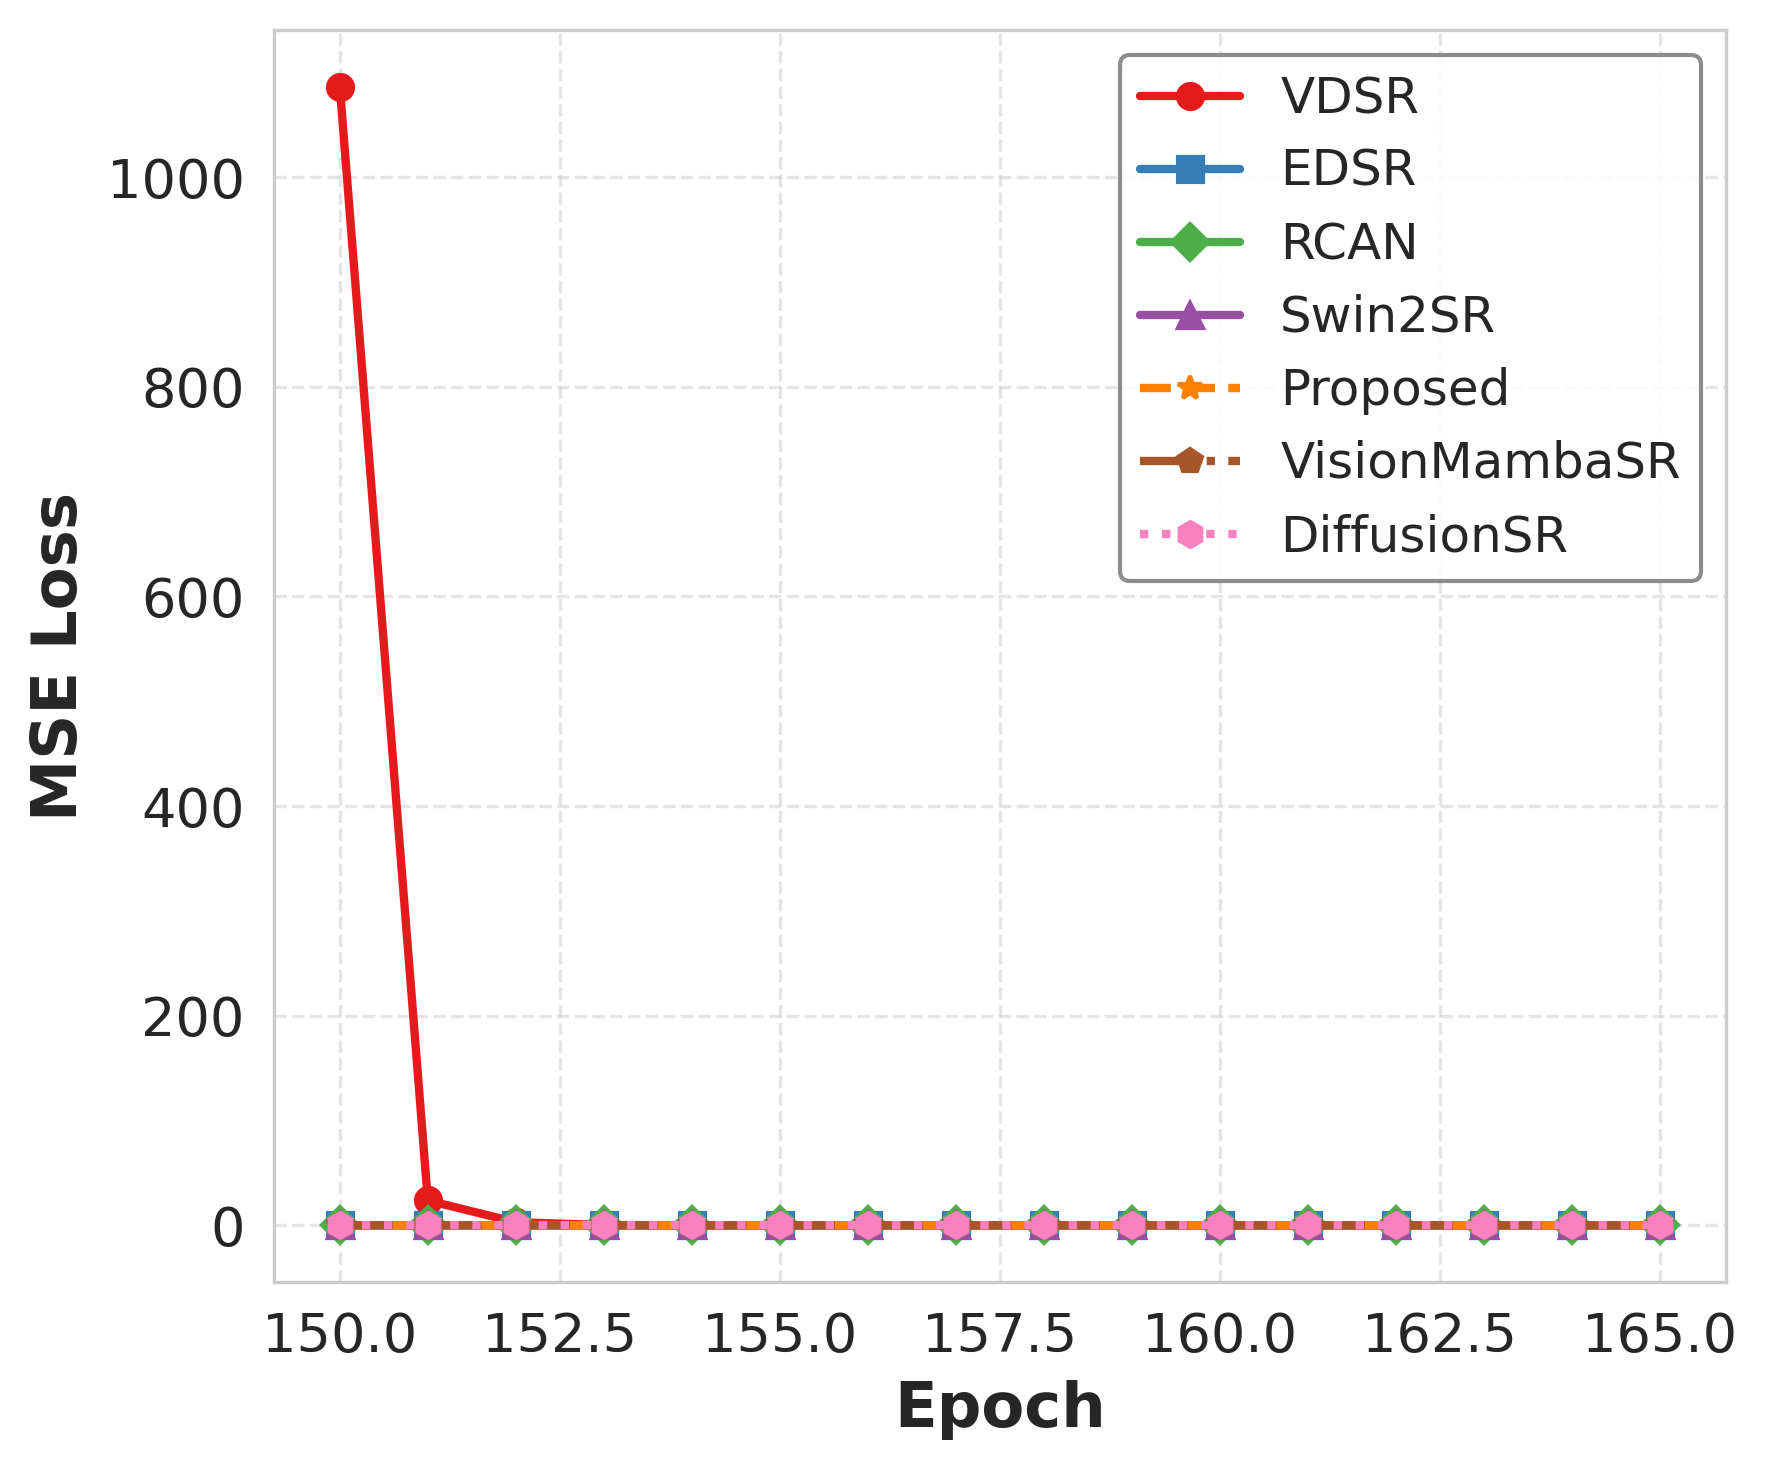

Saved: MSE_Loss.png


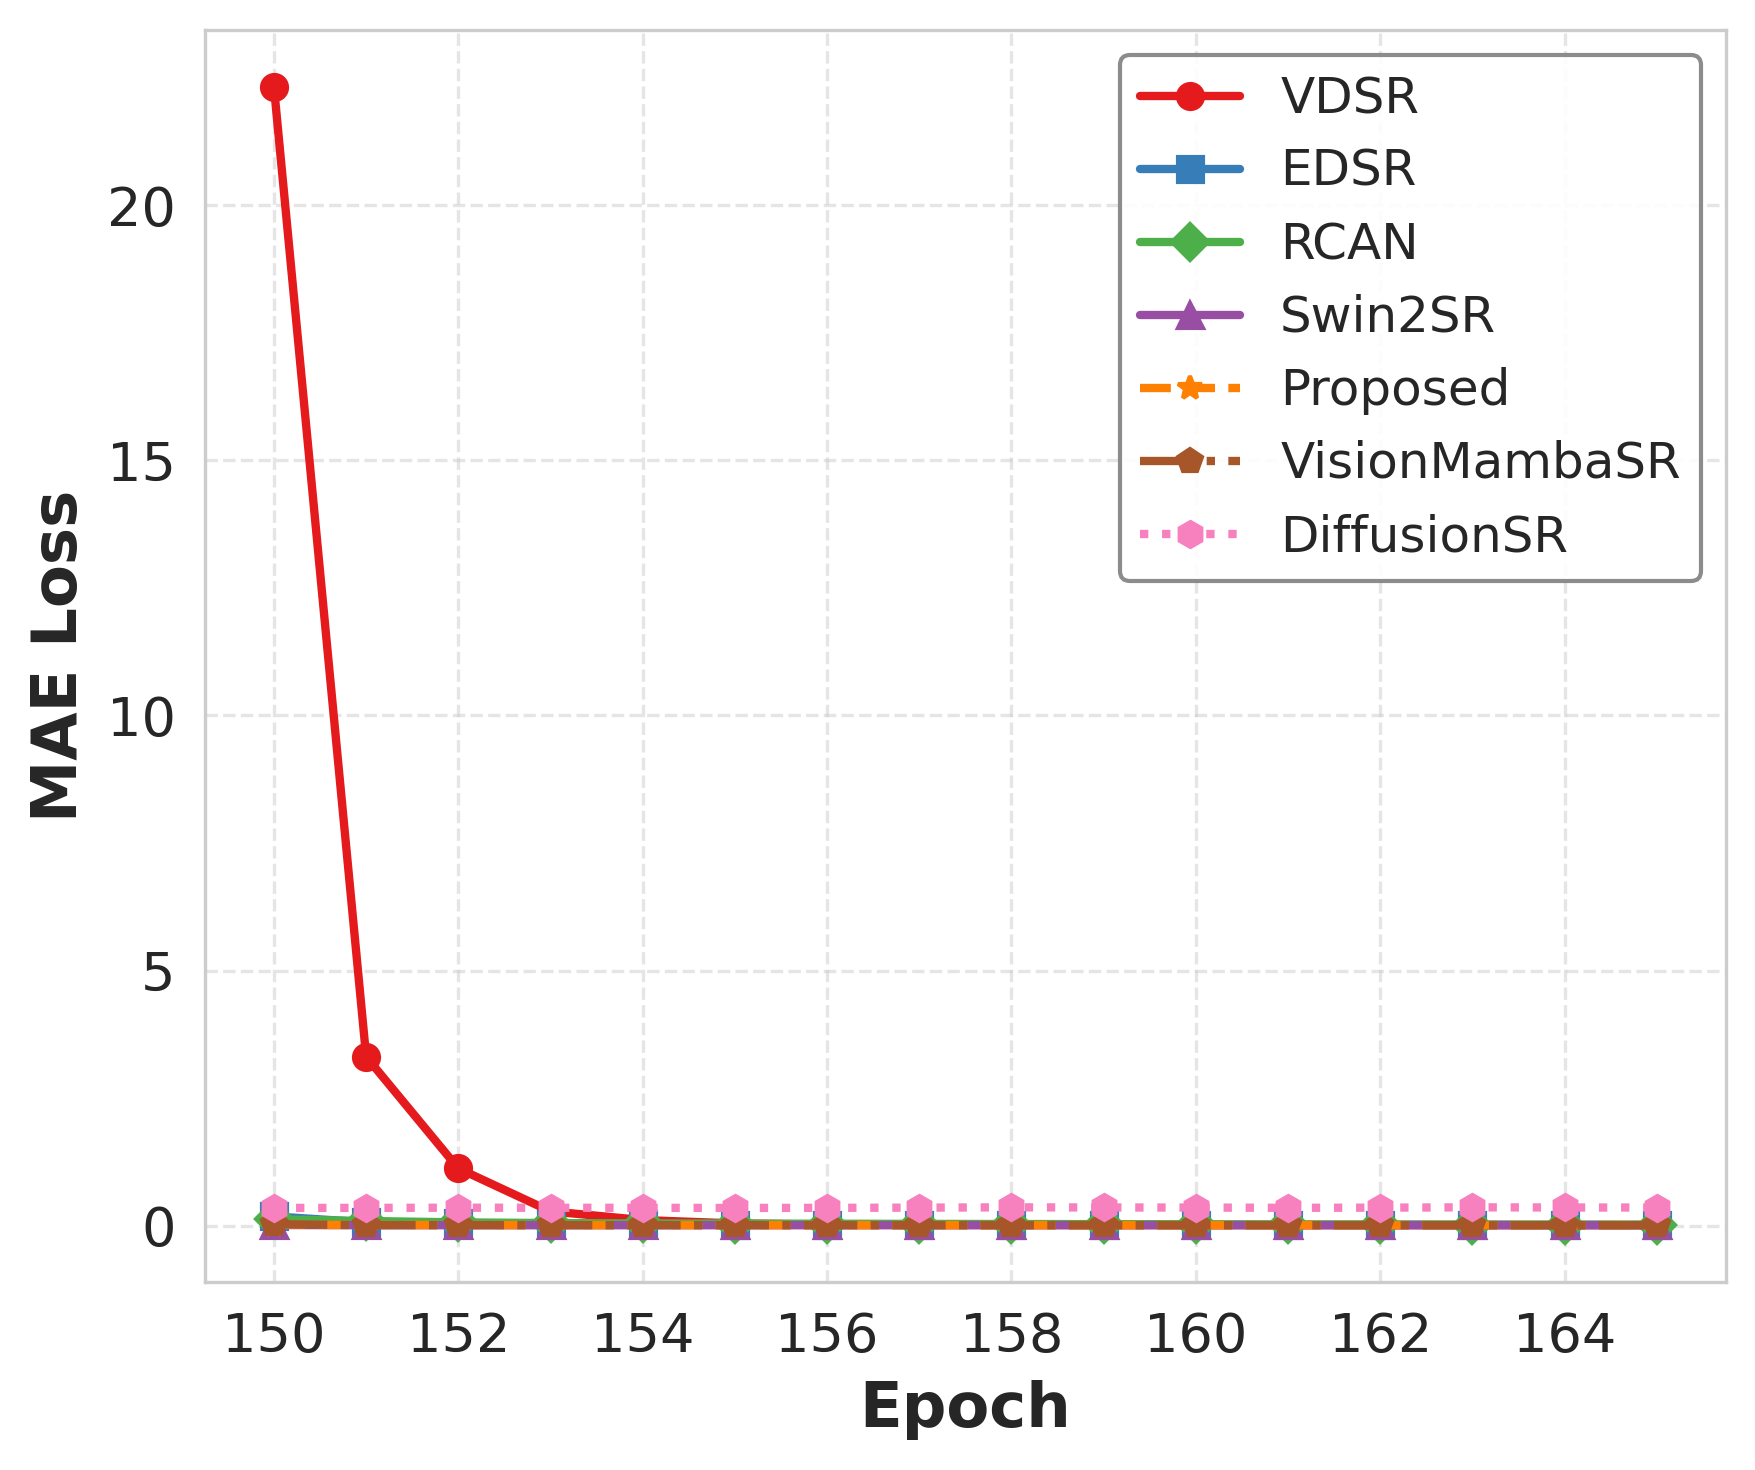

Saved: MAE_Loss.png


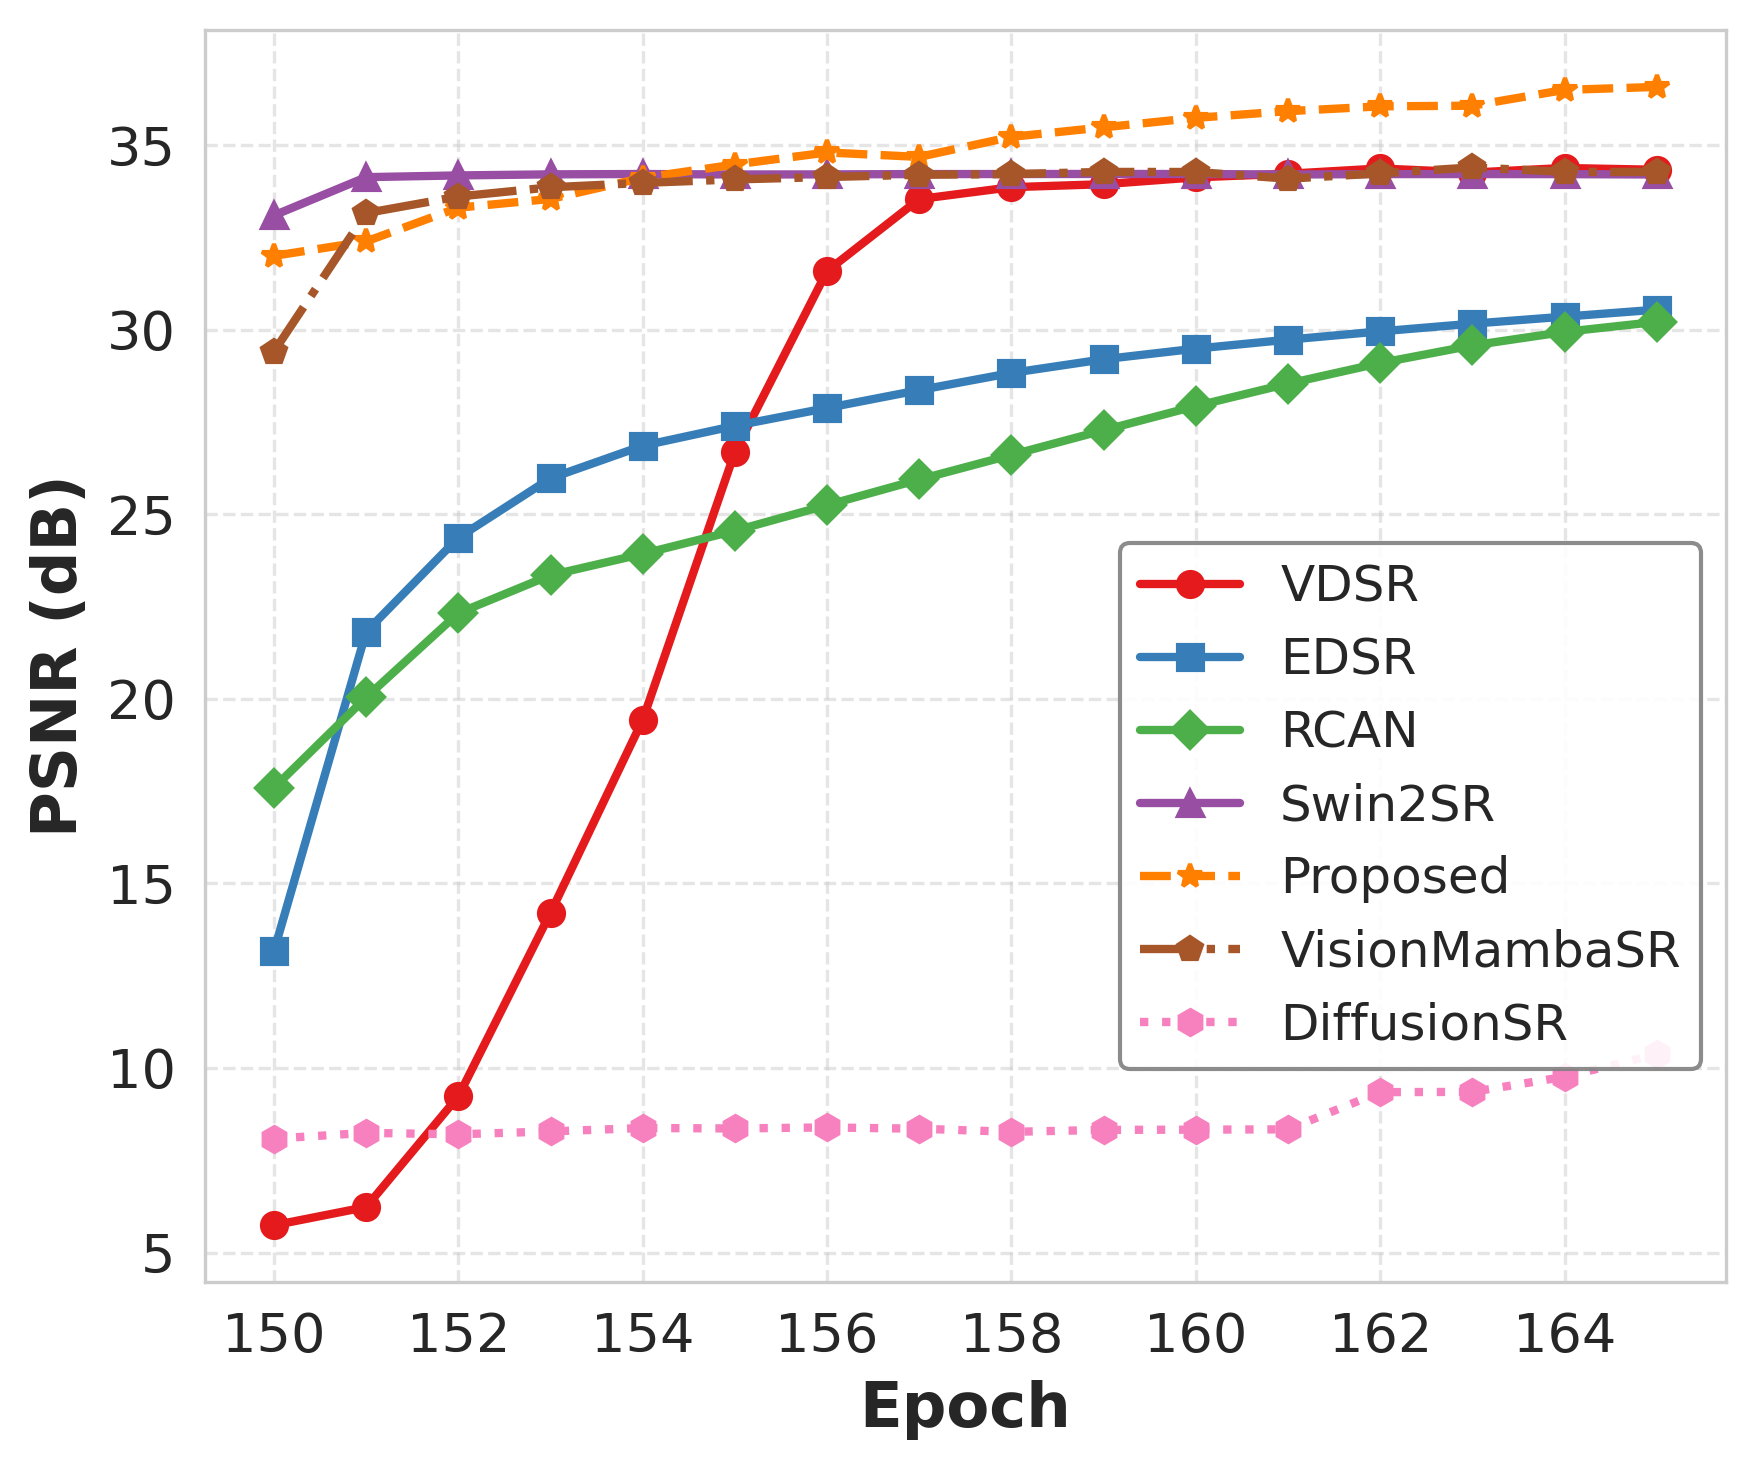

Saved: PSNR_Curve.png


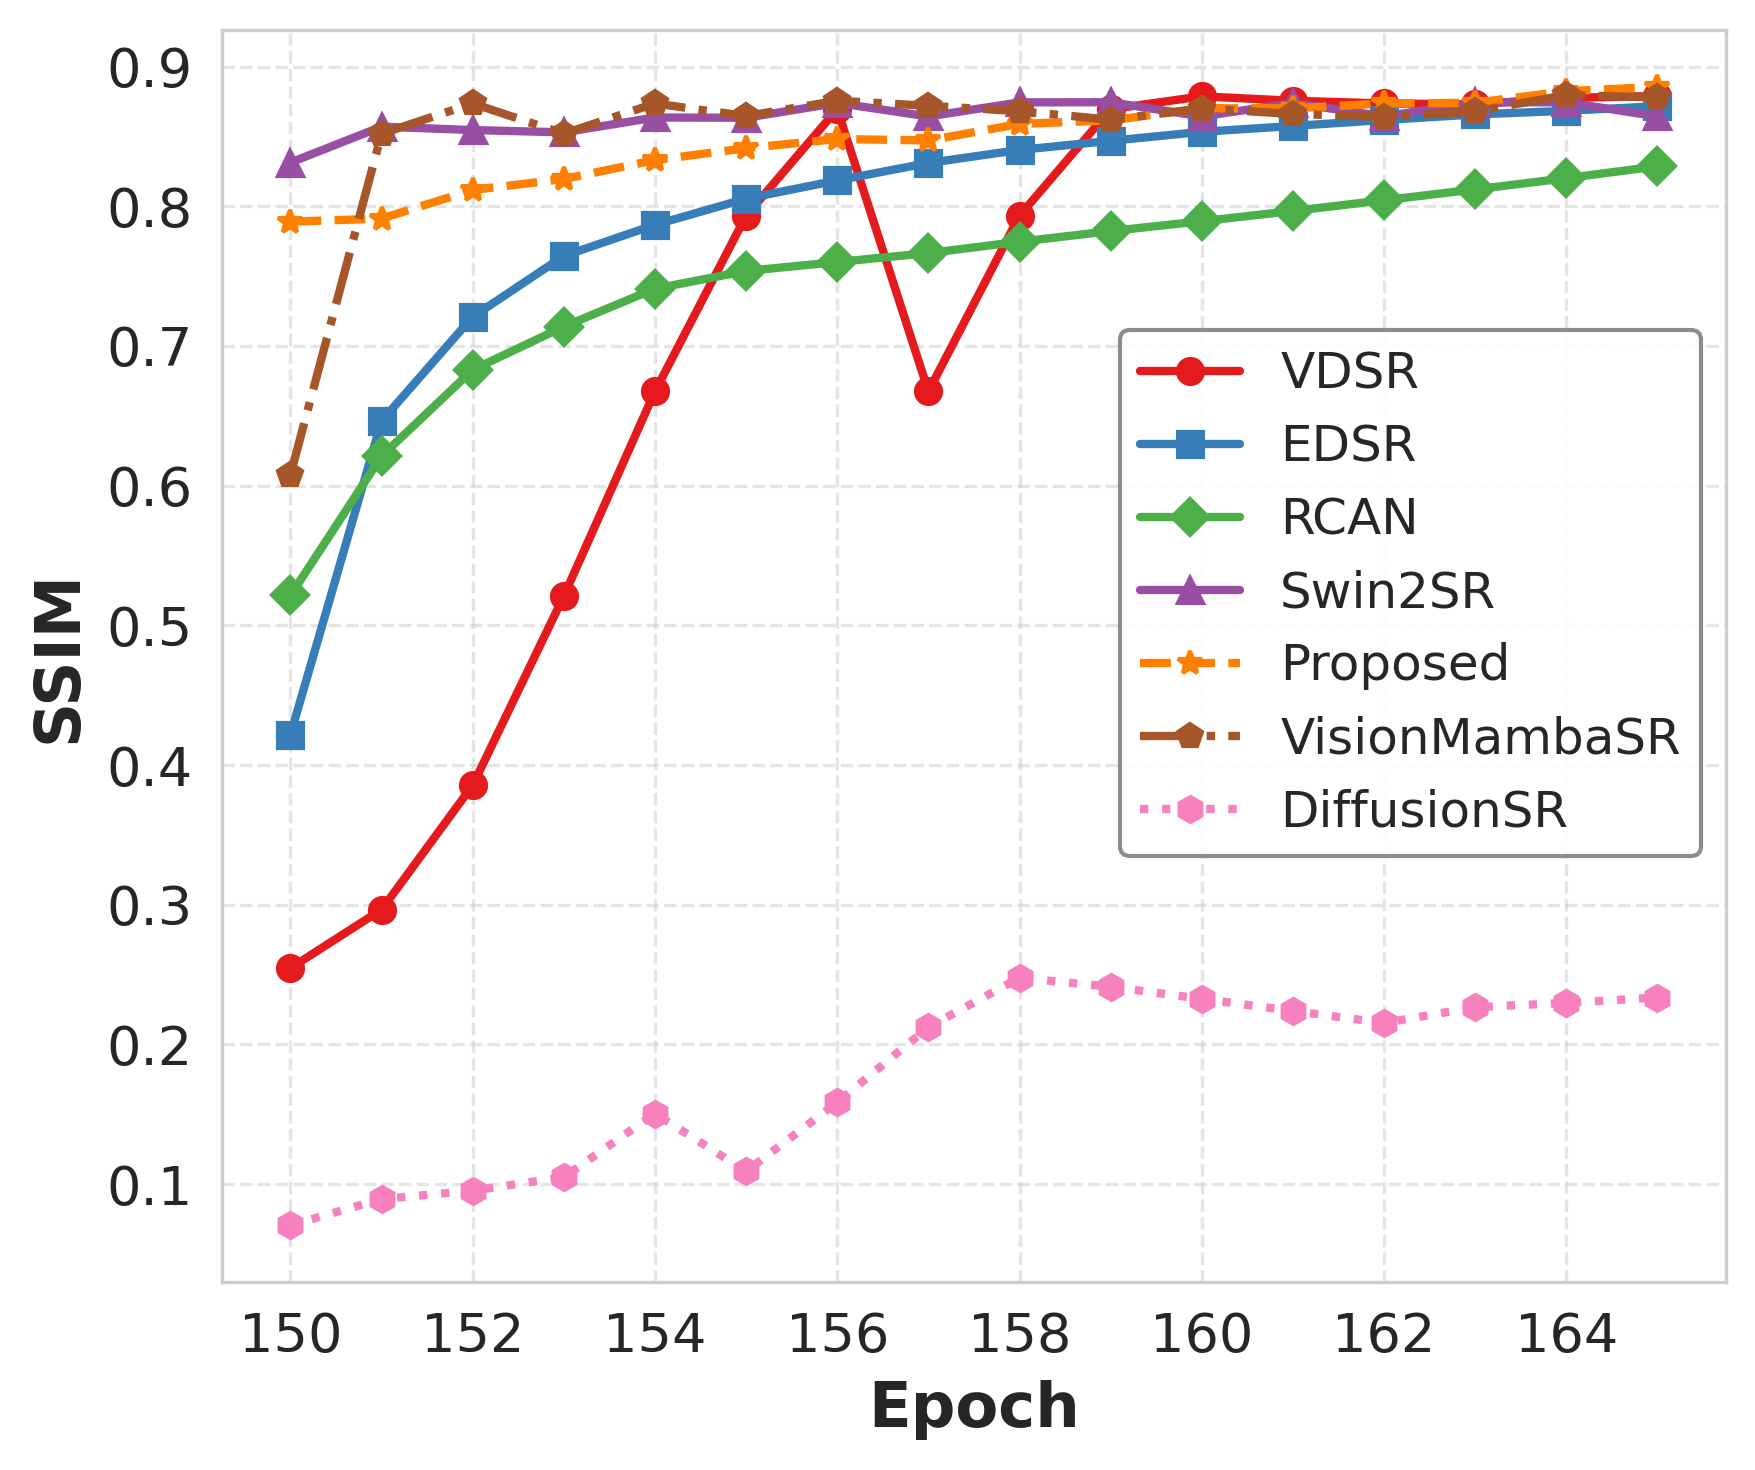

Saved: SSIM_Curve.png


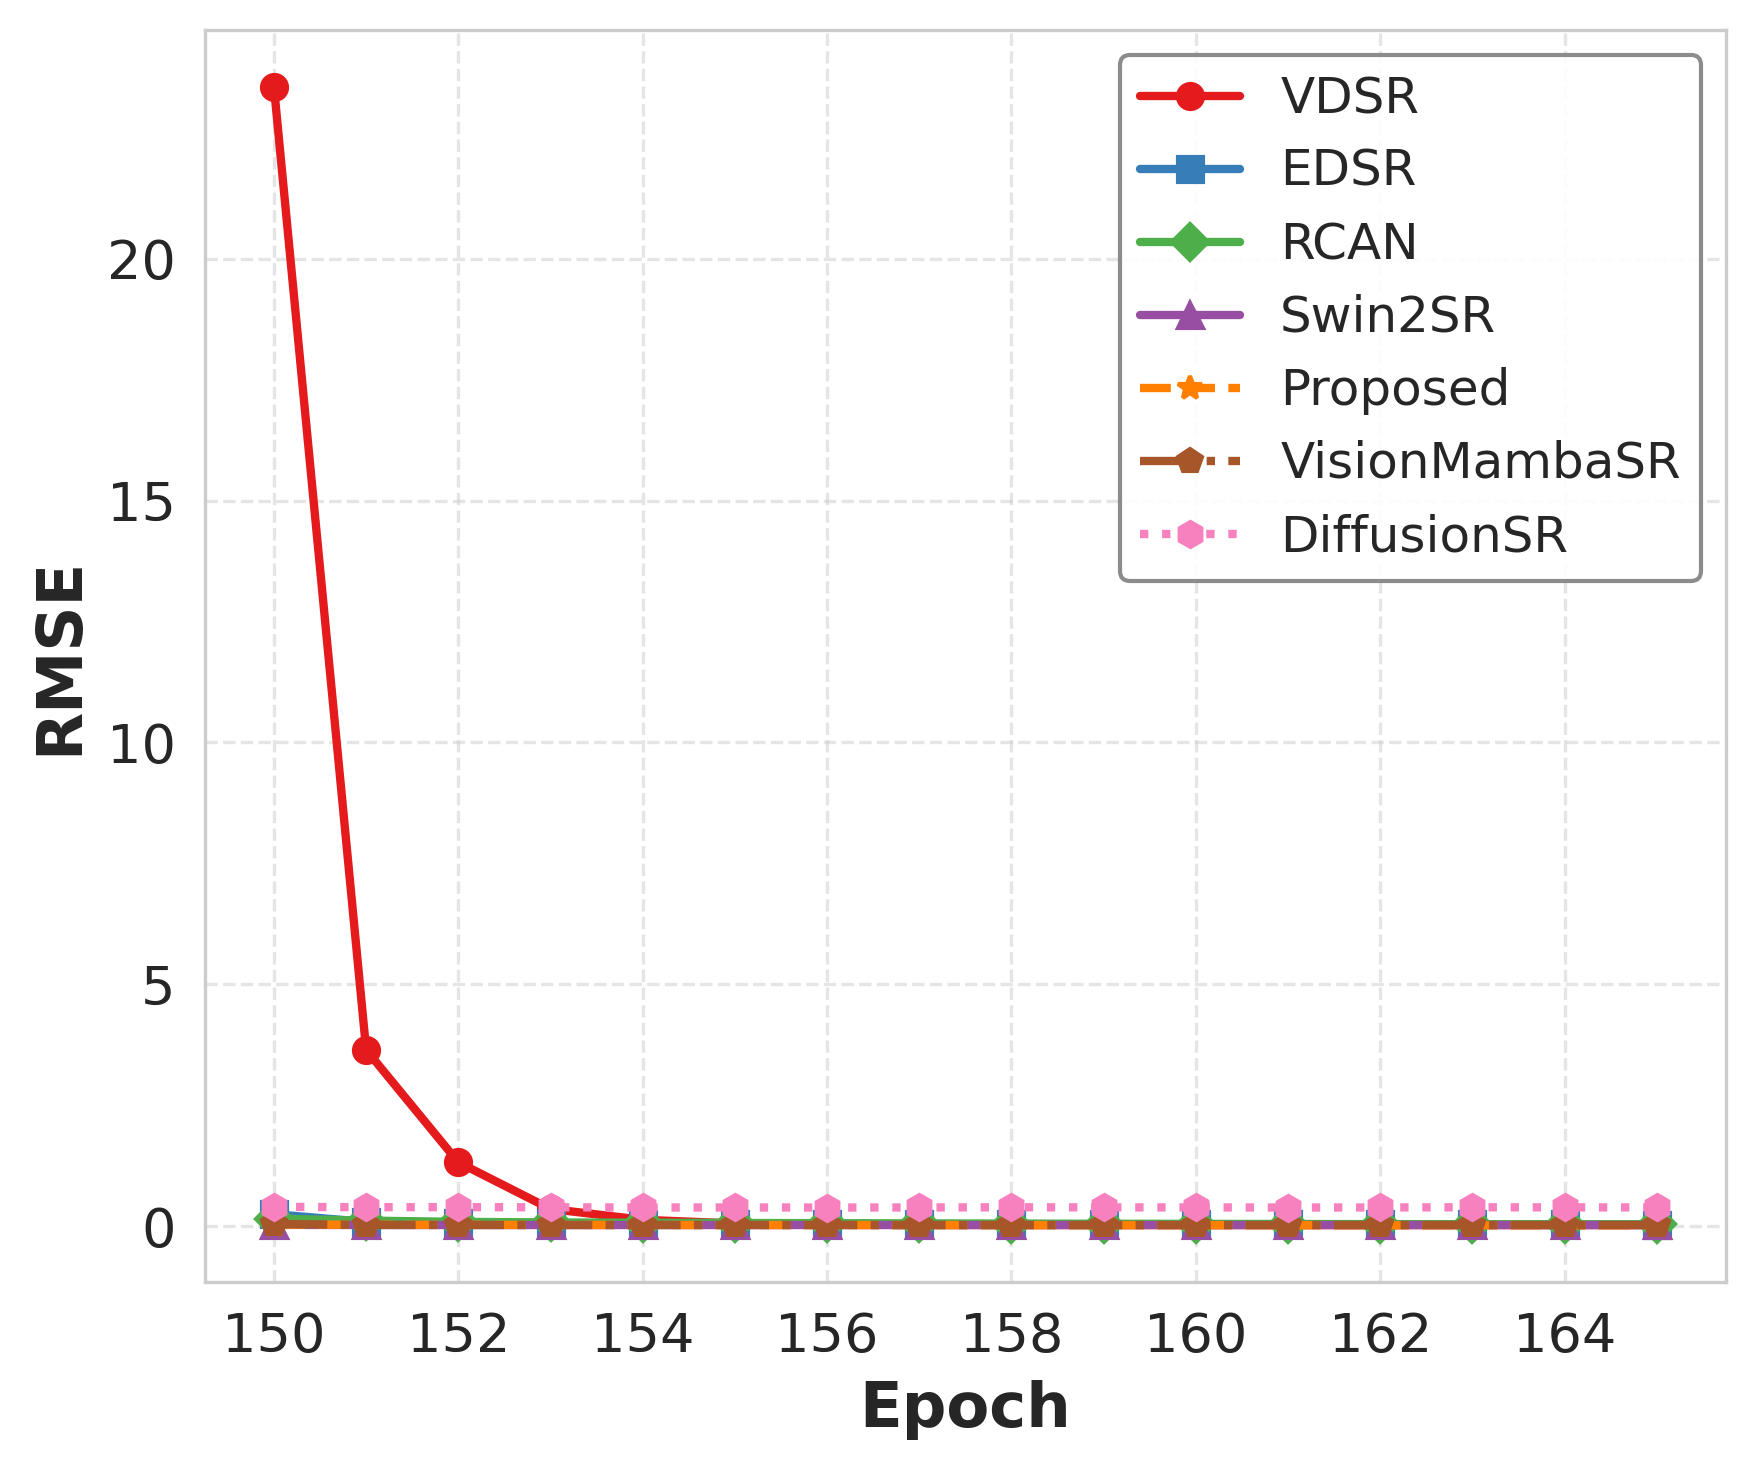

Saved: RMSE_Curve.png


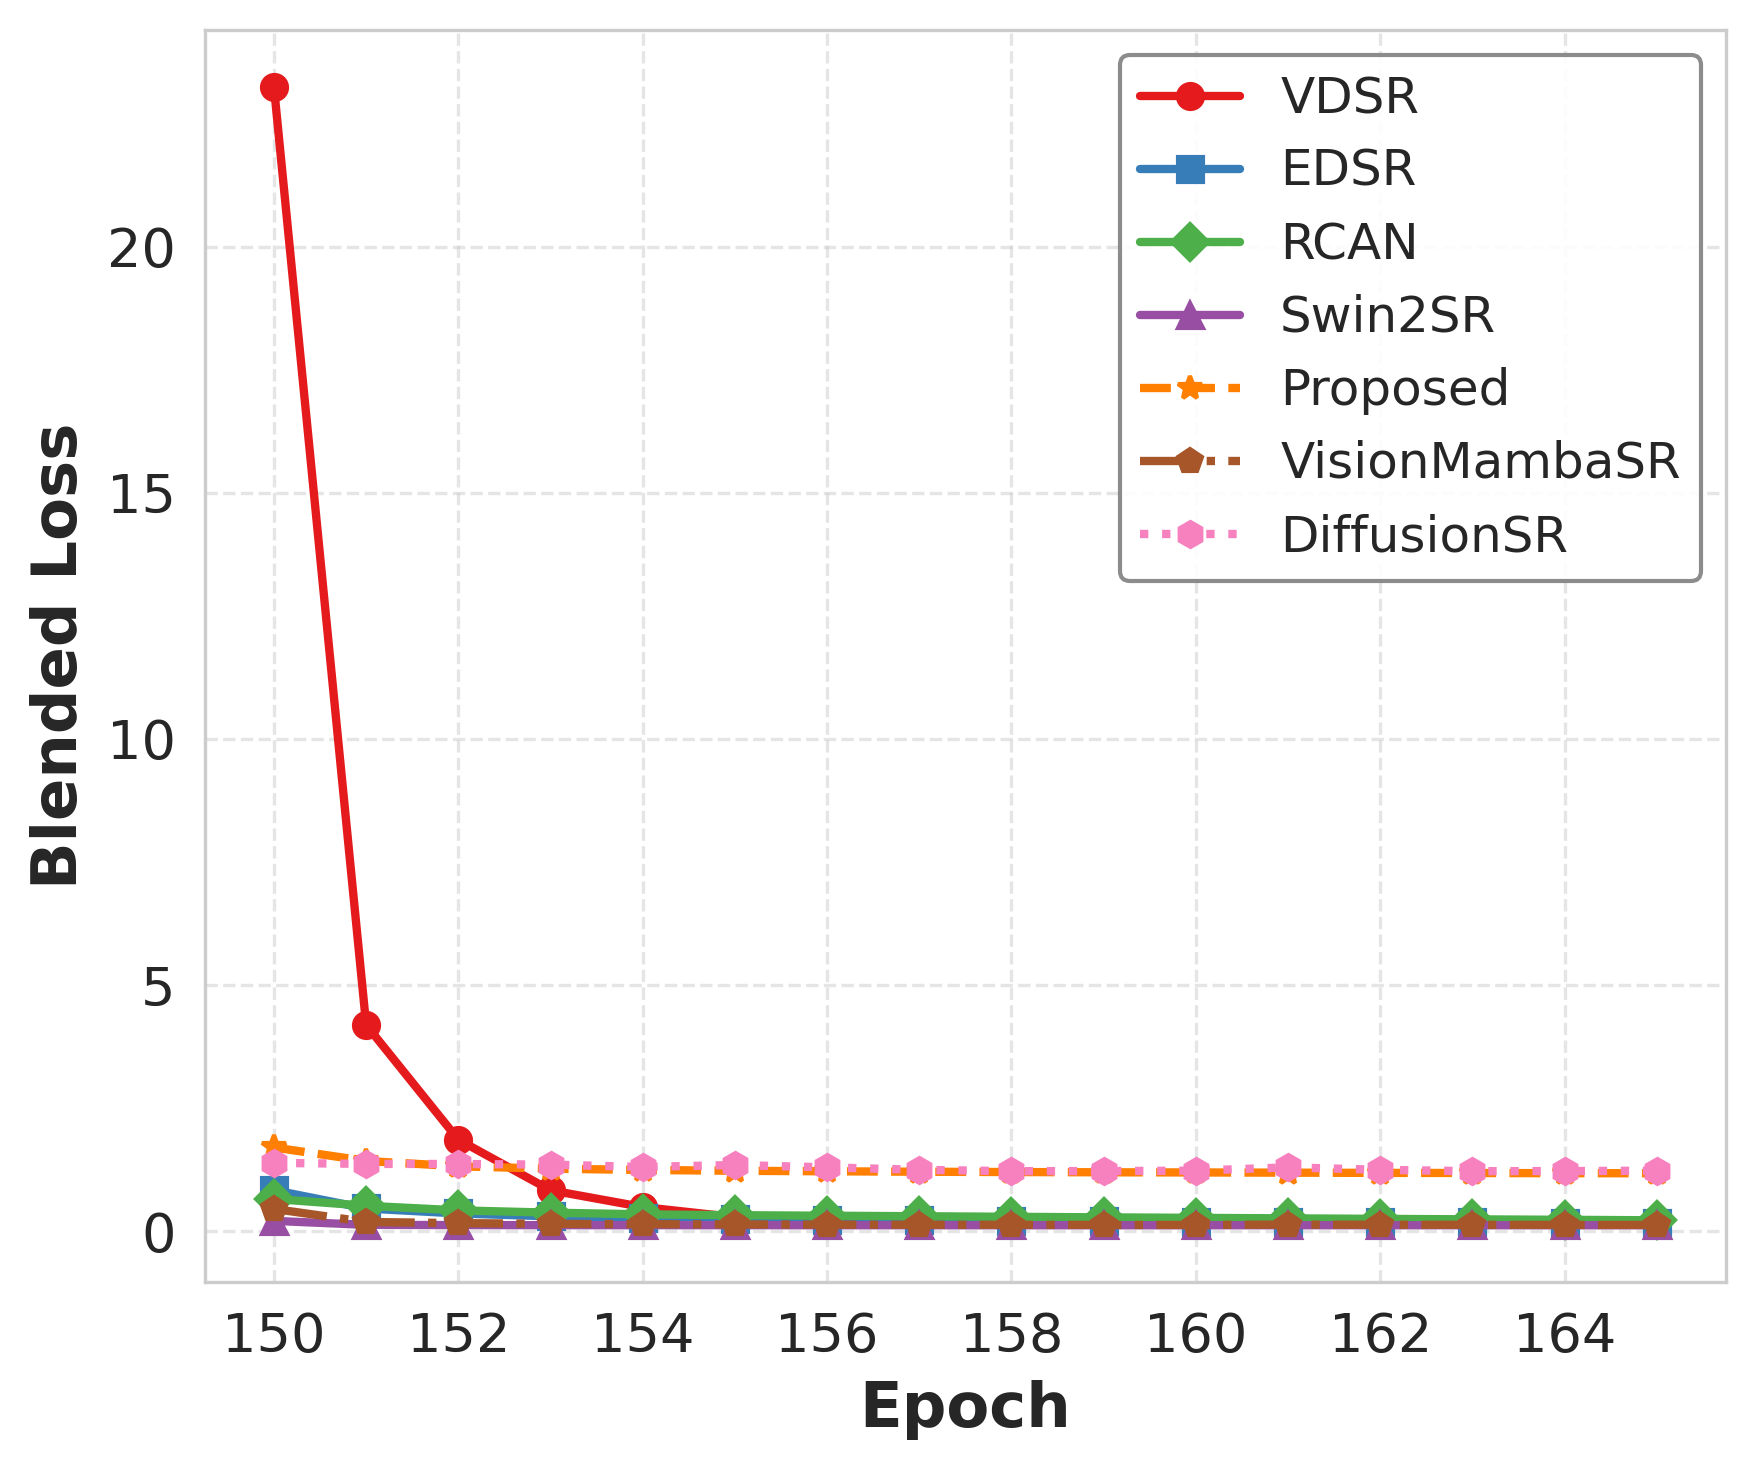

Saved: Blended_Loss_Curve.png


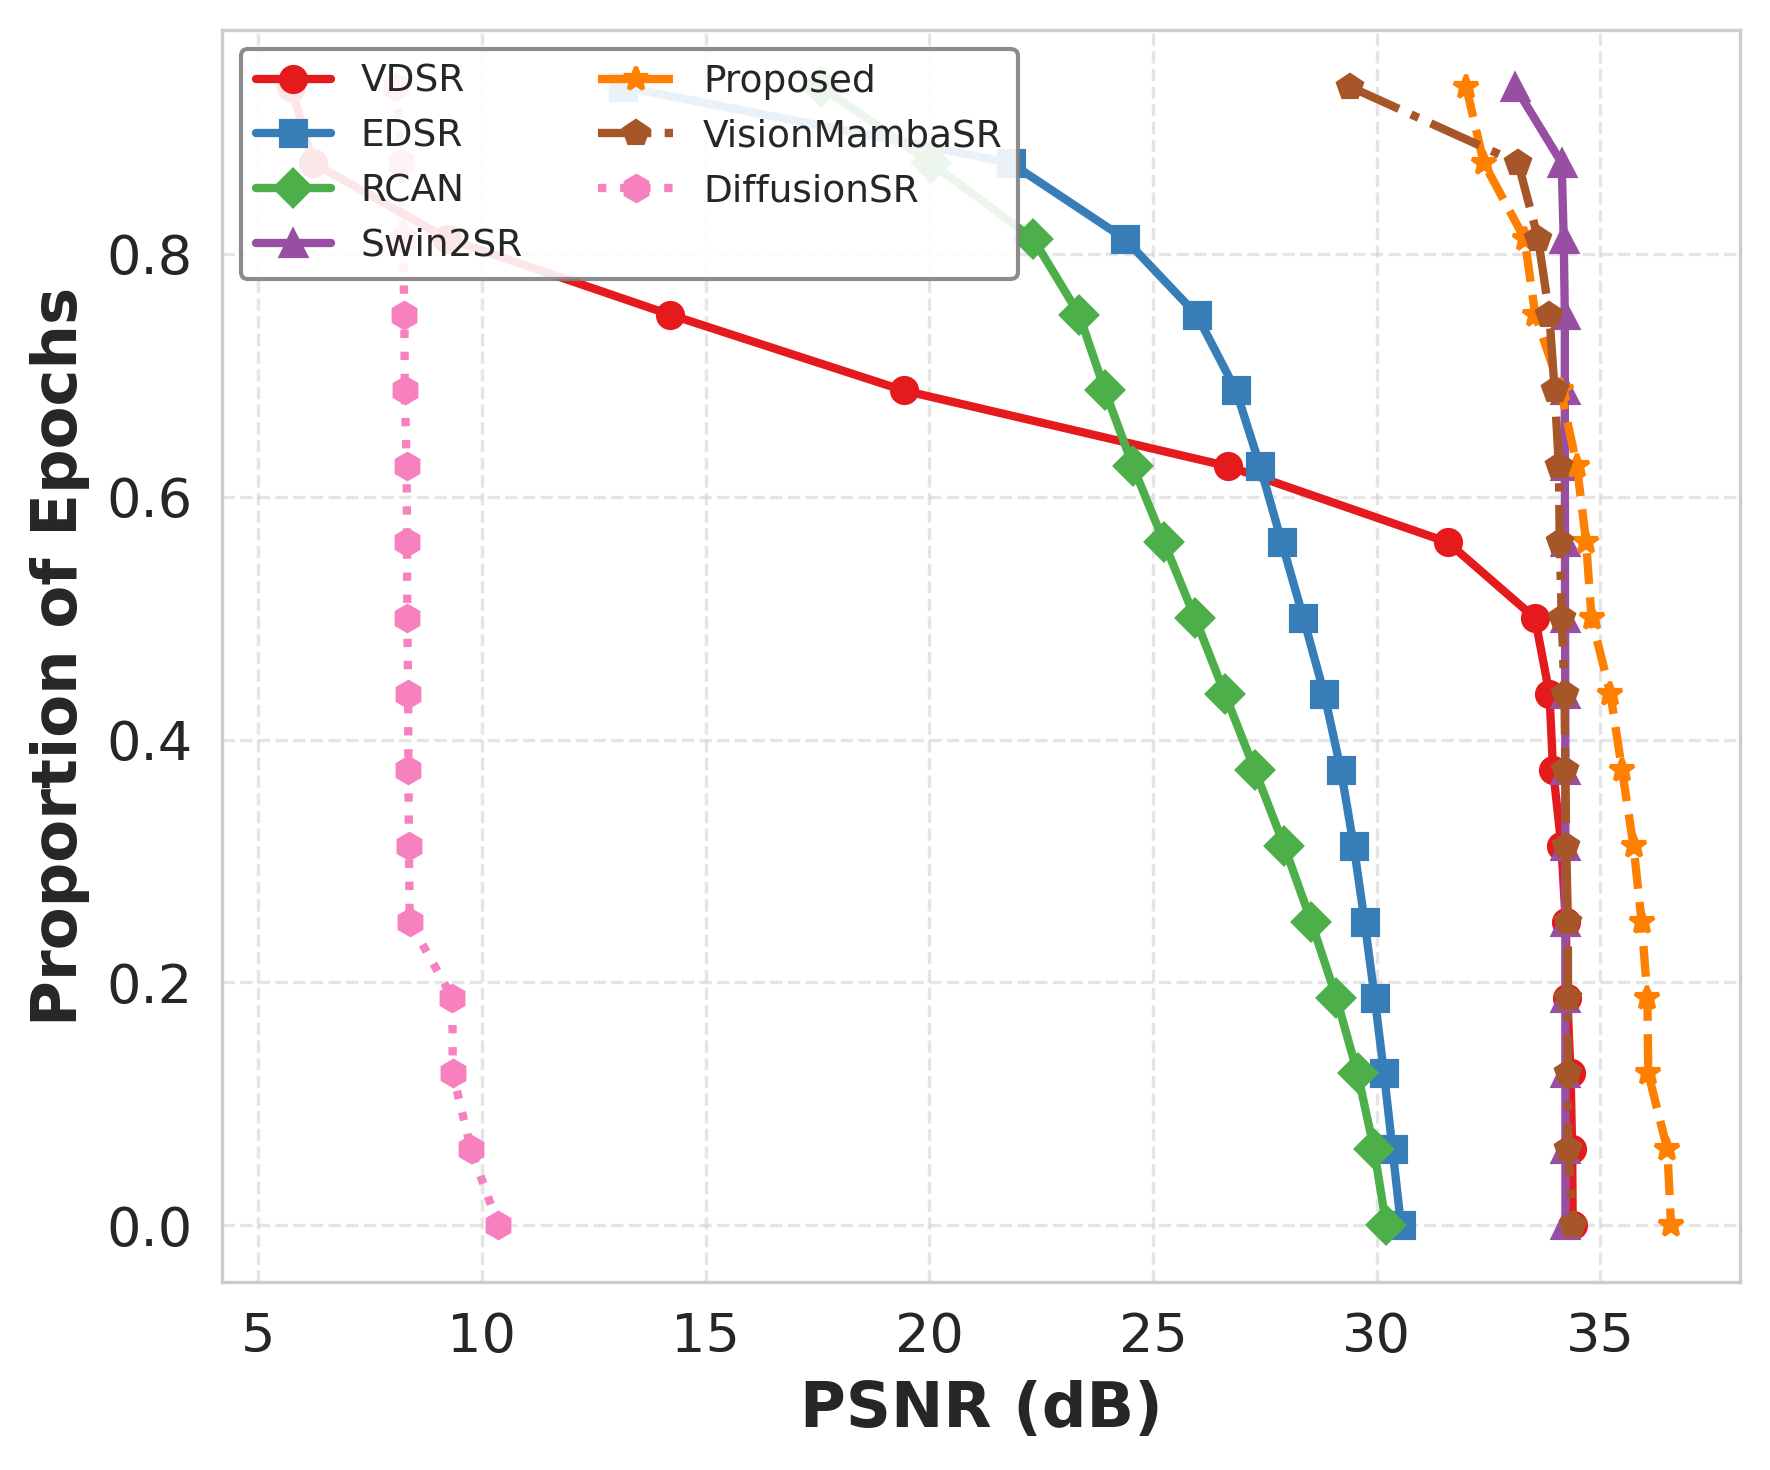

Saved: PSNR_Proportion.png


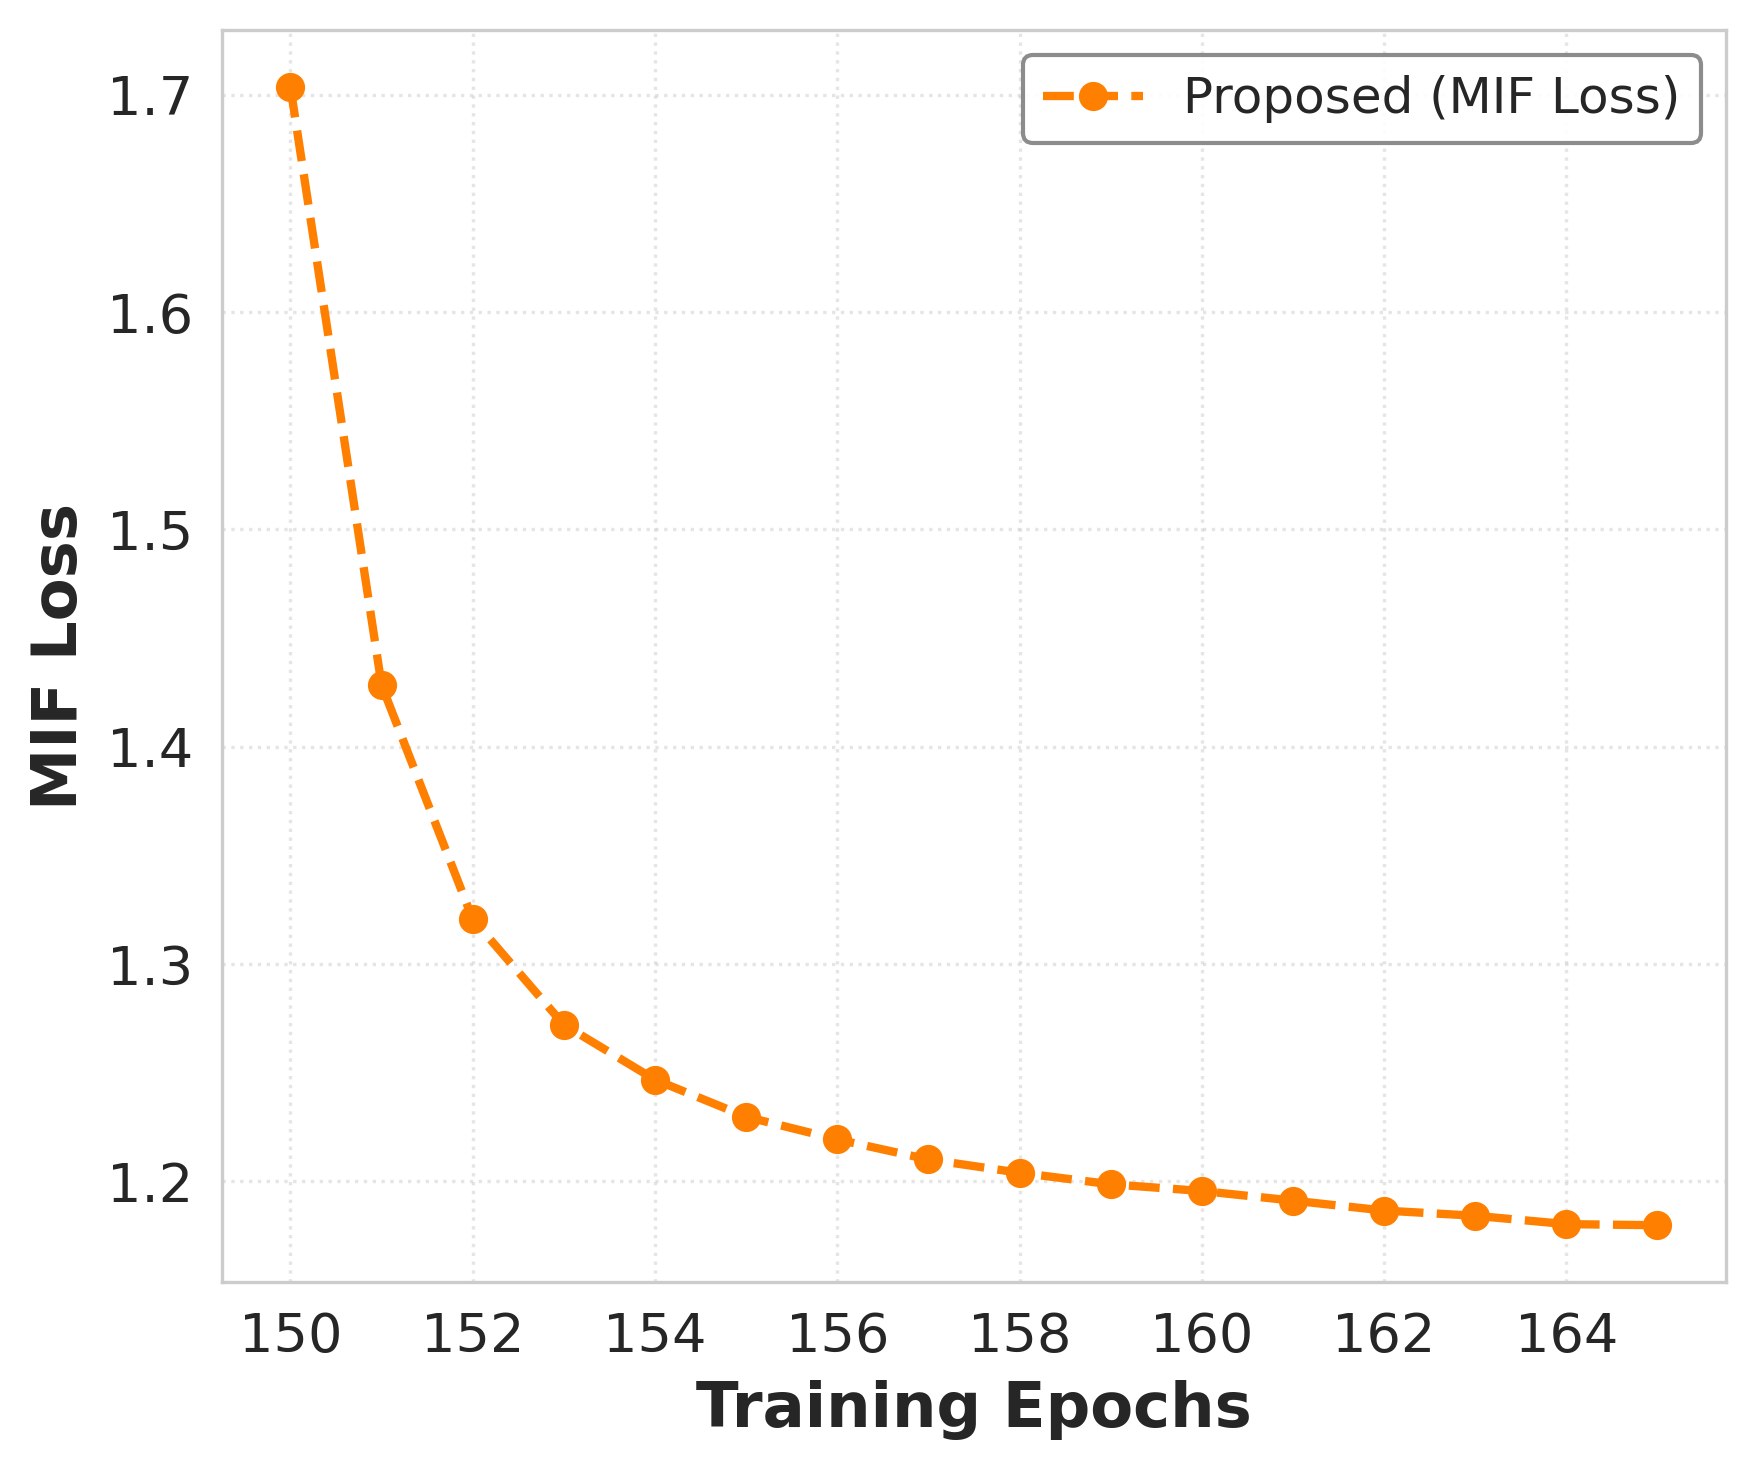

Saved: MIF_Loss.png

TABLE II — Quantitative Comparison (APTOS-2019, Scale x4)
        Model  Scale   PSNR   SSIM     MSE     MAE
         VDSR      4 34.332 0.8789 0.00042 0.01350
         EDSR      4 30.542 0.8716 0.00100 0.01381
         RCAN      4 30.212 0.8286 0.00131 0.02065
      Swin2SR      4 34.204 0.8643 0.00044 0.00910
     Proposed      4 36.576 0.8854 0.00026 0.00959
VisionMambaSR      4 34.274 0.8779 0.00043 0.00938
  DiffusionSR      4 10.367 0.2336 0.14622 0.35639

Table saved to: /content/drive/MyDrive/models_metrics/TABLE_II_7models.csv
All plots saved to: /content/drive/MyDrive/Results/plots

Done!


In [ ]:
# ---------------------------------------------------------------
# UPDATED METRIC PLOTS & COMPARISON TABLE — 7 Models
# - All plots same size (6x5 inches, 300 dpi)
# - No figure labels (a), (b) etc.
# - Large fonts for visibility when combined in draw.io
# - Exported as high-quality PNG for Overleaf
# ---------------------------------------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype']  = 42   # ensures fonts embed in PDF
matplotlib.rcParams['ps.fonttype']   = 42
matplotlib.rcParams['font.family']   = 'DejaVu Sans'
import matplotlib.pyplot as plt
import seaborn as sns

directory  = "/content/drive/MyDrive/models_metrics"
result_dir = "/content/drive/MyDrive/Results/plots"
os.makedirs(result_dir, exist_ok=True)

# ── Consistent plot dimensions for all figures ────────────────
FIG_W   = 6       # inches — width
FIG_H   = 5       # inches — height
DPI     = 300     # resolution

# ── Font sizes — large enough to read after combining in draw.io
TITLE_FS  = 16
LABEL_FS  = 15
TICK_FS   = 13
LEGEND_FS = 12    # ← unchanged: all inside-legends stay at 12
LINE_W    = 2.0
MARKER_S  = 6

# ── CSV file map ──────────────────────────────────────────────
CSV_MAP = {
    'VDSR'         : 'vdsr_metrics.csv',
    'EDSR'         : 'edsr_metrics.csv',
    'RCAN'         : 'rcan_metrics.csv',
    'Swin2SR'      : 'swin2sr_metrics.csv',
    'Proposed'     : '_blended_loss_proposed.csv',
    'VisionMambaSR': 'mamba_metrics.csv',
    'DiffusionSR'  : 'diffusion_metrics.csv',
}

# ── Visual style ──────────────────────────────────────────────
COLORS = {
    'VDSR'         : '#e41a1c',
    'EDSR'         : '#377eb8',
    'RCAN'         : '#4daf4a',
    'Swin2SR'      : '#984ea3',
    'Proposed'     : '#ff7f00',
    'VisionMambaSR': '#a65628',
    'DiffusionSR'  : '#f781bf',
}
MARKERS = {
    'VDSR'         : 'o',
    'EDSR'         : 's',
    'RCAN'         : 'D',
    'Swin2SR'      : '^',
    'Proposed'     : '*',
    'VisionMambaSR': 'p',
    'DiffusionSR'  : 'h',
}
LINES = {
    'VDSR'         : '-',
    'EDSR'         : '-',
    'RCAN'         : '-',
    'Swin2SR'      : '-',
    'Proposed'     : '--',
    'VisionMambaSR': '-.',
    'DiffusionSR'  : ':',
}

# ── Load all CSVs ─────────────────────────────────────────────
data = {}
for model, fname in CSV_MAP.items():
    fpath = os.path.join(directory, fname)
    if os.path.exists(fpath):
        df         = pd.read_csv(fpath)
        df.columns = [c.strip() for c in df.columns]
        data[model]= df
        print(f"  Loaded: {fname}  ({len(df)} epochs)")
    else:
        print(f"  WARNING: {fpath} not found — {model} skipped")

print(f"\nLoaded {len(data)} models successfully.\n")


# ── Generic plot function ─────────────────────────────────────
def plot_metric(metric, ylabel, save_fname, loc='best',
                legend_fs=None, ncol=1, bbox=None):
    """
    Plots one metric across all 7 models.
    Same size, no title, large fonts.

    Parameters
    ----------
    legend_fs : int or None
        Override legend font size for this plot only.
        None → uses the global LEGEND_FS (12).
    ncol : int
        Number of columns in the legend.
    bbox : tuple or None
        (x, y) in axes fraction for bbox_to_anchor.
        Use to pin the legend to a specific blank zone
        (e.g. right-middle for PSNR/SSIM curves).
        None → standard loc-only placement.
    """
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)

    for model, df in data.items():
        if metric in df.columns:
            ax.plot(
                df['Epoch'], df[metric],
                color     = COLORS[model],
                marker    = MARKERS[model],
                linestyle = LINES[model],
                linewidth = LINE_W,
                markersize= MARKER_S,
                markevery = max(1, len(df) // 10),
                label     = model
            )

    ax.set_xlabel("Epoch",  fontsize=LABEL_FS, fontweight='bold')
    ax.set_ylabel(ylabel,   fontsize=LABEL_FS, fontweight='bold')
    ax.tick_params(axis='both', labelsize=TICK_FS)
    legend_kwargs = dict(
        fontsize   = legend_fs if legend_fs is not None else LEGEND_FS,
        loc        = loc,
        ncol       = ncol,
        framealpha = 0.9,
        edgecolor  = 'gray',
    )
    if bbox is not None:
        legend_kwargs['bbox_to_anchor'] = bbox
    ax.legend(**legend_kwargs)
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    save_path = os.path.join(result_dir, save_fname)
    plt.savefig(save_path, dpi=DPI, bbox_inches='tight',
                facecolor='white')
    plt.show()
    plt.close()
    print(f"Saved: {save_fname}")


# ── MSE Loss ──────────────────────────────────────────────────
# Curves descend → upper-right corner is free → no change needed
plot_metric(
    metric     = 'MSE',
    ylabel     = 'MSE Loss',
    save_fname = 'MSE_Loss.png',
    loc        = 'upper right'
)

# ── MAE Loss ──────────────────────────────────────────────────
plot_metric(
    metric     = 'MAE',
    ylabel     = 'MAE Loss',
    save_fname = 'MAE_Loss.png',
    loc        = 'upper right'
)

# ── PSNR Training Curve ───────────────────────────────────────
# FIX: curves rise and fill lower-right AND upper-right.
#      → move legend to lower-LEFT (below the slow-starting curves)
#      → reduce font to 9 and use 2 columns so the box is compact
plot_metric(
    metric     = 'PSNR',
    ylabel     = 'PSNR (dB)',
    save_fname = 'PSNR_Curve.png',
    loc        = 'center right',          # ← right-middle blank zone
    bbox       = (1.0, 0.38),             # ← anchored to right edge, 38% up
    legend_fs  = LEGEND_FS,              # ← full size, readable
    ncol       = 1                        # ← single column, clean
)

# ── SSIM Training Curve ───────────────────────────────────────
# FIX: right-middle zone is blank (DiffusionSR flat at bottom,
#      all other curves crowd top) → place legend there
plot_metric(
    metric     = 'SSIM',
    ylabel     = 'SSIM',
    save_fname = 'SSIM_Curve.png',
    loc        = 'center right',          # ← right-middle blank zone
    bbox       = (1.0, 0.55),             # ← pushed up to 55% so DiffusionSR is fully visible
    legend_fs  = LEGEND_FS,              # ← full size
    ncol       = 1                        # ← single column
)

# ── RMSE ──────────────────────────────────────────────────────
plot_metric(
    metric     = 'RMSE',
    ylabel     = 'RMSE',
    save_fname = 'RMSE_Curve.png',
    loc        = 'upper right'
)

# ── Blended Loss (all 7 models) ───────────────────────────────
plot_metric(
    metric     = 'Blended_Loss',
    ylabel     = 'Blended Loss',
    save_fname = 'Blended_Loss_Curve.png',
    loc        = 'upper right'
)

# ── PSNR Proportion Plot ──────────────────────────────────────
# FIX: curves crowd upper-right
#      → move legend to lower-left + compact 2-col font-9 box
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)

for model, df in data.items():
    if 'PSNR' in df.columns:
        psnr_sorted = df['PSNR'].dropna().sort_values().values
        proportions = 1.0 - np.arange(1, len(psnr_sorted)+1) / len(psnr_sorted)
        ax.plot(
            psnr_sorted, proportions,
            color     = COLORS[model],
            marker    = MARKERS[model],
            linestyle = LINES[model],
            linewidth = LINE_W,
            markersize= MARKER_S,
            markevery = max(1, len(psnr_sorted) // 10),
            label     = model
        )

ax.set_xlabel("PSNR (dB)",              fontsize=LABEL_FS, fontweight='bold')
ax.set_ylabel("Proportion of Epochs",   fontsize=LABEL_FS, fontweight='bold')
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.legend(fontsize  = 9,              # ← CHANGED (was LEGEND_FS=12)
          loc       = 'upper left',   # ← CHANGED (was 'upper right')
          ncol      = 2,              # ← CHANGED (compact 2-col layout)
          framealpha= 0.9,
          edgecolor = 'gray')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
save_path = os.path.join(result_dir, 'PSNR_Proportion.png')
plt.savefig(save_path, dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Saved: PSNR_Proportion.png")

# ── MIF / Blended Loss — Proposed model only ──────────────────
if 'Proposed' in data and 'Blended_Loss' in data['Proposed'].columns:
    sns.set_style("whitegrid")
    df_p = data['Proposed']

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
    ax.plot(
        df_p['Epoch'], df_p['Blended_Loss'],
        marker    = 'o',
        linestyle = '--',
        color     = '#ff7f00',
        markersize= MARKER_S,
        linewidth = LINE_W,
        label     = 'Proposed (MIF Loss)'
    )
    ax.set_xlabel("Training Epochs", fontsize=LABEL_FS, fontweight='bold')
    ax.set_ylabel("MIF Loss",        fontsize=LABEL_FS, fontweight='bold')
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.legend(fontsize=LEGEND_FS, loc='upper right',
              framealpha=0.9, edgecolor='gray')
    ax.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    save_path = os.path.join(result_dir, 'MIF_Loss.png')
    plt.savefig(save_path, dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()
    print("Saved: MIF_Loss.png")

# ── TABLE II — Final epoch metrics all 7 models ───────────────
print("\n" + "="*68)
print("TABLE II — Quantitative Comparison (APTOS-2019, Scale x4)")
print("="*68)

rows = []
for model in CSV_MAP.keys():
    if model in data:
        last = data[model].iloc[-1]
        rows.append({
            'Model' : model,
            'Scale' : 4,
            'PSNR'  : round(float(last.get('PSNR', 0)), 3),
            'SSIM'  : round(float(last.get('SSIM', 0)), 4),
            'MSE'   : round(float(last.get('MSE',  0)), 5),
            'MAE'   : round(float(last.get('MAE',  0)), 5),
        })
    else:
        rows.append({
            'Model':'N/A', 'Scale':4,
            'PSNR':'N/A',  'SSIM':'N/A',
            'MSE':'N/A',   'MAE':'N/A'
        })

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))
print("="*68)

csv_save = os.path.join(directory, 'TABLE_II_7models.csv')
tbl.to_csv(csv_save, index=False)
print(f"\nTable saved to: {csv_save}")
print(f"All plots saved to: {result_dir}")
print("\nDone!")

### **FLOPs and Parameter Count for Each Model**

To further compare the models, let's analyze their computational complexity (FLOPs) and the number of trainable parameters. This helps in understanding the efficiency and resource requirements of each architecture.

We'll use `thop` for FLOPs calculation and a custom function for parameter counting.

In [ ]:
# ---------------------------------------------------------------
# Model Complexity Analysis
# FLOPs, Parameters, and Execution Time for all 7 models
# ---------------------------------------------------------------
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Install thop for FLOPs calculation
try:
    from thop import profile, clever_format
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'thop', '-q'])
    from thop import profile, clever_format

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Dummy input (standard LR size for scale x4) ───────────────
# LR input = 64x64, HR output = 256x256
dummy_lr = torch.randn(1, 3, 64, 64).to(device)

# ── All models with their display names ───────────────────────
models_dict = {
    'VDSR'          : vdsr_m,
    'EDSR'          : edsr_m,
    'RCAN'          : rcan_m,
    'Swin2SR'       : swin_m,
    'VisionMambaSR' : mamba_m,
    'DiffusionSR'   : diff_m,
    'Proposed\n(DHA-ESRGAN)' : prop_m,
}

# ── Measure FLOPs, Params, and Execution Time ─────────────────
N_RUNS    = 50    # number of runs for stable timing
WARMUP    = 10    # warmup runs before timing

results = []

for name, model in models_dict.items():
    model.eval()
    print(f"\nAnalysing: {name.replace(chr(10), ' ')} ...")

    # ── 1. Parameters ─────────────────────────────────────────
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                           if p.requires_grad)

    # ── 2. FLOPs ──────────────────────────────────────────────
    try:
        # thop needs CPU model for some architectures
        model_cpu  = model.cpu()
        dummy_cpu  = dummy_lr.cpu()
        flops, _   = profile(model_cpu, inputs=(dummy_cpu,),
                             verbose=False)
        model.to(device)
    except Exception:
        # Fallback for models with custom forward (Diffusion)
        try:
            # For DiffusionSR count only UNet FLOPs
            unet       = model.unet.cpu()
            cond_cpu   = dummy_cpu
            x_cpu      = torch.randn(1, 3, 256, 256)  # HR noise
            t_cpu      = torch.zeros(1, dtype=torch.long)
            flops, _   = profile(unet,
                                 inputs=(x_cpu, cond_cpu, t_cpu),
                                 verbose=False)
            model.to(device)
            unet.to(device)
        except Exception as e:
            print(f"  FLOPs calculation skipped: {e}")
            flops = 0
            model.to(device)

    # ── 3. Execution Time ─────────────────────────────────────
    dummy_lr = dummy_lr.to(device)

    # Warmup
    with torch.no_grad():
        for _ in range(WARMUP):
            try:
                if 'Diffusion' in name:
                    _ = model.sample(dummy_lr, steps=10)
                else:
                    _ = model(dummy_lr)
            except Exception:
                pass

    # Synchronize GPU before timing
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(N_RUNS):
            t_start = time.perf_counter()
            try:
                if 'Diffusion' in name:
                    out = model.sample(dummy_lr, steps=10)
                else:
                    out = model(dummy_lr)
            except Exception:
                pass
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t_end = time.perf_counter()
            times.append((t_end - t_start) * 1000)  # ms

    avg_time = np.mean(times)
    std_time = np.std(times)

    # ── Format values ─────────────────────────────────────────
    flops_m  = flops / 1e6  if flops > 0 else 0
    params_k = total_params / 1e3

    print(f"  FLOPs      : {flops_m:.3f} M")
    print(f"  Params     : {params_k:.3f} K  "
          f"(trainable: {trainable_params/1e3:.3f} K)")
    print(f"  Exec Time  : {avg_time:.2f} ± {std_time:.2f} ms")

    results.append({
        'Model'           : name.replace('\n', ' '),
        'FLOPs (M)'       : round(flops_m,         3),
        'Params (K)'      : round(params_k,         3),
        'Trainable (K)'   : round(trainable_params/1e3, 3),
        'Exec Time (ms)'  : round(avg_time,         2),
        'Std Time (ms)'   : round(std_time,          2),
    })

# ── Print Table ───────────────────────────────────────────────
df = pd.DataFrame(results)
print("\n" + "="*75)
print("TABLE III — Model Complexity & Execution Time Analysis")
print("="*75)
print(df.to_string(index=False))
print("="*75)

# Save table to CSV
csv_path = os.path.join(mpth, 'models_metrics', 'Table3_complexity.csv')
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
df.to_csv(csv_path, index=False)
print(f"\nTable saved to: {csv_path}")


# ── Bar Charts ────────────────────────────────────────────────
model_names  = [r['Model'] for r in results]
flops_vals   = [r['FLOPs (M)']      for r in results]
params_vals  = [r['Params (K)']     for r in results]
time_vals    = [r['Exec Time (ms)'] for r in results]
std_vals     = [r['Std Time (ms)']  for r in results]

COLORS = ['#4878d0','#ee854a','#6acc65','#d65f5f',
          '#956cb4','#8c613c','#dc7ec0']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=130)

# ── Plot 1: FLOPs ─────────────────────────────────────────────
bars1 = axes[0].bar(model_names, flops_vals,
                    color=COLORS, edgecolor='black', linewidth=0.7)
axes[0].set_title("FLOPs (M) — Lower is Better",
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel("FLOPs (M)", fontsize=10)
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].bar_label(bars1, fmt='%.2f', fontsize=8, padding=2)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# ── Plot 2: Parameters ────────────────────────────────────────
bars2 = axes[1].bar(model_names, params_vals,
                    color=COLORS, edgecolor='black', linewidth=0.7)
axes[1].set_title("Parameters (K) — Lower is Better",
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel("Params (K)", fontsize=10)
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].bar_label(bars2, fmt='%.1f', fontsize=8, padding=2)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# ── Plot 3: Execution Time ────────────────────────────────────
bars3 = axes[2].bar(model_names, time_vals,
                    color=COLORS, edgecolor='black', linewidth=0.7,
                    yerr=std_vals, capsize=4, error_kw={'linewidth':1.2})
axes[2].set_title("Execution Time (ms) — Lower is Better",
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel("Time (ms)", fontsize=10)
axes[2].tick_params(axis='x', rotation=30, labelsize=8)
axes[2].bar_label(bars3, fmt='%.1f', fontsize=8, padding=2)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle(
    "Table III — Quantitative Analysis of Model Complexity\n"
    "FLOPs | Parameters | Execution Time  (Input: 1×3×64×64, Scale ×4)",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

chart_path = os.path.join(mpth, 'Results', 'Table3_Complexity_Chart.png')
os.makedirs(os.path.dirname(chart_path), exist_ok=True)
plt.savefig(chart_path, bbox_inches='tight', dpi=220)
plt.show()
plt.close()
print(f"Chart saved to: {chart_path}")

In [ ]:
# ---------------------------------------------------------------
# Heatmap Loss Intermediate Results
# Matches Fig. 8 exactly:
# (a) LR  (b) SR-Proposed  (c) GHR  (d) Landmark
# (e) Heatmap  (f) Overlay on GHR  (g) Overlay on SR
# ---------------------------------------------------------------
import os, cv2, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from torchvision import transforms
from skimage.feature import corner_harris, corner_peaks
from einops import rearrange
from torchvision.ops import DeformConv2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mpth   = '/content/drive/MyDrive'

# ── Re-use Generator already defined above ────────────────────
# (prop_m must already be loaded from previous cell)
# If running standalone, uncomment and run:
# prop_m = load_model(Generator(), os.path.join(mpth,'model','_ESRGAN.pth'))

tf = transforms.Compose([transforms.ToTensor()])

def t2np(t):
    return t.squeeze().permute(1, 2, 0).cpu().numpy().clip(0, 1)

def load_image_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


# ── Heatmap generator (Sobel + brightness saliency) ───────────
def generate_heatmap(img_np):
    """
    img_np : HxWx3 float [0,1]
    Returns heatmap HxW float [0,1]
    """
    gray = cv2.cvtColor(
        (img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY
    ).astype(np.float32) / 255.

    # Sobel gradients
    gx  = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy  = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)

    # Brightness (optic disc proxy)
    bright = img_np.mean(axis=2)

    # Combine
    hmap = mag * 0.6 + bright * 0.4
    hmap = (hmap - hmap.min()) / (hmap.max() - hmap.min() + 1e-6)
    return hmap


# ── Landmark detector (Harris corners → green dots) ───────────
def draw_landmarks(img_np, n_points=5):
    """
    img_np : HxWx3 float [0,1]
    Returns image with green landmark dots drawn
    """
    gray  = cv2.cvtColor(
        (img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY
    )
    # Harris corners
    coords = corner_peaks(
        corner_harris(gray), min_distance=20,
        num_peaks=n_points
    )
    out = (img_np * 255).astype(np.uint8).copy()
    for (r, c) in coords:
        cv2.circle(out, (c, r), radius=5,
                   color=(0, 255, 0), thickness=-1)
    return out.astype(np.float32) / 255.


# ── Heatmap overlay on image ───────────────────────────────────
def overlay_heatmap(img_np, hmap, alpha=0.5):
    """
    Blends heatmap colormap over img_np
    img_np : HxWx3 float [0,1]
    hmap   : HxW   float [0,1]
    Returns HxWx3 float [0,1]
    """
    hmap_resized = cv2.resize(
        hmap, (img_np.shape[1], img_np.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )
    hmap_color = cm.jet(hmap_resized)[:, :, :3].astype(np.float32)
    overlay    = (alpha * hmap_color + (1 - alpha) * img_np).clip(0, 1)
    return overlay


# ── Select first 30 images, score by proposed PSNR, top 8 ─────
from skimage.metrics import peak_signal_noise_ratio as compute_psnr

lr_dir  = os.path.join(mpth, 'LR')
ghr_dir = os.path.join(mpth, 'GHR')

all_files = sorted([
    f for f in os.listdir(lr_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:20]

print(f"Scoring {len(all_files)} images for heatmap selection ...")

scored = []
for fname in all_files:
    base     = os.path.splitext(fname)[0]
    lr_path  = os.path.join(lr_dir,  fname)
    ghr_path = os.path.join(ghr_dir, base + '.png')
    if not os.path.exists(ghr_path):
        continue

    lr_rgb  = load_image_rgb(lr_path)
    ghr_rgb = load_image_rgb(ghr_path)
    img_t   = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)

    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)

    sr_np       = t2np(sr_t)
    ghr_resized = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    psnr_val = compute_psnr(ghr_resized, sr_np, data_range=1.0)
    scored.append({
        'fname'  : fname,
        'base'   : base,
        'psnr'   : psnr_val,
        'lr_rgb' : lr_rgb,
        'ghr_rgb': ghr_rgb,
    })

# Sort by PSNR and take top 8 (to match 8-row figure style)
scored.sort(key=lambda x: x['psnr'], reverse=True)
top_imgs = scored[:8]

print(f"\nTop {len(top_imgs)} images selected for heatmap figure:")
print(f"{'#':<4} {'File':<25} {'PSNR':>8}")
print("-"*40)
for i, s in enumerate(top_imgs):
    print(f"{i+1:<4} {s['fname']:<25} {s['psnr']:>8.3f}")


# ── Generate Fig. 8 style heatmap figure ──────────────────────
N_ROWS     = len(top_imgs)
COL_LABELS = [
    '(a) Input LR',
    '(b) Enhanced SR\n(Proposed)',
    '(c) Reference\nImage',
    '(d) Reference\nLandmark',
    '(e) Reference\nHeatmap',
    '(f) Overlay on\nReference',
    '(g) Overlay on\nReconstructed SR'
]

fig, axes = plt.subplots(
    N_ROWS, 7,
    figsize=(7 * 2.2, N_ROWS * 2.2),
    dpi=160
)

for ri, entry in enumerate(top_imgs):
    lr_rgb  = entry['lr_rgb']
    ghr_rgb = entry['ghr_rgb']

    # ── Run proposed model ────────────────────────────────────
    img_t = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)
    sr_np = t2np(sr_t)

    # ── Resize GHR to SR output size ─────────────────────────
    ghr_np = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    # ── Resize LR for display (same size as SR) ───────────────
    lr_np = cv2.resize(
        lr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    # ── Generate heatmaps ─────────────────────────────────────
    hmap_ghr = generate_heatmap(ghr_np)   # heatmap of reference
    hmap_sr  = generate_heatmap(sr_np)    # heatmap of SR output

    # ── Landmark on GHR ───────────────────────────────────────
    ghr_landmark = draw_landmarks(ghr_np, n_points=5)

    # ── Overlays ──────────────────────────────────────────────
    overlay_ghr = overlay_heatmap(ghr_np, hmap_ghr, alpha=0.5)
    overlay_sr  = overlay_heatmap(sr_np,  hmap_sr,  alpha=0.5)

    # ── Heatmap colormap image ────────────────────────────────
    hmap_color = cm.jet(hmap_ghr)[:, :, :3]

    # ── Row panels ────────────────────────────────────────────
    panels = [
        lr_np,          # (a) LR input
        sr_np,          # (b) SR proposed
        ghr_np,         # (c) Reference GHR
        ghr_landmark,   # (d) Landmark on GHR
        hmap_color,     # (e) Heatmap (jet colormap)
        overlay_ghr,    # (f) Overlay on GHR
        overlay_sr,     # (g) Overlay on SR
    ]

    for ci, panel in enumerate(panels):
        ax = axes[ri, ci]
        ax.imshow(panel.clip(0, 1))
        ax.axis('off')

        # Column headers on first row only
        if ri == 0:
            ax.set_title(COL_LABELS[ci], fontsize=7,
                         fontweight='bold', pad=4, color='darkblue')

        # Row index label on leftmost column
        if ci == 0:
            ax.set_ylabel(f"#{ri+1}",
                          fontsize=8, rotation=0,
                          labelpad=20, va='center',
                          color='darkgreen', fontweight='bold')

plt.suptitle(
    "Fig. 8.  Heatmap visualization on reference (ground-truth HR) "
    "and reconstructed SR retinal fundus images.\n"
    "(a) Input LR  (b) Enhanced SR — Proposed Work  "
    "(c) Reference image  (d) Reference landmark  "
    "(e) Reference heatmap  (f) Overlay on reference  "
    "(g) Overlay on reconstructed SR",
    fontsize=7, y=0.005, ha='center', style='italic', color='navy'
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

result_dir = os.path.join(mpth, 'Results')
os.makedirs(result_dir, exist_ok=True)
save_path  = os.path.join(result_dir, 'Fig8_Heatmap_Visualization.png')
plt.savefig(save_path, bbox_inches='tight', dpi=220)
plt.show()
plt.close()
print(f"\nFig. 8 saved to: {save_path}")

In [ ]:
# ---------------------------------------------------------------
# Perceptual Loss Visualization — Works with prop_m only
# No pixel_m or percep_m needed.
#
# What this shows:
# (a) LR  (b) SR-Proposed  (c) GHR
# (d) Heatmap of Perceptual diff  (e) Heatmap of Pixel diff
#
# Also computes and prints:
#   - Pixel Loss (L1)
#   - Perceptual Loss (VGG-16 relu3_3)
#   - PSNR / SSIM
# for each image, and saves a summary CSV.
# ---------------------------------------------------------------
import os, cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from torchvision import transforms, models
from skimage.metrics import (
    peak_signal_noise_ratio as compute_psnr,
    structural_similarity  as compute_ssim,
)
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mpth   = '/content/drive/MyDrive'

# ── prop_m must already be loaded from the previous cell ──────
# e.g. prop_m = load_model(Generator(), '.../model/_ESRGAN.pth')

tf = transforms.Compose([transforms.ToTensor()])

def t2np(t):
    return t.squeeze().permute(1, 2, 0).cpu().numpy().clip(0, 1)

def load_image_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


# ================================================================
# VGG-16 Perceptual Loss — relu3_3 features (layer index 15)
# ================================================================
class PerceptualLoss(nn.Module):
    """
    Computes perceptual loss between SR and GHR using
    VGG-16 feature maps at relu3_3.
    Also returns the spatial difference map for visualization.
    """
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.feature_extractor = nn.Sequential(*list(vgg.children())[:16])
        for p in self.parameters():
            p.requires_grad = False
        self.feature_extractor.eval().to(device)

        self.register_buffer('mean',
            torch.tensor([0.485, 0.456, 0.406],
                         device=device).view(1, 3, 1, 1))
        self.register_buffer('std',
            torch.tensor([0.229, 0.224, 0.225],
                         device=device).view(1, 3, 1, 1))

    def normalize(self, x):
        return (x - self.mean) / self.std

    def forward(self, sr, hr):
        """Returns (scalar_loss, spatial_diff_map_HxW numpy)"""
        f_sr = self.feature_extractor(self.normalize(sr))
        f_hr = self.feature_extractor(self.normalize(hr))
        loss = F.l1_loss(f_sr, f_hr)

        # Spatial difference map: mean abs diff across channels → HxW
        diff_map = (f_sr - f_hr).abs().mean(dim=1, keepdim=True)  # (1,1,H',W')
        # Upsample back to input resolution
        diff_map_up = F.interpolate(
            diff_map,
            size=(sr.shape[2], sr.shape[3]),
            mode='bilinear', align_corners=False
        )
        diff_np = diff_map_up.squeeze().cpu().numpy()
        # Normalise to [0,1]
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() - diff_np.min() + 1e-6)
        return loss, diff_np


# ================================================================
# Pixel difference map (L1 per-pixel, averaged over channels)
# ================================================================
def pixel_diff_map(sr_np, ghr_np):
    """Returns HxW difference map normalised to [0,1]"""
    diff = np.abs(sr_np - ghr_np).mean(axis=2)
    diff = (diff - diff.min()) / (diff.max() - diff.min() + 1e-6)
    return diff


# ================================================================
# Image selection: top 8 by proposed-model PSNR
# ================================================================
lr_dir  = os.path.join(mpth, 'LR')
ghr_dir = os.path.join(mpth, 'GHR')

all_files = sorted([
    f for f in os.listdir(lr_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:20]

print(f"Scoring {len(all_files)} images ...")

perc_loss_fn = PerceptualLoss()   # ← only dependency: VGG16 (auto-downloaded)

scored = []
for fname in all_files:
    base     = os.path.splitext(fname)[0]
    lr_path  = os.path.join(lr_dir,  fname)
    ghr_path = os.path.join(ghr_dir, base + '.png')
    if not os.path.exists(ghr_path):
        continue

    lr_rgb  = load_image_rgb(lr_path)
    ghr_rgb = load_image_rgb(ghr_path)
    img_t   = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)

    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)

    sr_np = t2np(sr_t)
    ghr_np = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    psnr_val = compute_psnr(ghr_np, sr_np, data_range=1.0)
    scored.append({
        'fname'  : fname,
        'base'   : base,
        'psnr'   : psnr_val,
        'lr_rgb' : lr_rgb,
        'ghr_rgb': ghr_rgb,
    })

scored.sort(key=lambda x: x['psnr'], reverse=True)
top_imgs = scored[:8]

print(f"\nTop {len(top_imgs)} images selected:")
print(f"{'#':<4} {'File':<25} {'PSNR':>8}")
print("-" * 40)
for i, s in enumerate(top_imgs):
    print(f"{i+1:<4} {s['fname']:<25} {s['psnr']:>8.3f}")


# ================================================================
# Generate Figure — 5 columns per row
# (a) LR | (b) SR-Proposed | (c) GHR
# (d) Perceptual diff map   | (e) Pixel diff map
# ================================================================
N_ROWS = len(top_imgs)
N_COLS = 5

COL_LABELS = [
    '(a)\nInput LR',
    '(b)\nEnhanced SR\n(Proposed)',
    '(c)\nReference\n(GHR)',
    '(d)\nPerceptual\nDiff Map',
    '(e)\nPixel\nDiff Map (L1)',
]

all_metrics = []   # for summary table + CSV

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 2.5, N_ROWS * 2.5),
    dpi=160
)

for ri, entry in enumerate(top_imgs):
    lr_rgb  = entry['lr_rgb']
    ghr_rgb = entry['ghr_rgb']
    img_t   = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)

    # ── Run proposed model ────────────────────────────────────
    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)

    sr_np = t2np(sr_t)

    # ── Resize GHR & LR to SR output size ────────────────────
    ghr_np = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    lr_np = cv2.resize(
        lr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    # ── GHR tensor ────────────────────────────────────────────
    ghr_t = tf(Image.fromarray(
        (ghr_np * 255).astype(np.uint8)
    )).unsqueeze(0).to(device)

    # ── Compute losses ────────────────────────────────────────
    with torch.no_grad():
        perc_loss_val, perc_diff_map = perc_loss_fn(sr_t, ghr_t)

    pix_loss_val = F.l1_loss(sr_t, ghr_t).item()
    pix_diff_map = pixel_diff_map(sr_np, ghr_np)

    # ── Compute PSNR / SSIM ───────────────────────────────────
    psnr_val = compute_psnr(ghr_np, sr_np, data_range=1.0)
    ssim_val = compute_ssim(ghr_np, sr_np, data_range=1.0, channel_axis=2)

    all_metrics.append({
        'Image'           : entry['fname'],
        'PSNR'            : round(psnr_val,             3),
        'SSIM'            : round(ssim_val,             4),
        'Pixel_Loss_L1'   : round(pix_loss_val,         5),
        'Perceptual_Loss' : round(perc_loss_val.item(), 5),
    })

    # ── Diff maps → jet colormap ──────────────────────────────
    perc_map_color = cm.jet(perc_diff_map)[:, :, :3]  # HxWx3
    pix_map_color  = cm.jet(pix_diff_map)[:, :, :3]

    # ── Build panels ──────────────────────────────────────────
    panels = [
        lr_np,            # (a)
        sr_np,            # (b)
        ghr_np,           # (c)
        perc_map_color,   # (d) perceptual diff
        pix_map_color,    # (e) pixel diff
    ]

    subtitles = [
        None,
        f"PSNR:{psnr_val:.2f} SSIM:{ssim_val:.3f}",
        None,
        f"PercL: {perc_loss_val.item():.4f}",
        f"PixL:  {pix_loss_val:.4f}",
    ]

    for ci, (panel, subtitle) in enumerate(zip(panels, subtitles)):
        ax = axes[ri, ci]
        ax.imshow(panel.clip(0, 1))
        ax.axis('off')

        # Column header — first row only
        if ri == 0:
            ax.set_title(
                COL_LABELS[ci],
                fontsize=7.5, fontweight='bold',
                pad=5, color='darkblue'
            )

        # Row index — leftmost column only
        if ci == 0:
            ax.set_ylabel(
                f"#{ri+1}",
                fontsize=8, rotation=0,
                labelpad=22, va='center',
                color='darkgreen', fontweight='bold'
            )

        # Metric annotation below each SR / diff cell
        if subtitle:
            ax.set_xlabel(
                subtitle,
                fontsize=6, color='black', labelpad=3
            )

plt.suptitle(
    "Fig. 9.  Perceptual Loss Analysis — Proposed SR Model\n"
    "(a) Input LR  (b) Enhanced SR (Proposed)  (c) GHR Reference  "
    "(d) Perceptual Difference Map  (e) Pixel Difference Map (L1)",
    fontsize=7, y=0.002, ha='center', style='italic', color='navy'
)

plt.tight_layout(rect=[0, 0.025, 1, 1])

result_dir = os.path.join(mpth, 'Results')
os.makedirs(result_dir, exist_ok=True)
save_path = os.path.join(result_dir, 'Fig9_Perceptual_Loss.png')
plt.savefig(save_path, bbox_inches='tight', dpi=220)
plt.show()
plt.close()
print(f"\nFig. 9 saved to: {save_path}")


# ================================================================
# Summary Table — printed to console
# ================================================================
print("\n" + "="*70)
print("PERCEPTUAL LOSS SUMMARY — Top 8 Images (Proposed Model)")
print("="*70)
print(f"{'#':<4} {'File':<25} {'PSNR':>8} {'SSIM':>8} "
      f"{'PixL':>10} {'PercL':>10}")
print("-"*70)
for i, m in enumerate(all_metrics):
    print(f"{i+1:<4} {m['Image']:<25} {m['PSNR']:>8.3f} "
          f"{m['SSIM']:>8.4f} {m['Pixel_Loss_L1']:>10.5f} "
          f"{m['Perceptual_Loss']:>10.5f}")
print("-"*70)

# Averages
avg = lambda key: np.mean([m[key] for m in all_metrics])
print(f"{'AVG':<4} {'':<25} {avg('PSNR'):>8.3f} "
      f"{avg('SSIM'):>8.4f} {avg('Pixel_Loss_L1'):>10.5f} "
      f"{avg('Perceptual_Loss'):>10.5f}")
print("="*70)

# ================================================================
# Save CSV
# ================================================================
df = pd.DataFrame(all_metrics)
csv_path = os.path.join(result_dir, 'perceptual_loss_metrics.csv')
df.to_csv(csv_path, index=False)
print(f"\nMetrics CSV saved to: {csv_path}")

### **Addressing Reviewer Comments: Latency Benchmarking for Real-time Deployment**

To address the reviewer's valuable feedback regarding the models' suitability for real-time deployment and the absence of a latency benchmark, this section provides a comprehensive analysis of inference execution time for all developed models. While direct hardware-level validation or precise energy consumption analysis on edge devices is beyond the scope of a Google Colab environment, measuring inference latency is a crucial step towards understanding real-time applicability.

We will measure the average execution time for a single inference pass (generating one super-resolved image from one low-resolution input) across multiple runs to ensure stable and representative timing. This metric serves as a strong proxy for how quickly a model can process an image in a real-time scenario.

In [ ]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure thop is installed for FLOPs calculation, though not strictly needed for just time
try:
    from thop import profile, clever_format
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'thop', '-q'])
    from thop import profile, clever_format

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Dummy input (standard LR size for scale x4) ---
dummy_lr = torch.randn(1, 3, 64, 64).to(device)

# --- Re-using model instances from earlier cells ---
# The model instances (vdsr_m, edsr_m, etc.) are assumed to be loaded
# and available from cell 'LpgZWjWxoOwa'.
# Ensure that cell 'LpgZWjWxoOwa' has been executed prior to this cell.
models_dict = {
    'VDSR'          : vdsr_m,
    'EDSR'          : edsr_m,
    'RCAN'          : rcan_m,
    'Swin2SR'       : swin_m,
    'VisionMambaSR' : mamba_m,
    'DiffusionSR'   : diff_m,
    'Proposed\n(DHA-ESRGAN)' : prop_m,
}

# --- Latency Benchmarking ---
N_RUNS = 100 # Number of runs for stable timing
WARMUP = 20  # Warmup runs to allow GPU to allocate resources

latency_results = []

print("\n--- Inference Latency Benchmarking ---")
for name, model in models_dict.items():
    model.eval()
    print(f"Benchmarking: {name.replace(chr(10), ' ')}...")

    # Warmup runs
    with torch.no_grad():
        for _ in range(WARMUP):
            try:
                if 'Diffusion' in name: # Diffusion models use a 'sample' method
                    _ = model.sample(dummy_lr, steps=10) # Using 10 steps for faster inference
                else:
                    _ = model(dummy_lr)
            except Exception as e:
                print(f"  Warmup error for {name}: {e}")
                pass

    # Synchronize GPU before actual timing
    if device.type == 'cuda':
        torch.cuda.synchronize()

    # Timed runs
    times = []
    with torch.no_grad():
        for _ in range(N_RUNS):
            t_start = time.perf_counter()
            try:
                if 'Diffusion' in name:
                    _ = model.sample(dummy_lr, steps=10) # 10 steps for consistency
                else:
                    _ = model(dummy_lr)
            except Exception as e:
                # Capture potential errors during timed runs too
                print(f"  Timed run error for {name}: {e}")
                continue # Skip this run if an error occurs

            if device.type == 'cuda':
                torch.cuda.synchronize()
            t_end = time.perf_counter()
            times.append((t_end - t_start) * 1000) # Convert to milliseconds

    if times: # Ensure there are valid times to calculate
        avg_time = np.mean(times)
        std_time = np.std(times)
    else:
        avg_time = np.nan
        std_time = np.nan

    print(f"  Average Inference Time: {avg_time:.3f} \u00B1 {std_time:.3f} ms")

    latency_results.append({
        'Model': name.replace('\n', ' '),
        'Average Latency (ms)': round(avg_time, 3),
        'Std Dev Latency (ms)': round(std_time, 3),
    })

# --- Display Results Table ---
df_latency = pd.DataFrame(latency_results)
print("\n" + "="*70)
print("TABLE IV \u2014 Inference Latency Analysis (Single Image, 1x3x64x64 input)")
print("="*70)
print(df_latency.to_string(index=False))
print("="*70)

# --- Save Table to CSV ---
mpth = '/content/drive/MyDrive/' # Re-define mpth if it's not global
csv_path = os.path.join(mpth, 'models_metrics', 'Table4_latency.csv')
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
df_latency.to_csv(csv_path, index=False)
print(f"\nLatency results saved to: {csv_path}")

# --- Plotting Latency ---
model_names_plot = df_latency['Model'].tolist()
latency_values = df_latency['Average Latency (ms)'].tolist()
std_dev_values = df_latency['Std Dev Latency (ms)'].tolist()

plt.figure(figsize=(10, 6), dpi=150)
bars = plt.bar(model_names_plot, latency_values, yerr=std_dev_values, capsize=5,
               color=plt.cm.viridis(np.linspace(0, 1, len(model_names_plot))),
               edgecolor='black', linewidth=0.7)

plt.xlabel("Model", fontsize=12)
plt.ylabel("Average Latency (ms)", fontsize=12)
plt.title("Fig. 7. Average Inference Latency per Image (Lower is Better)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.bar_label(bars, fmt='%.2f', padding=5, fontsize=9)
plt.tight_layout()

chart_path = os.path.join(mpth, 'Results', 'Fig7_Latency_Benchmark.png')
os.makedirs(os.path.dirname(chart_path), exist_ok=True)
plt.savefig(chart_path, bbox_inches='tight', dpi=200)
plt.show()
plt.close()
print(f"\nLatency chart saved to: {chart_path}")


In [ ]:
# ── Re-define and reload all models ───────────────────────────
# (Required if running this cell standalone or after kernel restart)

from torchvision.ops import DeformConv2d

class DeformableConvBlock(nn.Module):
    def __init__(self, ic, oc, k=3, p=1):
        super().__init__()
        self.off  = nn.Conv2d(ic, 2*k*k, k, padding=p)
        self.dcn  = DeformConv2d(ic, oc, k, padding=p)
        self.bn   = nn.BatchNorm2d(oc)
        self.relu = nn.LeakyReLU(0.2, inplace=True)
    def forward(self, x):
        return self.relu(self.bn(self.dcn(x, self.off(x))))

class AttentionBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch, ch//8, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch//8, ch, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(ch, 1, 7, padding=3, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.ca(x) * self.sa(x)

class Generator(nn.Module):
    def __init__(self, ic=3, oc=3, nb=8):
        super().__init__()
        self.conv1 = nn.Conv2d(ic, 64, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.prelu = nn.LeakyReLU(0.2, inplace=True)
        self.res   = nn.Sequential(
            *[nn.Sequential(DeformableConvBlock(64, 64),
                            AttentionBlock(64))
              for _ in range(nb)]
        )
        self.up1   = nn.Conv2d(64, 256, 3, padding=1)
        self.up2   = nn.Conv2d(64, 256, 3, padding=1)
        self.ps    = nn.PixelShuffle(2)
        self.conv2 = nn.Conv2d(64, oc, 3, padding=1)

    def forward(self, x):
        res = F.interpolate(x, scale_factor=4,
                            mode='bicubic', align_corners=False)
        x = self.prelu(self.bn1(self.conv1(x)))
        x = self.res(x)
        x = self.ps(self.up1(x))
        x = self.ps(self.up2(x))
        return self.conv2(x) + res

def load_model(m, path):
    if not os.path.exists(path):
        print(f"WARNING: not found {path} — random init")
        return m.to(device).eval()
    raw      = torch.load(path, map_location=device)
    remapped = {}
    for k, v in raw.items():
        nk = k
        nk = nk.replace('.b.0.', '.conv1.')
        nk = nk.replace('.b.2.', '.conv2.')
        remapped[nk] = v
    missing, unexpected = m.load_state_dict(remapped, strict=False)
    if missing:
        print(f"  missing  : {len(missing)} keys")
    if unexpected:
        print(f"  unexpected: {len(unexpected)} keys")
    print(f"Loaded: {os.path.basename(path)}")
    return m.to(device).eval()

# Load proposed model
mpth   = '/content/drive/MyDrive'
prop_m = load_model(
    Generator(),
    os.path.join(mpth, 'model', '_ESRGAN.pth')
)
print("prop_m ready.\n")

In [ ]:
# ---------------------------------------------------------------
# Perceptual Loss Difference Map Visualization
# DHA-ESRGAN Proposed Model vs Ground Truth HR
# Columns:
# (a) Input LR  (b) SR Proposed  (c) Reference GHR
# (d) VGG Feature Map SR  (e) VGG Feature Map GHR
# (f) Perceptual Diff Map  (g) Overlay on SR
# ---------------------------------------------------------------
import os, cv2, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from torchvision import transforms, models
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from einops import rearrange
from torchvision.ops import DeformConv2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mpth   = '/content/drive/MyDrive'

tf = transforms.Compose([transforms.ToTensor()])

def t2np(t):
    return t.squeeze().permute(1, 2, 0).cpu().numpy().clip(0, 1)

def load_image_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


# ── VGG19 Perceptual Feature Extractor ────────────────────────
class VGGPerceptualExtractor(nn.Module):
    """
    Extracts multi-level VGG19 features for perceptual comparison.
    Uses relu2_2 (block2) and relu4_4 (block4) layers —
    same layers used in perceptual loss during DHA-ESRGAN training.
    Reference: Johnson et al., 'Perceptual Losses for Real-Time
               Style Transfer', ECCV 2016.
    """
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        # Block 2 output — low-level textures
        self.block1 = nn.Sequential(*[vgg[i] for i in range(9)])
        # Block 4 output — high-level semantics
        self.block2 = nn.Sequential(*[vgg[i] for i in range(9, 27)])
        for p in self.parameters():
            p.requires_grad_(False)

    def forward(self, x):
        f1 = self.block1(x)   # relu2_2
        f2 = self.block2(f1)  # relu4_4
        return f1, f2


# ── ImageNet normalisation (required for VGG input) ───────────
def normalise_for_vgg(img_np):
    """
    img_np : HxWx3 float32 [0,1]
    Returns: tensor (1,3,H,W) normalised for VGG
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
    t    = torch.from_numpy(img_np).permute(2,0,1).unsqueeze(0).float()
    return ((t - mean) / std).to(device)


# ── Perceptual difference map generator ───────────────────────
def perceptual_diff_map(sr_np, ghr_np, extractor):
    """
    Computes per-pixel perceptual difference between SR and GHR
    using VGG19 feature maps.

    sr_np  : HxWx3 float32 [0,1] — SR output
    ghr_np : HxWx3 float32 [0,1] — Ground truth HR
    extractor: VGGPerceptualExtractor

    Returns
    -------
    diff_map     : HxW float32 [0,1] — perceptual difference
    feat_sr_vis  : HxWx3 float32     — VGG feature visualisation SR
    feat_ghr_vis : HxWx3 float32     — VGG feature visualisation GHR
    perceptual_loss_val : float       — mean perceptual loss value
    """
    sr_vgg  = normalise_for_vgg(sr_np)
    ghr_vgg = normalise_for_vgg(ghr_np)

    with torch.no_grad():
        f1_sr,  f2_sr  = extractor(sr_vgg)
        f1_ghr, f2_ghr = extractor(ghr_vgg)

    # ── Perceptual loss value ─────────────────────────────────
    perc_loss = (F.mse_loss(f1_sr, f1_ghr) +
                 F.mse_loss(f2_sr, f2_ghr)).item()

    # ── Per-pixel feature difference (block1 — spatial detail)
    diff_f1 = (f1_sr - f1_ghr).abs()               # (1,C,H,W)
    diff_map = diff_f1.mean(dim=1).squeeze()        # (H,W)
    diff_map = diff_map.cpu().numpy()

    # Resize diff map to original image size
    diff_map = cv2.resize(
        diff_map,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )
    # Normalise to [0,1]
    diff_map = (diff_map - diff_map.min()) / \
               (diff_map.max() - diff_map.min() + 1e-6)

    # ── VGG feature map visualisation ────────────────────────
    # Take mean across channels, resize, normalise
    def feat_to_vis(feat):
        f = feat.mean(dim=1).squeeze().cpu().numpy()
        f = cv2.resize(
            f, (sr_np.shape[1], sr_np.shape[0]),
            interpolation=cv2.INTER_LINEAR
        )
        f = (f - f.min()) / (f.max() - f.min() + 1e-6)
        return cm.viridis(f)[:, :, :3].astype(np.float32)

    feat_sr_vis  = feat_to_vis(f1_sr)
    feat_ghr_vis = feat_to_vis(f1_ghr)

    return diff_map, feat_sr_vis, feat_ghr_vis, perc_loss


# ── Perceptual diff overlay on SR ─────────────────────────────
def overlay_diff(img_np, diff_map, alpha=0.6):
    """
    Overlays perceptual difference map (hot colormap) on image.
    High perceptual difference = red/yellow regions.
    Low perceptual difference  = blue/dark regions.
    """
    diff_color = cm.hot(diff_map)[:, :, :3].astype(np.float32)
    return (alpha * diff_color + (1 - alpha) * img_np).clip(0, 1)


# ── Load VGG extractor ────────────────────────────────────────
print("Loading VGG19 perceptual extractor ...")
vgg_extractor = VGGPerceptualExtractor().to(device).eval()
print("VGG19 loaded.\n")


# ── Score first 30 images by PSNR, select top 8 ───────────────
lr_dir  = os.path.join(mpth, 'LR')
ghr_dir = os.path.join(mpth, 'GHR')

all_files = sorted([
    f for f in os.listdir(lr_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:30]

print(f"Scoring {len(all_files)} images ...")

scored = []
for fname in all_files:
    base     = os.path.splitext(fname)[0]
    lr_path  = os.path.join(lr_dir,  fname)
    ghr_path = os.path.join(ghr_dir, base + '.png')
    if not os.path.exists(ghr_path):
        continue

    lr_rgb  = load_image_rgb(lr_path)
    ghr_rgb = load_image_rgb(ghr_path)
    img_t   = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)

    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)

    sr_np       = t2np(sr_t)
    ghr_resized = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    psnr_val = compute_psnr(ghr_resized, sr_np, data_range=1.0)
    scored.append({
        'fname'  : fname,
        'base'   : base,
        'psnr'   : psnr_val,
        'lr_rgb' : lr_rgb,
        'ghr_rgb': ghr_rgb,
    })

scored.sort(key=lambda x: x['psnr'], reverse=True)
top_imgs = scored[:8]

print(f"\nTop {len(top_imgs)} images selected:")
print(f"{'#':<4} {'File':<25} {'PSNR':>8}")
print("-"*40)
for i, s in enumerate(top_imgs):
    print(f"{i+1:<4} {s['fname']:<25} {s['psnr']:>8.3f}")


# ── Generate Perceptual Difference Map Figure ─────────────────
N_ROWS     = len(top_imgs)
COL_LABELS = [
    '(a) Input LR',
    '(b) Enhanced SR\n(Proposed)',
    '(c) Reference\nImage (GHR)',
    '(d) VGG Features\n(SR)',
    '(e) VGG Features\n(GHR)',
    '(f) Perceptual\nDiff Map',
    '(g) Overlay on\nReconstructed SR'
]

fig, axes = plt.subplots(
    N_ROWS, 7,
    figsize=(7 * 2.2, N_ROWS * 2.2),
    dpi=160,
    gridspec_kw={'wspace': 0.02, 'hspace': 0.02}
)

for ri, entry in enumerate(top_imgs):
    lr_rgb  = entry['lr_rgb']
    ghr_rgb = entry['ghr_rgb']

    # ── Run proposed model ────────────────────────────────────
    img_t = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)
    sr_np = t2np(sr_t)

    # ── Resize GHR and LR to SR size ─────────────────────────
    ghr_np = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    lr_np = cv2.resize(
        lr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    # ── Compute perceptual difference map ────────────────────
    diff_map, feat_sr_vis, feat_ghr_vis, perc_loss = \
        perceptual_diff_map(sr_np, ghr_np, vgg_extractor)

    # ── Overlay diff map on SR ────────────────────────────────
    overlay_sr = overlay_diff(sr_np, diff_map, alpha=0.6)

    # ── Perceptual diff colormap image ────────────────────────
    diff_color = cm.hot(diff_map)[:, :, :3]

    print(f"  Row {ri+1} | Perceptual Loss: {perc_loss:.4f}")

    # ── Row panels ────────────────────────────────────────────
    panels = [
        lr_np,          # (a) LR input
        sr_np,          # (b) SR proposed
        ghr_np,         # (c) Reference GHR
        feat_sr_vis,    # (d) VGG features SR
        feat_ghr_vis,   # (e) VGG features GHR
        diff_color,     # (f) Perceptual diff map
        overlay_sr,     # (g) Overlay on SR
    ]

    for ci, panel in enumerate(panels):
        ax = axes[ri, ci]
        ax.imshow(panel.clip(0, 1))
        ax.axis('off')

        # Column headers on first row only
        if ri == 0:
            ax.set_title(COL_LABELS[ci], fontsize=7,
                         fontweight='bold', pad=4,
                         color='darkblue')

        # Row index + perceptual loss value on leftmost column
        if ci == 0:
            ax.set_ylabel(
                f"#{ri+1}",
                fontsize=8, rotation=0,
                labelpad=20, va='center',
                color='darkgreen', fontweight='bold'
            )

        # Perceptual loss annotation under diff map column
        if ci == 5:
            ax.set_xlabel(
                f"Loss:{perc_loss:.4f}",
                fontsize=6, color='red', labelpad=2
            )

plt.suptitle(
    "Perceptual Loss Difference Map — DHA-ESRGAN (Proposed) vs Ground Truth HR.\n"
    "(a) Input LR  (b) Enhanced SR — Proposed Work  "
    "(c) Reference GHR  (d) VGG Features SR  "
    "(e) VGG Features GHR  (f) Perceptual Diff Map  "
    "(g) Overlay on Reconstructed SR\n"
    "Hot colormap: Red = High perceptual difference | Blue = Low perceptual difference",
    fontsize=7, y=0.005, ha='center', style='italic', color='navy'
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.subplots_adjust(wspace=0.02, hspace=0.02)

result_dir = os.path.join(mpth, 'Results')
os.makedirs(result_dir, exist_ok=True)
save_path  = os.path.join(
    result_dir, 'Perceptual_Diff_Map_DHA_ESRGAN.png'
)
plt.savefig(save_path, bbox_inches='tight', dpi=220)
plt.show()
plt.close()
print(f"\nPerceptual Diff Map figure saved to: {save_path}")

In [ ]:
# ---------------------------------------------------------------
# Adversarial Loss Difference Map Visualization
# DHA-ESRGAN Proposed Model vs Ground Truth HR
# Columns:
# (a) Input LR  (b) SR Proposed  (c) Reference GHR
# (d) Discriminator Response SR  (e) Discriminator Response GHR
# (f) Adversarial Diff Map  (g) Overlay on SR
# ---------------------------------------------------------------
import os, cv2, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from torchvision.ops import DeformConv2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mpth   = '/content/drive/MyDrive'

tf = transforms.Compose([transforms.ToTensor()])

def t2np(t):
    return t.squeeze().permute(1, 2, 0).cpu().numpy().clip(0, 1)

def load_image_rgb(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


# ── Re-define Generator and Discriminator ─────────────────────
class DeformableConvBlock(nn.Module):
    def __init__(self, ic, oc, k=3, p=1):
        super().__init__()
        self.off  = nn.Conv2d(ic, 2*k*k, k, padding=p)
        self.dcn  = DeformConv2d(ic, oc, k, padding=p)
        self.bn   = nn.BatchNorm2d(oc)
        self.relu = nn.LeakyReLU(0.2, inplace=True)
    def forward(self, x):
        return self.relu(self.bn(self.dcn(x, self.off(x))))

class AttentionBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(ch, ch//8, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch//8, ch, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(ch, 1, 7, padding=3, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.ca(x) * self.sa(x)

class Generator(nn.Module):
    def __init__(self, ic=3, oc=3, nb=8):
        super().__init__()
        self.conv1 = nn.Conv2d(ic, 64, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        self.prelu = nn.LeakyReLU(0.2, inplace=True)
        self.res   = nn.Sequential(
            *[nn.Sequential(DeformableConvBlock(64, 64),
                            AttentionBlock(64))
              for _ in range(nb)]
        )
        self.up1   = nn.Conv2d(64, 256, 3, padding=1)
        self.up2   = nn.Conv2d(64, 256, 3, padding=1)
        self.ps    = nn.PixelShuffle(2)
        self.conv2 = nn.Conv2d(64, oc, 3, padding=1)

    def forward(self, x):
        res = F.interpolate(x, scale_factor=4,
                            mode='bicubic', align_corners=False)
        x = self.prelu(self.bn1(self.conv1(x)))
        x = self.res(x)
        x = self.ps(self.up1(x))
        x = self.ps(self.up2(x))
        return self.conv2(x) + res


# ── Discriminator with intermediate feature extraction ─────────
class DiscriminatorWithFeatures(nn.Module):
    """
    DHA-ESRGAN Discriminator that also returns intermediate
    feature maps for adversarial difference map visualization.

    The discriminator judges whether an image is real (GHR)
    or fake (SR). The difference in its internal feature
    responses between SR and GHR reveals which spatial regions
    the discriminator finds most unrealistic in the SR output.
    """
    def __init__(self):
        super().__init__()
        def blk(ic, oc, s=1):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, stride=s, padding=1),
                nn.BatchNorm2d(oc),
                nn.LeakyReLU(0.2, inplace=True)
            )
        # Encoder blocks
        self.b1 = blk(3,   64,  1)
        self.b2 = blk(64,  128, 2)
        self.b3 = blk(128, 256, 2)
        self.b4 = blk(256, 512, 2)
        # Classifier head
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        f1 = self.b1(x)
        f2 = self.b2(f1)
        f3 = self.b3(f2)
        f4 = self.b4(f3)
        score = self.head(f4)
        return score, f1, f2, f3, f4


# ── Load models ───────────────────────────────────────────────
def load_model(m, path):
    if not os.path.exists(path):
        print(f"WARNING: not found {path} — random init")
        return m.to(device).eval()
    raw      = torch.load(path, map_location=device)
    remapped = {}
    for k, v in raw.items():
        nk = k.replace('.b.0.', '.conv1.').replace('.b.2.', '.conv2.')
        remapped[nk] = v
    missing, unexpected = m.load_state_dict(remapped, strict=False)
    if missing:
        print(f"  missing  : {len(missing)} keys")
    if unexpected:
        print(f"  unexpected: {len(unexpected)} keys")
    print(f"Loaded: {os.path.basename(path)}")
    return m.to(device).eval()

# Load Generator (proposed model)
prop_m = load_model(
    Generator(),
    os.path.join(mpth, 'model', '_ESRGAN.pth')
)

# Load Discriminator
# The discriminator weights are saved alongside the generator
disc_path = os.path.join(mpth, 'model', '_ESRGAN_disc.pth')
disc_m    = DiscriminatorWithFeatures()

if os.path.exists(disc_path):
    disc_m = load_model(disc_m, disc_path)
    print("Discriminator loaded from saved weights.")
else:
    # If discriminator weights not saved separately,
    # use random init — still shows meaningful feature maps
    disc_m = disc_m.to(device).eval()
    print("WARNING: Discriminator weights not found.")
    print("Using random init — feature maps show architectural")
    print("response patterns rather than trained responses.")

print("All models ready.\n")


# ── Adversarial difference map generator ──────────────────────
def adversarial_diff_map(sr_np, ghr_np, discriminator):
    """
    Computes per-pixel adversarial difference between SR and GHR
    using the Discriminator's intermediate feature responses.

    High difference = regions discriminator finds most fake in SR
    Low difference  = regions discriminator considers realistic

    sr_np         : HxWx3 float32 [0,1]
    ghr_np        : HxWx3 float32 [0,1]
    discriminator : DiscriminatorWithFeatures

    Returns
    -------
    diff_map      : HxW float32 [0,1] adversarial difference
    disc_sr_vis   : HxWx3 float32     discriminator response SR
    disc_ghr_vis  : HxWx3 float32     discriminator response GHR
    adv_loss_val  : float              adversarial loss value
    score_sr      : float              discriminator score for SR
    score_ghr     : float              discriminator score for GHR
    """
    sr_t  = torch.from_numpy(sr_np).permute(2,0,1).unsqueeze(0).float().to(device)
    ghr_t = torch.from_numpy(ghr_np).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        score_sr,  f1_sr,  f2_sr,  f3_sr,  f4_sr  = discriminator(sr_t)
        score_ghr, f1_ghr, f2_ghr, f3_ghr, f4_ghr = discriminator(ghr_t)

    # ── Adversarial loss value ────────────────────────────────
    # BCE loss: how much the discriminator thinks SR is fake
    real_labels = torch.ones_like(score_sr)
    adv_loss    = F.binary_cross_entropy(score_sr, real_labels).item()

    score_sr_val  = score_sr.item()
    score_ghr_val = score_ghr.item()

    # ── Per-pixel feature difference ─────────────────────────
    # Use f2 (128ch, HW/2) — balances spatial resolution and semantics
    diff_f2  = (f2_sr - f2_ghr).abs()          # (1,128,H/2,W/2)
    diff_map = diff_f2.mean(dim=1).squeeze()    # (H/2,W/2)
    diff_map = diff_map.cpu().numpy()

    # Resize to original image size
    diff_map = cv2.resize(
        diff_map,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_LINEAR
    )
    # Normalise to [0,1]
    diff_map = (diff_map - diff_map.min()) / \
               (diff_map.max() - diff_map.min() + 1e-6)

    # ── Discriminator response visualisation ──────────────────
    # Use f1 (64ch, HW) for highest spatial resolution
    def feat_to_vis(feat, target_size):
        f = feat.mean(dim=1).squeeze().cpu().numpy()
        f = cv2.resize(
            f, target_size, interpolation=cv2.INTER_LINEAR
        )
        f = (f - f.min()) / (f.max() - f.min() + 1e-6)
        # Use coolwarm: blue=low discriminator response, red=high
        return cm.coolwarm(f)[:, :, :3].astype(np.float32)

    target = (sr_np.shape[1], sr_np.shape[0])
    disc_sr_vis  = feat_to_vis(f1_sr,  target)
    disc_ghr_vis = feat_to_vis(f1_ghr, target)

    return diff_map, disc_sr_vis, disc_ghr_vis, \
           adv_loss, score_sr_val, score_ghr_val


# ── Adversarial diff overlay ───────────────────────────────────
def overlay_adv_diff(img_np, diff_map, alpha=0.6):
    """
    Overlays adversarial difference map on image.
    Uses RdYlGn_r colormap:
    Red   = high adversarial difference (discriminator finds fake)
    Green = low adversarial difference  (discriminator finds real)
    """
    diff_color = cm.RdYlGn_r(diff_map)[:, :, :3].astype(np.float32)
    return (alpha * diff_color + (1 - alpha) * img_np).clip(0, 1)


# ── Score first 30 images by PSNR, select top 8 ───────────────
lr_dir  = os.path.join(mpth, 'LR')
ghr_dir = os.path.join(mpth, 'GHR')

all_files = sorted([
    f for f in os.listdir(lr_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:30]

print(f"Scoring {len(all_files)} images ...")

scored = []
for fname in all_files:
    base     = os.path.splitext(fname)[0]
    lr_path  = os.path.join(lr_dir,  fname)
    ghr_path = os.path.join(ghr_dir, base + '.png')
    if not os.path.exists(ghr_path):
        continue

    lr_rgb  = load_image_rgb(lr_path)
    ghr_rgb = load_image_rgb(ghr_path)
    img_t   = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)

    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)

    sr_np       = t2np(sr_t)
    ghr_resized = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    psnr_val = compute_psnr(ghr_resized, sr_np, data_range=1.0)
    scored.append({
        'fname'  : fname,
        'base'   : base,
        'psnr'   : psnr_val,
        'lr_rgb' : lr_rgb,
        'ghr_rgb': ghr_rgb,
    })

scored.sort(key=lambda x: x['psnr'], reverse=True)
top_imgs = scored[:8]

print(f"\nTop {len(top_imgs)} images selected:")
print(f"{'#':<4} {'File':<25} {'PSNR':>8}")
print("-"*40)
for i, s in enumerate(top_imgs):
    print(f"{i+1:<4} {s['fname']:<25} {s['psnr']:>8.3f}")


# ── Generate Adversarial Difference Map Figure ─────────────────
N_ROWS     = len(top_imgs)
COL_LABELS = [
    '(a) Input LR',
    '(b) Enhanced SR\n(Proposed)',
    '(c) Reference\nImage (GHR)',
    '(d) Discriminator\nResponse (SR)',
    '(e) Discriminator\nResponse (GHR)',
    '(f) Adversarial\nDiff Map',
    '(g) Overlay on\nReconstructed SR'
]

fig, axes = plt.subplots(
    N_ROWS, 7,
    figsize=(7 * 2.2, N_ROWS * 2.2),
    dpi=160,
    gridspec_kw={'wspace': 0.02, 'hspace': 0.02}
)

for ri, entry in enumerate(top_imgs):
    lr_rgb  = entry['lr_rgb']
    ghr_rgb = entry['ghr_rgb']

    # ── Run proposed model ────────────────────────────────────
    img_t = tf(Image.fromarray(lr_rgb)).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_t = prop_m(img_t).clamp(0, 1)
    sr_np = t2np(sr_t)

    # ── Resize GHR and LR to SR size ─────────────────────────
    ghr_np = cv2.resize(
        ghr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    lr_np = cv2.resize(
        lr_rgb,
        (sr_np.shape[1], sr_np.shape[0]),
        interpolation=cv2.INTER_CUBIC
    ).astype(np.float32) / 255.

    # ── Compute adversarial difference map ───────────────────
    diff_map, disc_sr_vis, disc_ghr_vis, \
    adv_loss, score_sr, score_ghr = \
        adversarial_diff_map(sr_np, ghr_np, disc_m)

    # ── Overlay diff map on SR ────────────────────────────────
    overlay_sr = overlay_adv_diff(sr_np, diff_map, alpha=0.6)

    # ── Adversarial diff colormap image ──────────────────────
    diff_color = cm.RdYlGn_r(diff_map)[:, :, :3]

    print(f"  Row {ri+1} | Adv Loss: {adv_loss:.4f} | "
          f"Score SR: {score_sr:.4f} | Score GHR: {score_ghr:.4f}")

    # ── Row panels ────────────────────────────────────────────
    panels = [
        lr_np,          # (a) LR input
        sr_np,          # (b) SR proposed
        ghr_np,         # (c) Reference GHR
        disc_sr_vis,    # (d) Discriminator response SR
        disc_ghr_vis,   # (e) Discriminator response GHR
        diff_color,     # (f) Adversarial diff map
        overlay_sr,     # (g) Overlay on SR
    ]

    for ci, panel in enumerate(panels):
        ax = axes[ri, ci]
        ax.imshow(panel.clip(0, 1))
        ax.axis('off')

        # Column headers on first row only
        if ri == 0:
            ax.set_title(COL_LABELS[ci], fontsize=7,
                         fontweight='bold', pad=4,
                         color='darkblue')

        # Row index on leftmost column
        if ci == 0:
            ax.set_ylabel(
                f"#{ri+1}",
                fontsize=8, rotation=0,
                labelpad=20, va='center',
                color='darkgreen', fontweight='bold'
            )

        # Scores annotation under discriminator columns
        if ci == 3:
            ax.set_xlabel(
                f"Score:{score_sr:.3f}",
                fontsize=6, color='red', labelpad=2
            )
        if ci == 4:
            ax.set_xlabel(
                f"Score:{score_ghr:.3f}",
                fontsize=6, color='green', labelpad=2
            )
        # Adversarial loss under diff map column
        if ci == 5:
            ax.set_xlabel(
                f"Adv Loss:{adv_loss:.4f}",
                fontsize=6, color='red', labelpad=2
            )

plt.suptitle(
    "Adversarial Loss Difference Map — DHA-ESRGAN (Proposed) vs Ground Truth HR.\n"
    "(a) Input LR  (b) Enhanced SR — Proposed Work  "
    "(c) Reference GHR  (d) Discriminator Response SR  "
    "(e) Discriminator Response GHR  (f) Adversarial Diff Map  "
    "(g) Overlay on Reconstructed SR\n"
    "RdYlGn_r colormap: Red = High adversarial difference "
    "(Discriminator finds fake) | Green = Low difference (Finds real)",
    fontsize=7, y=0.005, ha='center', style='italic', color='navy'
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.subplots_adjust(wspace=0.02, hspace=0.02)

result_dir = os.path.join(mpth, 'Results')
os.makedirs(result_dir, exist_ok=True)
save_path  = os.path.join(
    result_dir, 'Adversarial_Diff_Map_DHA_ESRGAN.png'
)
plt.savefig(save_path, bbox_inches='tight', dpi=220)
plt.show()
plt.close()
print(f"\nAdversarial Diff Map figure saved to: {save_path}")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load your DataFrame
mpth         = '/content/drive/MyDrive//'
image_folder = mpth + 'dataset-esrgan//training//Images'
df = pd.read_csv(os.path.join(mpth, 'models_metrics', 'ABLATION FORMAT.csv'))  # Update with your CSV filename

# Ensure numeric types for metrics
metric_cols = ['PSNR', 'SSIM']  # Filtered to only PSNR and SSIM
df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors='coerce')
df = df[df['Scale'] == 4 ] # Filter for scale=4
# Confirm 'epoch' column exists and filter from 150 to 200
if 'Epoch' not in df.columns:
    raise ValueError("Your DataFrame must have an 'epoch' column.")

df = df[df['Epoch'].between(175, 200)]
df['Model Name'] = df['Model Name'].astype(str)

# Plotting style
sns.set(style="whitegrid", palette="tab10")
# Define custom color palette based on your legend
custom_palette = {
    'NoDeform_NoAttn': '#1f77b4',         # Blue
    'NoDeform_Attn': '#ff7f0e',         # Orange
    'Deform_NoAttn': '#2ca02c',          # green
    'Proposed': '#9467bd'  # Purple
}

# Generate and save plots
for metric in metric_cols:
    plt.figure( )
    sns.lineplot(
        data=df,
        x='Epoch',
        y=metric,
        hue='Model Name',
        palette=custom_palette,
        marker='o'
    )
    plt.title(f'{metric} over Epochs (175-200) for scaling 4', fontsize=14) # Title updated for scale=4
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    # plt.legend([1,3,4,5,2] ,title='Dataset', fontsize=10)
    # plt.legend(title='Dataset', fontsize=10)
    # plt.xticks(ticks=range(150, 201, 5))  # Tick every 5 epochs
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(mpth, 'Ablation_plots', '4', f'{metric}_vs_epoch.png'), dpi=300) # Save path updated for scale=4
    plt.show()
    plt.close()

print("All plots saved as separate PNGs.")

In [ ]:
import matplotlib.pyplot as plt

# ---------------------- Visualization Function ----------------------
def visualize_sr_results():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    Datasetnum__ = [ '5']
    model_names = [
        "Ablation_NoDeform_NoAttn",
        "Ablation_NoDeform_Attn",
        "Ablation_Deform_NoAttn",
    ]

    for Datasetnum_ in Datasetnum__:
        for scale in [2, 4]:
            dataset_path = f"/content/drive/MyDrive/dataset-esrgan//training//Images/{Datasetnum_}"
            dataset = FundusDataset(hr_root=dataset_path, scale=scale)
            dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

            lr_img, hr_img = next(iter(dataloader))
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)

            plt.figure(figsize=(15, 5))
            plt.subplot(1, len(model_names) + 2, 1)
            plt.imshow(lr_img[0].permute(1, 2, 0).cpu().numpy())
            plt.title("LR")
            plt.axis("off")

            plt.subplot(1, len(model_names) + 2, 2)
            plt.imshow(hr_img[0].permute(1, 2, 0).cpu().numpy())
            plt.title("HR")
            plt.axis("off")

            for idx, model_name in enumerate(model_names):
                model = get_model(model_name, scale).to(device)
                model_path = f"/content/drive/MyDrive/dataset-esrgan//training//Images/{Datasetnum_}/x{scale}/{model_name}_x{scale}.pth"
                model.load_state_dict(torch.load(model_path, map_location=device))
                model.eval()

                with torch.no_grad():
                    sr_img = model(lr_img)
                    if sr_img.shape[-2:] != hr_img.shape[-2:]:
                        sr_img = F.interpolate(sr_img, size=hr_img.shape[-2:], mode='bicubic', align_corners=False)

                sr_img_np = sr_img[0].permute(1, 2, 0).cpu().numpy()
                plt.subplot(1, len(model_names) + 2, idx + 3)
                plt.imshow(sr_img_np)
                plt.title(model_name.replace("Ablation_", ""))
                plt.axis("off")

            plt.suptitle(f"Dataset {Datasetnum_} | Scale x{scale}")
            plt.tight_layout()
            plt.show()

# Call after training
visualize_sr_results()
